<a href="https://colab.research.google.com/github/jsarroyo91-ops/Aprendizaje-Autom-tico/blob/main/Clasificacion_Riesgo_Inundacion/Colab_Maestro_Riesgo_Inundacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Clasificación del riesgo de inundación por parroquia


Este cuaderno integra en un solo flujo las **ocho etapas técnicas** del proyecto:

1. **Construcción de variables predictoras**
   - precipitación;
   - hidrografía;
   - densidad poblacional;
   - uso y cobertura del suelo.
2. **Construcción del dataset de inundación**
   - variable objetivo de riesgo histórico;
   - altitud, rango altitudinal y pendiente;
   - unión de predictoras y objetivo.
3. **Análisis exploratorio y preparación**
   - calidad de datos;
   - balance de clases;
   - distribuciones;
   - correlaciones;
   - valores atípicos;
   - particiones estratificadas de entrenamiento y prueba.
4. **Entrenamiento de modelos de clasificación**
   - Regresión Logística;
   - Árbol de Decisión;
   - SVM;
   - Random Forest;
   - ensamble tipo Voting.
5. **Optimización de hiperparámetros**
   - `GridSearchCV` con validación cruzada estratificada;
   - optimización con `f1_macro`.
6. **Evaluación comparativa de modelos**
   - accuracy;
   - balanced accuracy;
   - precision macro;
   - recall macro;
   - F1 macro;
   - recall de la clase Alto;
   - ROC-AUC multiclase.
7. **Predicción final para todas las parroquias**
   - probabilidades por clase;
   - confianza del modelo;
   - exportación del mejor modelo.
8. **Integración geográfica para el mapa**
   - unión de predicciones con límites parroquiales;
   - generación de `parroquias_riesgo.geojson`;
   - mapa HTML preliminar para validación.

## Resultados principales

El cuaderno genera progresivamente:

```text
dataset_predictoras_parroquias.csv
dataset_inundacion.csv
dataset_inundacion_limpio.csv
dataset_inundacion_train.csv
dataset_inundacion_test.csv
comparacion_modelos_inundacion.csv
mejor_modelo_riesgo_inundacion.joblib
predicciones_todas_parroquias.csv
parroquias_riesgo.geojson
proyecto_inundacion_8_etapas_resultados.zip
```

La variable objetivo se construye desde los eventos históricos de inundación entre 2010 y 2020. El conteo de eventos se utiliza únicamente para construir la etiqueta y se excluye del dataset de entrenamiento para evitar fuga de información.


## Archivos base requeridos

Coloque estos seis archivos en una misma carpeta de Google Drive o súbalos directamente a Colab:

| Archivo | Uso |
|---|---|
| `limites_parroquiales.geojson` | Universo territorial de parroquias; debe incluir también Santa Elena, código provincial `24` |
| `inamhi-precipitacion-2019diciembre.csv` | Precipitación histórica |
| `2022_CPV_NACIONAL_DENSIDAD_POBLACIONAL.xlsx` | Densidad poblacional |
| `mapbiomas_ecuador_coverage_2024_muestra_pixeles.csv` | Uso y cobertura del suelo |
| `ecuador-260619.osm.pbf` | Ríos, esteros y cuerpos de agua |
| `Registro_Histórico_Eventos_Peligros_2010-2020.csv.csv` | Variable objetivo |

El DEM Copernicus GLO-30 se descarga automáticamente. No es necesario subir un raster.

Para que Santa Elena se procese correctamente, el archivo `limites_parroquiales.geojson` debe contener parroquias con códigos que empiecen por `24`. Si el GeoJSON fue generado anteriormente solo para cinco provincias, debe regenerarse o reemplazarse por una versión que incluya Santa Elena.

In [1]:
# ============================================================
# 1. Instalación de dependencias
# ============================================================

# ------------------------------------------------------------
# Propósito: Preparar el entorno de Google Colab instalando las librerías geoespaciales,
# estadísticas y de aprendizaje automático que se utilizarán durante todo el proyecto.
# Entradas principales: No requiere archivos de entrada; solo necesita conexión a
# internet en Colab para instalar paquetes.
# Proceso resumido: Actualiza paquetes del sistema, instala osmium-tool y verifica que
# las librerías de Python necesarias estén disponibles.
# Salidas esperadas: Entorno listo para procesar datos espaciales, raster, tablas y
# modelos de clasificación.
# ------------------------------------------------------------
import subprocess
import sys

subprocess.run(
    ["apt-get", "update", "-qq"],
    check=True
)

subprocess.run(
    ["apt-get", "install", "-y", "-qq", "osmium-tool"],
    check=True
)

paquetes = [
    "geopandas",
    "pyogrio",
    "fiona",
    "shapely",
    "rasterio",
    "rasterstats",
    "openpyxl",
    "pyproj",
    "requests",
    "tqdm",
    "rtree",
    "folium",
    "joblib"
]

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", *paquetes],
    check=True
)

print("Dependencias instaladas correctamente.")

Dependencias instaladas correctamente.


In [2]:
# ============================================================
# 2. Importación de librerías
# ============================================================

# ------------------------------------------------------------
# Propósito: Cargar en memoria las librerías que se usarán en el cuaderno.
# Entradas principales: Paquetes instalados previamente en el entorno.
# Proceso resumido: Importa módulos para rutas, expresiones regulares, lectura de
# tablas, análisis geográfico, raster, visualización, modelado y advertencias.
# Salidas esperadas: Funciones y clases disponibles para las siguientes etapas del flujo.
# ------------------------------------------------------------
from pathlib import Path
from math import floor, ceil
import csv
import json
import os
import re
import shutil
import subprocess
import sys
import unicodedata
import warnings
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyogrio
import rasterio
import requests

from rasterio.warp import (
    calculate_default_transform,
    reproject,
    Resampling
)
from rasterstats import zonal_stats
from shapely import wkt
from shapely.geometry import shape, box
from shapely.validation import make_valid
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Librerías importadas.")

Librerías importadas.


In [3]:
# ============================================================
# 3. Configuración general
# ============================================================

# ------------------------------------------------------------
# Propósito: Centralizar parámetros del proyecto para que el cuaderno pueda ejecutarse
# de forma reproducible.
# Entradas principales: Decisiones del usuario: uso de Google Drive, carpeta base, años
# de análisis, provincias del estudio —incluida Santa Elena— y nombres de archivos de salida.
# Proceso resumido: Define constantes, rutas, provincias del modelo, umbrales de
# procesamiento y diccionario de salidas intermedias/finales.
# Salidas esperadas: Variables globales que controlan el comportamiento del resto del Colab.
# ------------------------------------------------------------
# False: cargar directamente al entorno de Colab.
# True: buscar los archivos en una carpeta de Google Drive.
USAR_GOOGLE_DRIVE = False

CARPETA_DRIVE = (
    "/content/drive/MyDrive/"
    "APRENDIZAJE AUTOMÁTICO/Proyecto Final/archivos_base"
)

# Configuración de precipitación.
MIN_MESES_VALIDOS_POR_ANIO = 10
COMPLETAR_PRECIPITACION_CON_ESTACION_CERCANA = True

# Configuración topográfica.
CRS_METRICO = "EPSG:32717"
CONSERVAR_TESELAS_DEM = False

# Reutiliza archivos intermedios ya generados en /content.
REUTILIZAR_INTERMEDIOS = True
REUTILIZAR_TOPOGRAFIA = True

# Configuración de la variable objetivo.
ANIO_INICIAL = 2010
ANIO_FINAL = 2020
PERCENTIL_BAJO = 0.40
PERCENTIL_MEDIO = 0.75

# Configuración del EDA.
RANDOM_STATE = 42
TEST_SIZE = 0.25
OBJETIVO = "riesgo_inundacion"
CLASES_ORDEN = ["Bajo", "Medio", "Alto"]
ARCHIVO_ENTRADA = "dataset_inundacion.csv"

PROVINCIAS_MODELO = {
    "07": "EL ORO",
    "08": "ESMERALDAS",
    "09": "GUAYAS",
    "12": "LOS RIOS",
    "13": "MANABI",
    "24": "SANTA ELENA"
}



NOMBRES_BASE = {
    "limites": "limites_parroquiales.geojson",
    "precipitacion": "inamhi-precipitacion-2019diciembre.csv",
    "poblacion": "2022_CPV_NACIONAL_DENSIDAD_POBLACIONAL.xlsx",
    "mapbiomas": "mapbiomas_ecuador_coverage_2024_muestra_pixeles.csv",
    "osm": "ecuador-260619.osm.pbf",
    "registro": "Registro_Histórico_Eventos_Peligros_2010-2020.csv.csv"
}

SALIDAS = {
    "catalogo": "catalogo_parroquias_modelo.csv",
    "precipitacion": "precipitacion_historica_parroquias_inamhi.csv",
    "hidrografia_cruda": "rios_esteros_cuerpos_agua_ecuador_osm_limpio.csv",
    "hidrografia": "distancia_rios_parroquias.csv",
    "poblacion": "densidad_poblacional_parroquias_modelo_costa.csv",
    "uso_suelo": "uso_suelo_parroquias_mapbiomas.csv",
    "predictoras": "dataset_predictoras_parroquias.csv",
    "calidad_predictoras": "reporte_calidad_dataset_predictoras.csv",
    "cobertura_predictoras": "cobertura_fuentes_predictoras.csv",
    "objetivo": "riesgo_historico_inundacion_parroquias_2010_2020.csv",
    "eventos_anuales": "eventos_inundacion_por_anio.csv",
    "topografia": "altitud_pendiente_parroquias_copernicus.csv",
    "dataset_inundacion": "dataset_inundacion.csv",
    "umbrales": "umbrales_variable_objetivo.json"
}

EDA_SALIDAS = {
    "limpio": "dataset_inundacion_limpio.csv",
    "train": "dataset_inundacion_train.csv",
    "test": "dataset_inundacion_test.csv",
    "nulos": "reporte_valores_faltantes.csv",
    "outliers": "reporte_valores_atipicos.csv",
    "correlaciones": "reporte_correlaciones_altas.csv",
    "balance": "reporte_balance_clases.csv",
    "estadisticas": "estadisticas_descriptivas.csv",
    "metadatos": "metadatos_eda.json",
    "paquete": "resultados_eda_inundacion.zip"
}

SALIDA_PAQUETE_FINAL = "proyecto_inundacion_3_etapas_resultados.zip"

print("Configuración preparada.")
print("Provincias configuradas:", PROVINCIAS_MODELO)

Configuración preparada.
Provincias configuradas: {'07': 'EL ORO', '08': 'ESMERALDAS', '09': 'GUAYAS', '12': 'LOS RIOS', '13': 'MANABI', '24': 'SANTA ELENA'}


In [4]:
# ============================================================
# 4. Acceso a los archivos base
# ============================================================

# ------------------------------------------------------------
# Propósito: Determinar si los archivos base se tomarán desde Google Drive o se subirán
# directamente a Colab.
# Entradas principales: Parámetro USAR_GOOGLE_DRIVE y, si aplica, la ruta CARPETA_DRIVE.
# Proceso resumido: Monta Drive o crea la carpeta de trabajo /content; permite cargar
# archivos si se trabaja sin Drive.
# Salidas esperadas: CARPETA_BASE definida como ubicación principal de los archivos de
# entrada.
# ------------------------------------------------------------
if USAR_GOOGLE_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    CARPETA_BASE = Path(CARPETA_DRIVE)

    if not CARPETA_BASE.exists():
        raise FileNotFoundError(
            f"No existe la carpeta configurada: {CARPETA_BASE}"
        )

else:
    from google.colab import files

    CARPETA_BASE = Path("/content")

    faltantes_iniciales = [
        nombre
        for nombre in NOMBRES_BASE.values()
        if not (CARPETA_BASE / nombre).exists()
    ]

    if faltantes_iniciales:
        print("Suba simultáneamente los siguientes archivos:")
        for nombre in faltantes_iniciales:
            print(" -", nombre)

        print(
            "\nNota: el archivo OSM puede ser grande. "
            "Si la carga directa falla, utilice Google Drive."
        )

        files.upload()

print("Carpeta base:", CARPETA_BASE)

Carpeta base: /content


In [5]:
# ============================================================
# 5. Localización flexible de archivos
# ============================================================

# ------------------------------------------------------------
# Propósito: Encontrar automáticamente los archivos base aunque tengan pequeñas
# variaciones de nombre.
# Entradas principales: CARPETA_BASE y patrones esperados de nombres para límites,
# precipitación, población, MapBiomas, OSM y registro histórico.
# Proceso resumido: Busca archivos compatibles mediante patrones glob, valida existencia
# y asigna cada archivo a una variable.
# Salidas esperadas: Rutas definitivas para los seis archivos base requeridos por el
# proyecto.
# ------------------------------------------------------------
def buscar_archivo(carpeta, patrones):
    candidatos = []

    for patron in patrones:
        candidatos.extend(carpeta.glob(patron))

    candidatos = sorted(
        {
            ruta.resolve()
            for ruta in candidatos
            if ruta.is_file()
        }
    )

    if not candidatos:
        raise FileNotFoundError(
            "No se encontró un archivo compatible con: "
            + ", ".join(patrones)
        )

    if len(candidatos) > 1:
        print("Se encontraron varios candidatos:")
        for candidato in candidatos:
            print(" -", candidato)
        print("Se utilizará:", candidatos[0])

    return candidatos[0]


archivo_limites = buscar_archivo(
    CARPETA_BASE,
    [
        NOMBRES_BASE["limites"],
        "*limites*parroquiales*.geojson",
        "*parroquias*.geojson"
    ]
)

archivo_precipitacion = buscar_archivo(
    CARPETA_BASE,
    [
        NOMBRES_BASE["precipitacion"],
        "*precipitacion*.csv",
        "*precipitación*.csv"
    ]
)

archivo_poblacion = buscar_archivo(
    CARPETA_BASE,
    [
        NOMBRES_BASE["poblacion"],
        "*DENSIDAD*POBLACIONAL*.xlsx",
        "*densidad*poblacional*.xlsx"
    ]
)

archivo_mapbiomas = buscar_archivo(
    CARPETA_BASE,
    [
        NOMBRES_BASE["mapbiomas"],
        "*mapbiomas*.csv",
        "*MapBiomas*.csv"
    ]
)

archivo_osm = buscar_archivo(
    CARPETA_BASE,
    [
        NOMBRES_BASE["osm"],
        "*.osm.pbf"
    ]
)

archivo_registro = buscar_archivo(
    CARPETA_BASE,
    [
        NOMBRES_BASE["registro"],
        "*Registro*Hist*Eventos*Peligros*.csv*",
        "*registro*eventos*peligros*.csv*"
    ]
)

ARCHIVOS_BASE = {
    "limites": archivo_limites,
    "precipitacion": archivo_precipitacion,
    "poblacion": archivo_poblacion,
    "mapbiomas": archivo_mapbiomas,
    "osm": archivo_osm,
    "registro": archivo_registro
}

print("Archivos base identificados:")
for nombre, ruta in ARCHIVOS_BASE.items():
    print(f" - {nombre}: {ruta}")

Archivos base identificados:
 - limites: /content/limites_parroquiales.geojson
 - precipitacion: /content/inamhi-precipitacion-2019diciembre.csv
 - poblacion: /content/2022_CPV_NACIONAL_DENSIDAD_POBLACIONAL.xlsx
 - mapbiomas: /content/mapbiomas_ecuador_coverage_2024_muestra_pixeles.csv
 - osm: /content/ecuador-260619.osm.pbf
 - registro: /content/Registro_Histórico_Eventos_Peligros_2010-2020.csv.csv


In [6]:
# ============================================================
# 6. Funciones generales de limpieza
# ============================================================

# ------------------------------------------------------------
# Propósito: Crear funciones reutilizables para normalizar textos, nombres de columnas,
# códigos territoriales y lectura segura de CSV.
# Entradas principales: Valores textuales, series de pandas o rutas de archivos CSV.
# Proceso resumido: Elimina tildes, estandariza mayúsculas/minúsculas, limpia códigos
# numéricos y prueba codificaciones/separadores de archivos.
# Salidas esperadas: Funciones auxiliares usadas en todas las etapas de integración y
# validación.
# ------------------------------------------------------------
def normalizar_nombre_columna(valor):
    texto = str(valor).strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        c for c in texto
        if not unicodedata.combining(c)
    )
    texto = re.sub(r"[^a-z0-9]+", "_", texto)
    return texto.strip("_")


def normalizar_texto(valor):
    if pd.isna(valor):
        return pd.NA

    texto = str(valor).strip().upper()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        c for c in texto
        if not unicodedata.combining(c)
    )
    return " ".join(texto.split())


def normalizar_codigo(serie, longitud=6):
    return (
        serie.astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.extract(r"(\d+)", expand=False)
        .str.zfill(longitud)
    )


def convertir_numero_local(serie):
    texto = serie.astype("string").str.strip()

    # Si aparecen punto y coma, se interpreta el punto como separador
    # de miles y la coma como separador decimal.
    ambos = texto.str.contains(r"\.", na=False) & texto.str.contains(
        ",",
        na=False
    )

    texto.loc[ambos] = (
        texto.loc[ambos]
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    solo_coma = (
        texto.str.contains(",", na=False)
        & ~texto.str.contains(r"\.", na=False)
    )

    texto.loc[solo_coma] = texto.loc[solo_coma].str.replace(
        ",",
        ".",
        regex=False
    )

    texto = texto.str.replace(r"[^0-9.\-]", "", regex=True)

    return pd.to_numeric(texto, errors="coerce")


def leer_csv_seguro(ruta, separadores=(",", ";")):
    errores = []

    for encoding in ["utf-8-sig", "utf-8", "latin1", "cp1252"]:
        for separador in separadores:
            try:
                df_temp = pd.read_csv(
                    ruta,
                    encoding=encoding,
                    sep=separador
                )

                if df_temp.shape[1] > 1:
                    print(
                        f"{Path(ruta).name}: "
                        f"encoding={encoding}, sep={repr(separador)}"
                    )
                    return df_temp

            except Exception as error:
                errores.append(str(error))

    raise ValueError(
        f"No se pudo leer {ruta}. "
        f"Último error: {errores[-1] if errores else 'desconocido'}"
    )


def validar_unicidad(df, nombre):
    repetidos = df["codigo_parroquia"].duplicated().sum()

    if repetidos:
        raise ValueError(
            f"{nombre} contiene {repetidos} códigos parroquiales repetidos."
        )

    print(
        f"{nombre}: {len(df)} parroquias y "
        f"{df.isna().sum().sum()} valores faltantes."
    )


def reparar_geometria(geom):
    if geom is None or geom.is_empty:
        return None

    if not geom.is_valid:
        try:
            geom = make_valid(geom)
        except Exception:
            return None

    return geom

# ETAPA 1. Construcción de variables predictoras

Esta etapa utiliza la capa parroquial como universo territorial y construye variables de:

- precipitación;
- proximidad y exposición a la red hídrica;
- densidad poblacional;
- uso y cobertura del suelo.

Las variables topográficas se incorporan en la etapa 2 para evitar calcularlas dos veces.

In [7]:
# ============================================================
# 6. Carga y validación de límites parroquiales
# ============================================================

# ------------------------------------------------------------
# Propósito: Cargar la capa de límites parroquiales y convertirla en el universo
# territorial del proyecto.
# Entradas principales: Archivo limites_parroquiales.geojson.
# Proceso resumido: Lee la geometría, normaliza columnas, identifica el código
# parroquial, filtra las seis provincias configuradas del estudio y valida CRS/geometrías.
# Salidas esperadas: GeoDataFrame parroquias con códigos, provincia, geometría y área en
# km².
# ------------------------------------------------------------
parroquias = gpd.read_file(archivo_limites)

parroquias.columns = [
    normalizar_nombre_columna(c)
    for c in parroquias.columns
]

candidatos_codigo = [
    "codigo_parroquia",
    "cod_parroquia",
    "dpa_parroq",
    "dpa_parroquia",
    "parroquia"
]

columna_codigo = next(
    (
        columna
        for columna in candidatos_codigo
        if columna in parroquias.columns
    ),
    None
)

if columna_codigo is None:
    raise KeyError(
        "La capa de límites no contiene una columna de código parroquial."
    )

parroquias["codigo_parroquia"] = normalizar_codigo(
    parroquias[columna_codigo],
    longitud=6
)

parroquias = parroquias[
    parroquias["codigo_parroquia"].str.fullmatch(
        r"\d{6}",
        na=False
    )
].copy()

parroquias["codigo_provincia"] = (
    parroquias["codigo_parroquia"].str[:2]
)

parroquias = parroquias[
    parroquias["codigo_provincia"].isin(
        PROVINCIAS_MODELO
    )
].copy()

parroquias["provincia_modelo"] = (
    parroquias["codigo_provincia"].map(
        PROVINCIAS_MODELO
    )
)

# Validar que la capa territorial realmente incluya todas las provincias
# configuradas
provincias_en_limites = set(
    parroquias["codigo_provincia"].dropna().unique()
)

provincias_faltantes_limites = sorted(
    set(PROVINCIAS_MODELO.keys()) - provincias_en_limites
)

if provincias_faltantes_limites:
    nombres_faltantes = [
        f"{codigo} - {PROVINCIAS_MODELO[codigo]}"
        for codigo in provincias_faltantes_limites
    ]

    raise ValueError(
        "El archivo limites_parroquiales.geojson no contiene todas "
        "las provincias configuradas en PROVINCIAS_MODELO. "
        f"Faltan: {nombres_faltantes}. "
        "Para esta versión final debe incluirse Santa Elena "
        "con código provincial 24."
    )

if parroquias.crs is None:
    raise ValueError(
        "La capa de límites no tiene un CRS definido."
    )

parroquias = parroquias.to_crs("EPSG:4326")

parroquias = parroquias[
    parroquias.geometry.notna()
    & ~parroquias.geometry.is_empty
].copy()

parroquias["geometry"] = parroquias.geometry.apply(
    reparar_geometria
)

parroquias = parroquias[
    parroquias.geometry.notna()
    & ~parroquias.geometry.is_empty
].copy()

if parroquias["codigo_parroquia"].duplicated().any():
    parroquias = parroquias.dissolve(
        by=[
            "codigo_parroquia",
            "codigo_provincia",
            "provincia_modelo"
        ],
        as_index=False
    )

parroquias = (
    parroquias
    .sort_values("codigo_parroquia")
    .reset_index(drop=True)
)

parroquias_utm = parroquias.to_crs(CRS_METRICO)

parroquias["area_parroquia_km2"] = (
    parroquias_utm.geometry.area / 1_000_000
)

catalogo_parroquias = parroquias.drop(
    columns="geometry"
)

catalogo_parroquias.to_csv(
    Path("/content") / SALIDAS["catalogo"],
    index=False,
    encoding="utf-8-sig"
)

print("Parroquias del área de estudio:", len(parroquias))
print("Provincias incluidas:", sorted(parroquias["provincia_modelo"].unique()))
print("CRS:", parroquias.crs)
display(parroquias.head())

Parroquias del área de estudio: 300
Provincias incluidas: ['EL ORO', 'ESMERALDAS', 'GUAYAS', 'LOS RIOS', 'MANABI', 'SANTA ELENA']
CRS: EPSG:4326


,codigo_parroquia,fcode,sector,parroquia,anio,fuente,sec18,sec,lamina,geometry,codigo_provincia,provincia_modelo,area_parroquia_km2
0,070150,BB002,070150002011,070150,2020,CPV2020,070150002011,070150003006,None,"POLYGON ((-79.95901 -3.3387, -79.95917 -3.3386...",07,EL ORO,245.8618
1,070152,BB002,070152001003,070152,2020,CPV2020,070152001003,070152001003,None,"POLYGON ((-79.90912 -3.41623, -79.90929 -3.416...",07,EL ORO,126.5415
2,070250,BB002,070250001004,070250,2022,CPV2022,070250001003,070250001004,None,"POLYGON ((-80.0751 -3.62887, -80.0751 -3.62886...",07,EL ORO,260.3733
3,070251,BB002,070251999002,070251,2020,CPV2020,070251999002,070251999003,None,"POLYGON ((-80.19493 -3.57933, -80.19493 -3.579...",07,EL ORO,97.3121
4,070254,BB002,070254999009,070254,2020,CPV2020,070254999009,070254999009,None,"POLYGON ((-80.11516 -3.75511, -80.11516 -3.755...",07,EL ORO,211.0414


## 1.1. Precipitación histórica

In [8]:
# ============================================================
# 8. Procesamiento de precipitación INAMHI
# ============================================================

# ------------------------------------------------------------
# Propósito: Construir variables climáticas agregadas por parroquia a partir de
# registros de precipitación.
# Entradas principales: CSV de precipitación del INAMHI y capa parroquial validada.
# Proceso resumido: Lee estaciones, normaliza fechas y coordenadas, calcula
# precipitación anual por estación y asigna valores por estación interna o cercana.
# Salidas esperadas: precipitacion_historica_parroquias_inamhi.csv con precipitación
# media, máxima, mínima y método de asignación.
# ------------------------------------------------------------
salida_precipitacion = (
    Path("/content") / SALIDAS["precipitacion"]
)

if REUTILIZAR_INTERMEDIOS and salida_precipitacion.exists():
    precipitacion_parroquias = pd.read_csv(
        salida_precipitacion,
        dtype={"codigo_parroquia": "string"}
    )
    print("Se reutilizó:", salida_precipitacion)

else:
    df_inamhi = leer_csv_seguro(
        archivo_precipitacion,
        separadores=(";", ",")
    )

    columnas_originales = {
        normalizar_nombre_columna(c): c
        for c in df_inamhi.columns
    }

    renombrar = {}

    for normalizada, original in columnas_originales.items():
        renombrar[original] = normalizada

    df_inamhi = df_inamhi.rename(columns=renombrar)

    meses = [
        "ene", "feb", "mar", "abr", "may", "jun",
        "jul", "ago", "sep", "oct", "nov", "dic"
    ]

    requeridas = [
        "estacion",
        "longitud2",
        "latitud2",
        "anio",
        *meses
    ]

    faltantes = [
        c for c in requeridas
        if c not in df_inamhi.columns
    ]

    if faltantes:
        raise KeyError(
            "El archivo INAMHI no contiene las columnas: "
            + ", ".join(faltantes)
        )

    for columna in [
        "longitud2",
        "latitud2",
        "altitud",
        "anio",
        *meses
    ]:
        if columna in df_inamhi.columns:
            df_inamhi[columna] = convertir_numero_local(
                df_inamhi[columna]
            )

    df_inamhi = df_inamhi.dropna(
        subset=[
            "estacion",
            "longitud2",
            "latitud2",
            "anio"
        ]
    ).copy()

    df_inamhi["anio"] = df_inamhi["anio"].astype(int)

    df_inamhi["meses_validos"] = (
        df_inamhi[meses].notna().sum(axis=1)
    )

    suma_observada = df_inamhi[meses].sum(
        axis=1,
        min_count=1
    )

    # Ajuste proporcional a 12 meses para años con información
    # suficiente, evitando convertir años vacíos en cero.
    df_inamhi["precipitacion_acumulada_anual"] = np.where(
        df_inamhi["meses_validos"]
        >= MIN_MESES_VALIDOS_POR_ANIO,
        suma_observada
        * 12
        / df_inamhi["meses_validos"],
        np.nan
    )

    df_inamhi = df_inamhi.dropna(
        subset=["precipitacion_acumulada_anual"]
    ).copy()

    estaciones_gdf = gpd.GeoDataFrame(
        df_inamhi,
        geometry=gpd.points_from_xy(
            df_inamhi["longitud2"],
            df_inamhi["latitud2"]
        ),
        crs="EPSG:4326"
    )

    estaciones_en_parroquias = gpd.sjoin(
        estaciones_gdf,
        parroquias[
            ["codigo_parroquia", "geometry"]
        ],
        how="left",
        predicate="within"
    )

    # Una estación-año por parroquia y año.
    precip_parroquia_anio = (
        estaciones_en_parroquias
        .dropna(subset=["codigo_parroquia"])
        .groupby(
            ["codigo_parroquia", "anio"],
            as_index=False
        )
        .agg(
            precipitacion_acumulada_anual=(
                "precipitacion_acumulada_anual",
                "mean"
            ),
            numero_estaciones=(
                "estacion",
                "nunique"
            )
        )
    )

    precip_interna = (
        precip_parroquia_anio
        .groupby(
            "codigo_parroquia",
            as_index=False
        )
        .agg(
            precipitacion_media_anual=(
                "precipitacion_acumulada_anual",
                "mean"
            ),
            precipitacion_maxima_anual=(
                "precipitacion_acumulada_anual",
                "max"
            ),
            precipitacion_minima_anual=(
                "precipitacion_acumulada_anual",
                "min"
            ),
            anios_con_datos=(
                "anio",
                "nunique"
            )
        )
    )

    precip_interna["metodo_precipitacion"] = (
        "estaciones_dentro_parroquia"
    )
    precip_interna["distancia_estacion_cercana_km"] = 0.0

    codigos_con_precip = set(
        precip_interna["codigo_parroquia"]
    )

    faltan_precip = parroquias[
        ~parroquias["codigo_parroquia"].isin(
            codigos_con_precip
        )
    ].copy()

    if (
        COMPLETAR_PRECIPITACION_CON_ESTACION_CERCANA
        and len(faltan_precip) > 0
    ):
        resumen_estacion = (
            df_inamhi
            .groupby(
                [
                    "estacion",
                    "longitud2",
                    "latitud2"
                ],
                as_index=False
            )
            .agg(
                precipitacion_media_anual=(
                    "precipitacion_acumulada_anual",
                    "mean"
                ),
                precipitacion_maxima_anual=(
                    "precipitacion_acumulada_anual",
                    "max"
                ),
                precipitacion_minima_anual=(
                    "precipitacion_acumulada_anual",
                    "min"
                ),
                anios_con_datos=(
                    "anio",
                    "nunique"
                )
            )
        )

        estaciones_resumen_gdf = gpd.GeoDataFrame(
            resumen_estacion,
            geometry=gpd.points_from_xy(
                resumen_estacion["longitud2"],
                resumen_estacion["latitud2"]
            ),
            crs="EPSG:4326"
        ).to_crs(CRS_METRICO)

        centroides_faltantes = faltan_precip.to_crs(
            CRS_METRICO
        ).copy()

        centroides_faltantes["geometry"] = (
            centroides_faltantes.geometry.centroid
        )

        nearest = gpd.sjoin_nearest(
            centroides_faltantes[
                ["codigo_parroquia", "geometry"]
            ],
            estaciones_resumen_gdf[
                [
                    "estacion",
                    "precipitacion_media_anual",
                    "precipitacion_maxima_anual",
                    "precipitacion_minima_anual",
                    "anios_con_datos",
                    "geometry"
                ]
            ],
            how="left",
            distance_col="distancia_estacion_m"
        )

        nearest = (
            nearest
            .sort_values("distancia_estacion_m")
            .drop_duplicates(
                subset=["codigo_parroquia"]
            )
        )

        nearest["metodo_precipitacion"] = (
            "estacion_mas_cercana"
        )

        nearest["distancia_estacion_cercana_km"] = (
            nearest["distancia_estacion_m"] / 1000
        )

        columnas_nearest = [
            "codigo_parroquia",
            "precipitacion_media_anual",
            "precipitacion_maxima_anual",
            "precipitacion_minima_anual",
            "anios_con_datos",
            "metodo_precipitacion",
            "distancia_estacion_cercana_km"
        ]

        precip_completado = nearest[columnas_nearest]

        precipitacion_parroquias = pd.concat(
            [
                precip_interna[columnas_nearest],
                precip_completado
            ],
            ignore_index=True
        )

    else:
        precipitacion_parroquias = precip_interna.copy()

    precipitacion_parroquias[
        "codigo_parroquia"
    ] = normalizar_codigo(
        precipitacion_parroquias[
            "codigo_parroquia"
        ],
        longitud=6
    )

    precipitacion_parroquias = (
        precipitacion_parroquias
        .sort_values("codigo_parroquia")
        .drop_duplicates(
            subset=["codigo_parroquia"]
        )
        .reset_index(drop=True)
    )

    precipitacion_parroquias.to_csv(
        salida_precipitacion,
        index=False,
        encoding="utf-8-sig"
    )

validar_unicidad(
    precipitacion_parroquias,
    "Precipitación"
)

display(precipitacion_parroquias.head())

inamhi-precipitacion-2019diciembre.csv: encoding=latin1, sep=';'
Precipitación: 300 parroquias y 0 valores faltantes.


,codigo_parroquia,precipitacion_media_anual,precipitacion_maxima_anual,precipitacion_minima_anual,anios_con_datos,metodo_precipitacion,distancia_estacion_cercana_km
0,070150,588.5731,"3,194.7500",159.0545,50,estaciones_dentro_parroquia,0.0000
1,070152,515.3719,"1,395.6000",85.3091,14,estacion_mas_cercana,9.2550
2,070250,762.8979,"2,714.6500",227.0500,31,estaciones_dentro_parroquia,0.0000
3,070251,441.8155,"1,629.9000",18.1000,34,estaciones_dentro_parroquia,0.0000
4,070254,813.4825,"3,370.8000",236.0000,24,estaciones_dentro_parroquia,0.0000


## 1.2. Hidrografía y distancia a ríos

In [9]:
# ============================================================
# 11. Extracción de hidrografía desde OSM PBF
# ============================================================

# ------------------------------------------------------------
# Propósito: Extraer ríos, esteros, canales y cuerpos de agua desde el archivo OSM PBF
# de Ecuador.
# Entradas principales: Archivo ecuador-260619.osm.pbf.
# Proceso resumido: Usa osmium para filtrar etiquetas hidrográficas, convierte
# geometrías a GeoJSON/GeoDataFrame y conserva atributos relevantes.
# Salidas esperadas: rios_esteros_cuerpos_agua_ecuador_osm_limpio.csv con geometría WKT
# y atributos hidrográficos.
# ------------------------------------------------------------
salida_hidrografia_cruda = (
    Path("/content")
    / SALIDAS["hidrografia_cruda"]
)

if (
    REUTILIZAR_INTERMEDIOS
    and salida_hidrografia_cruda.exists()
):
    print(
        "Se reutilizó:",
        salida_hidrografia_cruda
    )

else:
    hidro_pbf = Path(
        "/content/hidrografia_filtrada.osm.pbf"
    )
    hidro_geojsonseq = Path(
        "/content/hidrografia_filtrada.geojsonseq"
    )

    filtros = [
        "w/waterway=river",
        "r/waterway=river",
        "w/waterway=stream",
        "r/waterway=stream",
        "w/waterway=canal",
        "r/waterway=canal",
        "w/waterway=drain",
        "r/waterway=drain",
        "w/waterway=ditch",
        "r/waterway=ditch",
        "w/waterway=riverbank",
        "r/waterway=riverbank",
        "w/natural=water",
        "r/natural=water",
        "w/natural=wetland",
        "r/natural=wetland",
        "w/water=river",
        "r/water=river",
        "w/water=lake",
        "r/water=lake",
        "w/water=pond",
        "r/water=pond",
        "w/water=reservoir",
        "r/water=reservoir",
        "w/water=lagoon",
        "r/water=lagoon",
        "w/water=basin",
        "r/water=basin",
        "w/landuse=reservoir",
        "r/landuse=reservoir"
    ]

    subprocess.run(
        [
            "osmium",
            "tags-filter",
            str(archivo_osm),
            *filtros,
            "-o",
            str(hidro_pbf),
            "--overwrite"
        ],
        check=True
    )

    subprocess.run(
        [
            "osmium",
            "export",
            str(hidro_pbf),
            "-o",
            str(hidro_geojsonseq),
            "--output-format=geojsonseq",
            "--overwrite"
        ],
        check=True
    )

    columnas_hidro = [
        "source_file",
        "source_layer",
        "category",
        "osm_id",
        "name",
        "waterway",
        "natural",
        "water",
        "landuse",
        "geometry_type",
        "centroid_lon",
        "centroid_lat",
        "other_tags",
        "geometry_wkt"
    ]

    with open(
        hidro_geojsonseq,
        "r",
        encoding="utf-8"
    ) as entrada, open(
        salida_hidrografia_cruda,
        "w",
        newline="",
        encoding="utf-8-sig"
    ) as salida:
        escritor = csv.DictWriter(
            salida,
            fieldnames=columnas_hidro
        )
        escritor.writeheader()

        for linea in entrada:
            linea = linea.strip().lstrip(
                "\x1e"
            )

            if not linea:
                continue

            feature = json.loads(linea)
            geometry_json = feature.get(
                "geometry"
            )

            if not geometry_json:
                continue

            geom = shape(geometry_json)
            geom = reparar_geometria(geom)

            if geom is None or geom.is_empty:
                continue

            if geom.geom_type not in {
                "LineString",
                "MultiLineString",
                "Polygon",
                "MultiPolygon"
            }:
                continue

            propiedades = (
                feature.get("properties")
                or {}
            )

            waterway = propiedades.get(
                "waterway"
            )
            natural = propiedades.get(
                "natural"
            )
            water = propiedades.get(
                "water"
            )
            landuse = propiedades.get(
                "landuse"
            )

            if waterway:
                categoria = waterway
            elif water:
                categoria = water
            elif natural:
                categoria = natural
            elif landuse:
                categoria = landuse
            else:
                categoria = (
                    "elemento_hidrologico"
                )

            centroide = geom.centroid

            etiquetas_excluir = {
                "name",
                "waterway",
                "natural",
                "water",
                "landuse"
            }

            otras = {
                k: v
                for k, v in propiedades.items()
                if k not in etiquetas_excluir
            }

            escritor.writerow(
                {
                    "source_file": archivo_osm.name,
                    "source_layer": "OSM",
                    "category": categoria,
                    "osm_id": (
                        feature.get("id")
                        or propiedades.get("@id")
                    ),
                    "name": propiedades.get("name"),
                    "waterway": waterway,
                    "natural": natural,
                    "water": water,
                    "landuse": landuse,
                    "geometry_type": geom.geom_type,
                    "centroid_lon": centroide.x,
                    "centroid_lat": centroide.y,
                    "other_tags": json.dumps(
                        otras,
                        ensure_ascii=False
                    ),
                    "geometry_wkt": geom.wkt
                }
            )

    hidro_pbf.unlink(missing_ok=True)
    hidro_geojsonseq.unlink(missing_ok=True)

print(
    "Archivo hidrográfico generado:",
    salida_hidrografia_cruda
)

Archivo hidrográfico generado: /content/rios_esteros_cuerpos_agua_ecuador_osm_limpio.csv


In [10]:
# ============================================================
# 12. Cálculo de variables hidrográficas
# ============================================================

# ------------------------------------------------------------
# Propósito: Medir exposición y proximidad de cada parroquia a ríos y cuerpos de agua.
# Entradas principales: Hidrografía procesada y límites parroquiales.
# Proceso resumido: Proyecta a CRS métrico, calcula distancias mínimas, distancias desde
# centroides, intersecciones y porcentaje de área cercana a ríos.
# Salidas esperadas: distancia_rios_parroquias.csv con variables hidrográficas por
# parroquia.
# ------------------------------------------------------------
salida_hidrografia = (
    Path("/content") / SALIDAS["hidrografia"]
)

if REUTILIZAR_INTERMEDIOS and salida_hidrografia.exists():
    hidrografia_parroquias = pd.read_csv(
        salida_hidrografia,
        dtype={"codigo_parroquia": "string"}
    )
    print("Se reutilizó:", salida_hidrografia)

else:
    df_rios = pd.read_csv(
        salida_hidrografia_cruda,
        encoding="utf-8-sig"
    )

    df_rios = df_rios.dropna(
        subset=["geometry_wkt"]
    ).copy()

    df_rios["geometry"] = df_rios[
        "geometry_wkt"
    ].apply(wkt.loads)

    rios = gpd.GeoDataFrame(
        df_rios,
        geometry="geometry",
        crs="EPSG:4326"
    )

    rios = rios[
        rios.geometry.notna()
        & ~rios.geometry.is_empty
    ].copy()

    rios["geometry"] = rios.geometry.apply(
        reparar_geometria
    )

    rios = rios[
        rios.geometry.notna()
        & ~rios.geometry.is_empty
    ].copy()

    parroquias_utm = parroquias.to_crs(
        CRS_METRICO
    )

    rios_utm = rios.to_crs(
        CRS_METRICO
    )

    minx, miny, maxx, maxy = (
        parroquias_utm.total_bounds
    )

    margen = 2000

    rios_utm = rios_utm.cx[
        minx - margen:maxx + margen,
        miny - margen:maxy + margen
    ].copy()

    if rios_utm.empty:
        raise ValueError(
            "No quedaron elementos hídricos dentro "
            "del área de estudio."
        )

    dist_min = gpd.sjoin_nearest(
        parroquias_utm[
            [
                "codigo_parroquia",
                "geometry"
            ]
        ],
        rios_utm[["geometry"]],
        how="left",
        distance_col="distancia_minima_m"
    )

    dist_min_df = (
        dist_min
        .groupby(
            "codigo_parroquia",
            as_index=False
        )
        .agg(
            distancia_minima_rio_km=(
                "distancia_minima_m",
                lambda s: s.min() / 1000
            )
        )
    )

    centroides = parroquias_utm[
        [
            "codigo_parroquia",
            "geometry"
        ]
    ].copy()

    centroides["geometry"] = (
        centroides.geometry.centroid
    )

    dist_cent = gpd.sjoin_nearest(
        centroides,
        rios_utm[["geometry"]],
        how="left",
        distance_col="distancia_centroide_m"
    )

    dist_cent_df = (
        dist_cent
        .groupby(
            "codigo_parroquia",
            as_index=False
        )
        .agg(
            distancia_centroide_rio_km=(
                "distancia_centroide_m",
                lambda s: s.min() / 1000
            )
        )
    )

    geometria_buffer = (
        rios_utm.geometry
        .buffer(1000)
        .union_all()
    )

    areas = parroquias_utm[
        [
            "codigo_parroquia",
            "geometry"
        ]
    ].copy()

    areas["area_parroquia_m2"] = (
        areas.geometry.area
    )

    areas["area_cerca_rio_m2"] = (
        areas.geometry
        .intersection(geometria_buffer)
        .area
    )

    areas[
        "porcentaje_area_cerca_rio_1km"
    ] = (
        areas["area_cerca_rio_m2"]
        / areas["area_parroquia_m2"]
        * 100
    )

    intersecciones = gpd.sjoin(
        rios_utm[["geometry"]],
        parroquias_utm[
            [
                "codigo_parroquia",
                "geometry"
            ]
        ],
        how="inner",
        predicate="intersects"
    )

    conteo = (
        intersecciones
        .groupby("codigo_parroquia")
        .size()
        .reset_index(
            name=(
                "num_elementos_"
                "hidricos_intersectan"
            )
        )
    )

    hidrografia_parroquias = (
        parroquias[
            [
                "codigo_parroquia",
                "codigo_provincia",
                "provincia_modelo"
            ]
        ]
        .merge(
            dist_min_df,
            on="codigo_parroquia",
            how="left",
            validate="one_to_one"
        )
        .merge(
            dist_cent_df,
            on="codigo_parroquia",
            how="left",
            validate="one_to_one"
        )
        .merge(
            areas[
                [
                    "codigo_parroquia",
                    "porcentaje_area_cerca_rio_1km"
                ]
            ],
            on="codigo_parroquia",
            how="left",
            validate="one_to_one"
        )
        .merge(
            conteo,
            on="codigo_parroquia",
            how="left",
            validate="one_to_one"
        )
    )

    hidrografia_parroquias[
        "num_elementos_hidricos_intersectan"
    ] = (
        hidrografia_parroquias[
            "num_elementos_hidricos_intersectan"
        ]
        .fillna(0)
        .astype(int)
    )

    hidrografia_parroquias.to_csv(
        salida_hidrografia,
        index=False,
        encoding="utf-8-sig"
    )

validar_unicidad(
    hidrografia_parroquias,
    "Hidrografía"
)

display(hidrografia_parroquias.head())

Hidrografía: 300 parroquias y 0 valores faltantes.


,codigo_parroquia,codigo_provincia,provincia_modelo,distancia_minima_rio_km,distancia_centroide_rio_km,porcentaje_area_cerca_rio_1km,num_elementos_hidricos_intersectan
0,070150,07,EL ORO,0.0000,0.7807,58.4567,147
1,070152,07,EL ORO,0.0000,0.2538,72.8481,49
2,070250,07,EL ORO,0.0000,0.1517,56.3294,37
3,070251,07,EL ORO,0.0000,1.5682,40.5456,40
4,070254,07,EL ORO,0.0000,0.6356,56.9331,15


## 1.3. Densidad poblacional

Esta sección genera automáticamente `densidad_poblacional_parroquias_modelo_costa.csv` desde el Excel oficial del INEC para las seis provincias del estudio, incluyendo Santa Elena. El archivo del INEC no incluye códigos parroquiales DPA, por lo que el cuaderno empareja las parroquias con los códigos del GeoJSON usando el orden oficial por provincia y cantón, validando que los conteos coincidan antes de exportar.


In [11]:
# ============================================================
# 13 y 14. Procesamiento de densidad poblacional INEC
# ============================================================

# ------------------------------------------------------------
# Propósito: Generar la variable de densidad poblacional por parroquia desde el Excel
# oficial del INEC.
# Entradas principales: Excel 2022_CPV_NACIONAL_DENSIDAD_POBLACIONAL.xlsx y
# códigos/orden territorial de limites_parroquiales.geojson.
# Proceso resumido: Detecta la hoja parroquial, limpia nombres, filtra las seis
# provincias y empareja con códigos parroquiales porque el Excel no incluye códigos DPA.
# Salidas esperadas: densidad_poblacional_parroquias_modelo_costa.csv y archivos de
# detalle/control con cobertura del 100% si los datos coinciden.
# ------------------------------------------------------------
# El archivo del INEC no contiene códigos parroquiales DPA.
# Por ello, la densidad se empareja con los códigos de la capa
# parroquial usando el orden oficial por provincia y cantón.
# El proceso parte únicamente de los archivos base:
# - limites_parroquiales.geojson
# - 2022_CPV_NACIONAL_DENSIDAD_POBLACIONAL.xlsx

import pandas as pd
import numpy as np
import re
import unicodedata
from pathlib import Path

salida_poblacion = Path("/content") / SALIDAS["poblacion"]
salida_poblacion_detalle = (
    Path("/content")
    / "densidad_poblacional_parroquias_modelo_costa_detalle.csv"
)
salida_reporte_emparejamiento = (
    Path("/content")
    / "reporte_emparejamiento_densidad_poblacional.csv"
)


def normalizar_columna_inec(valor):
    texto = str(valor).strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        caracter
        for caracter in texto
        if not unicodedata.combining(caracter)
    )
    texto = re.sub(r"[^a-z0-9]+", "_", texto)
    return texto.strip("_")


def normalizar_texto_inec(valor):
    if pd.isna(valor):
        return pd.NA

    texto = str(valor).strip().upper()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        caracter
        for caracter in texto
        if not unicodedata.combining(caracter)
    )
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()


def convertir_numero_ecuador(serie):
    texto = serie.astype("string").str.strip()
    texto = texto.str.replace("\u00a0", "", regex=False)

    ambos_separadores = (
        texto.str.contains(r"\.", na=False)
        & texto.str.contains(",", na=False)
    )

    texto.loc[ambos_separadores] = (
        texto.loc[ambos_separadores]
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    solo_coma_decimal = (
        texto.str.contains(",", na=False)
        & ~texto.str.contains(r"\.", na=False)
    )

    texto.loc[solo_coma_decimal] = (
        texto.loc[solo_coma_decimal]
        .str.replace(",", ".", regex=False)
    )

    texto = texto.str.replace(
        r"[^0-9.\-]",
        "",
        regex=True
    )

    return pd.to_numeric(
        texto,
        errors="coerce"
    )


def detectar_tabla_parroquial_inec(ruta_excel):
    excel = pd.ExcelFile(ruta_excel)
    candidatos = []

    for hoja in excel.sheet_names:
        for fila_header in range(0, 35):
            try:
                tabla = pd.read_excel(
                    ruta_excel,
                    sheet_name=hoja,
                    header=fila_header
                )
            except Exception:
                continue

            tabla.columns = [
                normalizar_columna_inec(columna)
                for columna in tabla.columns
            ]

            tabla = tabla.loc[
                :,
                ~tabla.columns.astype(str).str.contains(
                    "^unnamed",
                    case=False,
                    regex=True
                )
            ].copy()

            columnas = set(tabla.columns)
            columnas_basicas = {
                "provincia",
                "canton",
                "parroquia"
            }

            if not columnas_basicas.issubset(columnas):
                continue

            columnas_densidad = [
                columna
                for columna in tabla.columns
                if "densidad" in columna
            ]

            columnas_poblacion = [
                columna
                for columna in tabla.columns
                if "poblacion" in columna
            ]

            columnas_superficie = [
                columna
                for columna in tabla.columns
                if "superficie" in columna
                or "area" in columna
                or "km2" in columna
                or "km_2" in columna
            ]

            filas_validas = tabla[
                ["provincia", "canton", "parroquia"]
            ].notna().all(axis=1).sum()

            candidatos.append(
                {
                    "hoja": hoja,
                    "fila_header": fila_header,
                    "filas_validas": int(filas_validas),
                    "columnas_densidad": columnas_densidad,
                    "columnas_poblacion": columnas_poblacion,
                    "columnas_superficie": columnas_superficie,
                    "columnas": tabla.columns.tolist()
                }
            )

    if not candidatos:
        raise ValueError(
            "No se encontró una tabla parroquial en el Excel del INEC. "
            "Se esperaban columnas Provincia, Cantón y Parroquia."
        )

    candidatos_df = pd.DataFrame(candidatos)
    candidatos_df = candidatos_df.sort_values(
        "filas_validas",
        ascending=False
    ).reset_index(drop=True)

    mejor = candidatos_df.iloc[0]

    tabla = pd.read_excel(
        ruta_excel,
        sheet_name=mejor["hoja"],
        header=int(mejor["fila_header"])
    )

    tabla.columns = [
        normalizar_columna_inec(columna)
        for columna in tabla.columns
    ]

    tabla = tabla.loc[
        :,
        ~tabla.columns.astype(str).str.contains(
            "^unnamed",
            case=False,
            regex=True
        )
    ].copy()

    print("Tabla parroquial INEC seleccionada")
    print("Hoja:", mejor["hoja"])
    print("Fila de encabezado:", int(mejor["fila_header"]))
    print("Filas válidas detectadas:", int(mejor["filas_validas"]))

    return tabla, candidatos_df


# ------------------------------------------------------------
# 1. Leer la tabla parroquial del INEC
# ------------------------------------------------------------

df_poblacion_inec, candidatos_densidad = detectar_tabla_parroquial_inec(
    archivo_poblacion
)

print("Candidatos principales de tabla INEC:")
display(
    candidatos_densidad[
        ["hoja", "fila_header", "filas_validas"]
    ].head(5)
)

# Eliminar filas sin información territorial.
df_poblacion_inec = df_poblacion_inec.dropna(
    subset=["provincia", "canton", "parroquia"]
).copy()

df_poblacion_inec["provincia_norm"] = (
    df_poblacion_inec["provincia"]
    .apply(normalizar_texto_inec)
)

df_poblacion_inec["canton_norm"] = (
    df_poblacion_inec["canton"]
    .apply(normalizar_texto_inec)
)

df_poblacion_inec["parroquia_norm"] = (
    df_poblacion_inec["parroquia"]
    .apply(normalizar_texto_inec)
)

provincias_norm_modelo = set(PROVINCIAS_MODELO.values())

df_poblacion_inec = df_poblacion_inec[
    df_poblacion_inec["provincia_norm"].isin(
        provincias_norm_modelo
    )
].copy()

if df_poblacion_inec.empty:
    raise ValueError(
        "Después de filtrar las provincias del modelo no quedaron "
        "parroquias en la tabla del INEC."
    )

provincias_inec_detectadas = sorted(
    df_poblacion_inec["provincia_norm"].dropna().unique().tolist()
)

print(
    "Provincias INEC usadas para densidad:",
    provincias_inec_detectadas
)

if "SANTA ELENA" not in provincias_inec_detectadas:
    raise ValueError(
        "El Excel del INEC no aportó registros de Santa Elena "
        "después del filtrado. Revise que la hoja parroquial haya "
        "sido detectada correctamente."
    )

# ------------------------------------------------------------
# 2. Preparar códigos DPA desde la capa parroquial
# ------------------------------------------------------------

codigos_parroquias = parroquias[
    [
        "codigo_parroquia",
        "codigo_provincia",
        "provincia_modelo"
    ]
].copy()

codigos_parroquias["codigo_parroquia"] = normalizar_codigo(
    codigos_parroquias["codigo_parroquia"],
    longitud=6
)

codigos_parroquias["codigo_provincia"] = (
    codigos_parroquias["codigo_parroquia"].str[:2]
)

codigos_parroquias["codigo_canton"] = (
    codigos_parroquias["codigo_parroquia"].str[:4]
)

codigos_parroquias = (
    codigos_parroquias
    .drop_duplicates(subset=["codigo_parroquia"])
    .sort_values("codigo_parroquia")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. Emparejar INEC con códigos DPA
# ------------------------------------------------------------

asignaciones = []
reporte_emparejamiento = []

for codigo_provincia, provincia_modelo in PROVINCIAS_MODELO.items():
    excel_provincia = df_poblacion_inec[
        df_poblacion_inec["provincia_norm"] == provincia_modelo
    ].copy()

    geo_provincia = codigos_parroquias[
        codigos_parroquias["codigo_provincia"] == codigo_provincia
    ].copy()

    cantones_excel = (
        excel_provincia[["canton_norm"]]
        .drop_duplicates()
        ["canton_norm"]
        .tolist()
    )

    cantones_geo = sorted(
        geo_provincia["codigo_canton"].unique().tolist()
    )

    if len(cantones_excel) != len(cantones_geo):
        raise ValueError(
            f"No coincide el número de cantones en {provincia_modelo}. "
            f"INEC: {len(cantones_excel)}, GeoJSON: {len(cantones_geo)}."
        )

    for canton_excel, codigo_canton in zip(
        cantones_excel,
        cantones_geo
    ):
        filas_excel_canton = excel_provincia[
            excel_provincia["canton_norm"] == canton_excel
        ].copy()

        codigos_canton = (
            geo_provincia[
                geo_provincia["codigo_canton"] == codigo_canton
            ]["codigo_parroquia"]
            .sort_values()
            .tolist()
        )

        n_excel = len(filas_excel_canton)
        n_geo = len(codigos_canton)

        reporte_emparejamiento.append(
            {
                "codigo_provincia": codigo_provincia,
                "provincia_modelo": provincia_modelo,
                "codigo_canton": codigo_canton,
                "canton_inec": canton_excel,
                "parroquias_inec": n_excel,
                "parroquias_geojson": n_geo,
                "coincide_conteo": n_excel == n_geo
            }
        )

        if n_excel != n_geo:
            raise ValueError(
                f"No coincide el número de parroquias en "
                f"{provincia_modelo} - {canton_excel}. "
                f"INEC: {n_excel}, GeoJSON: {n_geo}."
            )

        filas_excel_canton = filas_excel_canton.reset_index(drop=True)
        filas_excel_canton["codigo_parroquia"] = codigos_canton
        filas_excel_canton["codigo_provincia"] = codigo_provincia
        filas_excel_canton["codigo_canton"] = codigo_canton
        filas_excel_canton["provincia_modelo"] = provincia_modelo

        asignaciones.append(filas_excel_canton)

reporte_emparejamiento_df = pd.DataFrame(
    reporte_emparejamiento
)

if not reporte_emparejamiento_df["coincide_conteo"].all():
    display(reporte_emparejamiento_df)
    raise ValueError(
        "Existen cantones con conteos distintos entre INEC y GeoJSON."
    )

poblacion_detalle = pd.concat(
    asignaciones,
    ignore_index=True
)

# ------------------------------------------------------------
# 4. Identificar y convertir variables numéricas
# ------------------------------------------------------------

columnas_densidad = [
    columna
    for columna in poblacion_detalle.columns
    if "densidad" in columna
]

columnas_poblacion = [
    columna
    for columna in poblacion_detalle.columns
    if "poblacion" in columna
    and "densidad" not in columna
    and columna not in {
        "densidad_poblacional_hab_km2",
        "provincia_modelo"
    }
]

columnas_superficie = [
    columna
    for columna in poblacion_detalle.columns
    if "superficie" in columna
    or "area" in columna
    or "km2" in columna
    or "km_2" in columna
]

print("Columnas de densidad detectadas:", columnas_densidad)
print("Columnas de población detectadas:", columnas_poblacion)
print("Columnas de superficie detectadas:", columnas_superficie)

if columnas_poblacion:
    columna_poblacion = columnas_poblacion[0]
    poblacion_detalle["poblacion"] = convertir_numero_ecuador(
        poblacion_detalle[columna_poblacion]
    )
else:
    poblacion_detalle["poblacion"] = np.nan

if columnas_superficie:
    columna_superficie = columnas_superficie[0]
    poblacion_detalle["superficie_parroquia_km2"] = convertir_numero_ecuador(
        poblacion_detalle[columna_superficie]
    )
else:
    poblacion_detalle["superficie_parroquia_km2"] = np.nan

if columnas_densidad:
    columna_densidad = columnas_densidad[0]
    poblacion_detalle["densidad_poblacional_hab_km2"] = convertir_numero_ecuador(
        poblacion_detalle[columna_densidad]
    )
elif columnas_poblacion and columnas_superficie:
    poblacion_detalle["densidad_poblacional_hab_km2"] = (
        poblacion_detalle["poblacion"]
        / poblacion_detalle["superficie_parroquia_km2"].replace(0, np.nan)
    )
else:
    raise KeyError(
        "No se encontró densidad ni columnas suficientes para calcularla."
    )

# Si alguna densidad viene vacía, se calcula con población/superficie.
mascara_densidad_faltante = (
    poblacion_detalle["densidad_poblacional_hab_km2"].isna()
    & poblacion_detalle["poblacion"].notna()
    & poblacion_detalle["superficie_parroquia_km2"].notna()
    & (poblacion_detalle["superficie_parroquia_km2"] != 0)
)

poblacion_detalle.loc[
    mascara_densidad_faltante,
    "densidad_poblacional_hab_km2"
] = (
    poblacion_detalle.loc[mascara_densidad_faltante, "poblacion"]
    / poblacion_detalle.loc[
        mascara_densidad_faltante,
        "superficie_parroquia_km2"
    ]
)

# ------------------------------------------------------------
# 5. Consolidar y validar una fila por parroquia
# ------------------------------------------------------------

poblacion_parroquias = (
    poblacion_detalle[
        [
            "codigo_parroquia",
            "densidad_poblacional_hab_km2"
        ]
    ]
    .dropna(subset=["codigo_parroquia"])
    .groupby("codigo_parroquia", as_index=False)
    .agg(
        densidad_poblacional_hab_km2=(
            "densidad_poblacional_hab_km2",
            "mean"
        )
    )
)

codigos_limites = set(codigos_parroquias["codigo_parroquia"])
codigos_densidad = set(poblacion_parroquias["codigo_parroquia"])

codigos_sin_densidad = sorted(
    codigos_limites - codigos_densidad
)

print(
    "Parroquias con densidad encontradas:",
    len(poblacion_parroquias)
)
print(
    "Total parroquias esperadas:",
    len(codigos_limites)
)
print(
    "Cobertura:",
    round(
        len(poblacion_parroquias)
        / len(codigos_limites)
        * 100,
        2
    ),
    "%"
)
print(
    "Valores faltantes en densidad:",
    int(poblacion_parroquias["densidad_poblacional_hab_km2"].isna().sum())
)

if codigos_sin_densidad:
    pd.DataFrame(
        {
            "codigo_parroquia": codigos_sin_densidad,
            "observacion": "Sin coincidencia en emparejamiento INEC-GeoJSON"
        }
    ).to_csv(
        "/content/reporte_parroquias_sin_densidad.csv",
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Existen parroquias sin densidad poblacional. "
        "Revise /content/reporte_parroquias_sin_densidad.csv."
    )

if poblacion_parroquias["densidad_poblacional_hab_km2"].isna().any():
    raise ValueError(
        "La densidad poblacional contiene valores faltantes."
    )

if poblacion_parroquias["codigo_parroquia"].duplicated().any():
    raise ValueError(
        "Existen códigos parroquiales duplicados en densidad poblacional."
    )

poblacion_detalle_exportar = poblacion_detalle[
    [
        "codigo_parroquia",
        "codigo_provincia",
        "codigo_canton",
        "provincia",
        "canton",
        "parroquia",
        "poblacion",
        "superficie_parroquia_km2",
        "densidad_poblacional_hab_km2"
    ]
].copy()

poblacion_detalle_exportar = poblacion_detalle_exportar.rename(
    columns={
        "provincia": "provincia_inec",
        "canton": "canton_inec",
        "parroquia": "parroquia_inec"
    }
)

poblacion_parroquias.to_csv(
    salida_poblacion,
    index=False,
    encoding="utf-8-sig"
)

poblacion_detalle_exportar.to_csv(
    salida_poblacion_detalle,
    index=False,
    encoding="utf-8-sig"
)

reporte_emparejamiento_df.to_csv(
    salida_reporte_emparejamiento,
    index=False,
    encoding="utf-8-sig"
)

validar_unicidad(
    poblacion_parroquias,
    "Densidad poblacional"
)

print("Archivo generado:", salida_poblacion)
print("Archivo de detalle generado:", salida_poblacion_detalle)
print("Reporte de emparejamiento:", salida_reporte_emparejamiento)

display(poblacion_parroquias.head())
display(poblacion_detalle_exportar.head())


Tabla parroquial INEC seleccionada
Hoja: 3
Fila de encabezado: 16
Filas válidas detectadas: 1042
Candidatos principales de tabla INEC:


,hoja,fila_header,filas_validas
0,3,16,1042


Provincias INEC usadas para densidad: ['EL ORO', 'ESMERALDAS', 'GUAYAS', 'LOS RIOS', 'MANABI', 'SANTA ELENA']
Columnas de densidad detectadas: ['densidad_poblacional']
Columnas de población detectadas: ['poblacion']
Columnas de superficie detectadas: ['superficie_de_la_parroquia_km2']
Parroquias con densidad encontradas: 300
Total parroquias esperadas: 300
Cobertura: 100.0 %
Valores faltantes en densidad: 0
Densidad poblacional: 300 parroquias y 0 valores faltantes.
Archivo generado: /content/densidad_poblacional_parroquias_modelo_costa.csv
Archivo de detalle generado: /content/densidad_poblacional_parroquias_modelo_costa_detalle.csv
Reporte de emparejamiento: /content/reporte_emparejamiento_densidad_poblacional.csv


,codigo_parroquia,densidad_poblacional_hab_km2
0,070150,"1,228.0000"
1,070152,36.0000
2,070250,92.0000
3,070251,20.0000
4,070254,16.0000


,codigo_parroquia,codigo_provincia,codigo_canton,provincia_inec,canton_inec,parroquia_inec,poblacion,superficie_parroquia_km2,densidad_poblacional_hab_km2
0,070150,07,0701,EL ORO,MACHALA,MACHALA,"301,771.0000",245.8000,"1,228.0000"
1,070152,07,0701,EL ORO,MACHALA,EL RETIRO,"4,538.0000",126.5200,36.0000
2,070250,07,0702,EL ORO,ARENILLAS,ARENILLAS,"23,919.0000",260.3700,92.0000
3,070251,07,0702,EL ORO,ARENILLAS,CHACRAS,"1,926.0000",97.4900,20.0000
4,070254,07,0702,EL ORO,ARENILLAS,PALMALES,"3,385.0000",211.1000,16.0000


## 1.4. Uso y cobertura del suelo

In [12]:
# ============================================================
# 15. Procesamiento de uso de suelo MapBiomas
# ============================================================

# ------------------------------------------------------------
# Propósito: Convertir muestras de cobertura MapBiomas en porcentajes de uso de suelo
# por parroquia.
# Entradas principales: CSV mapbiomas_ecuador_coverage_2024_muestra_pixeles.csv y
# límites parroquiales.
# Proceso resumido: Normaliza coordenadas/clases, asigna puntos a parroquias o usa
# códigos si existen, agrupa clases y calcula porcentajes por parroquia.
# Salidas esperadas: uso_suelo_parroquias_mapbiomas.csv con porcentajes de agua, área
# urbanizada, agricultura, bosque, pasto y acuicultura.
# ------------------------------------------------------------
salida_uso_suelo = (
    Path("/content") / SALIDAS["uso_suelo"]
)

if REUTILIZAR_INTERMEDIOS and salida_uso_suelo.exists():
    uso_suelo_parroquias = pd.read_csv(
        salida_uso_suelo,
        dtype={"codigo_parroquia": "string"}
    )
    print("Se reutilizó:", salida_uso_suelo)

else:
    df_mapbiomas = leer_csv_seguro(
        archivo_mapbiomas,
        separadores=(",", ";")
    )

    df_mapbiomas.columns = [
        normalizar_nombre_columna(c)
        for c in df_mapbiomas.columns
    ]

    posibles_lon = [
        "lon",
        "longitud",
        "longitude",
        "x"
    ]

    posibles_lat = [
        "lat",
        "latitud",
        "latitude",
        "y"
    ]

    posibles_clase = [
        "codigo_clase",
        "clase",
        "class",
        "classification",
        "valor",
        "value"
    ]

    col_lon = next(
        (
            c for c in posibles_lon
            if c in df_mapbiomas.columns
        ),
        None
    )

    col_lat = next(
        (
            c for c in posibles_lat
            if c in df_mapbiomas.columns
        ),
        None
    )

    col_clase = next(
        (
            c for c in posibles_clase
            if c in df_mapbiomas.columns
        ),
        None
    )

    if (
        col_lon is None
        or col_lat is None
        or col_clase is None
    ):
        raise KeyError(
            "No se encontraron las columnas de longitud, "
            "latitud y clase en MapBiomas."
        )

    df_mapbiomas[col_lon] = convertir_numero_local(
        df_mapbiomas[col_lon]
    )

    df_mapbiomas[col_lat] = convertir_numero_local(
        df_mapbiomas[col_lat]
    )

    df_mapbiomas[col_clase] = convertir_numero_local(
        df_mapbiomas[col_clase]
    )

    df_mapbiomas = df_mapbiomas.dropna(
        subset=[
            col_lon,
            col_lat,
            col_clase
        ]
    ).copy()

    df_mapbiomas[col_clase] = (
        df_mapbiomas[col_clase].astype(int)
    )

    puntos = gpd.GeoDataFrame(
        df_mapbiomas,
        geometry=gpd.points_from_xy(
            df_mapbiomas[col_lon],
            df_mapbiomas[col_lat]
        ),
        crs="EPSG:4326"
    )

    puntos_parroquia = gpd.sjoin(
        puntos,
        parroquias[
            [
                "codigo_parroquia",
                "geometry"
            ]
        ],
        how="inner",
        predicate="within"
    )

    conteo = (
        puntos_parroquia
        .groupby(
            [
                "codigo_parroquia",
                col_clase
            ]
        )
        .size()
        .reset_index(
            name="conteo_pixeles"
        )
    )

    totales = (
        conteo
        .groupby(
            "codigo_parroquia",
            as_index=False
        )
        .agg(
            total_pixeles_mapbiomas=(
                "conteo_pixeles",
                "sum"
            )
        )
    )

    conteo = conteo.merge(
        totales,
        on="codigo_parroquia",
        how="left"
    )

    conteo["porcentaje"] = (
        conteo["conteo_pixeles"]
        / conteo[
            "total_pixeles_mapbiomas"
        ]
        * 100
    )

    pivot = conteo.pivot_table(
        index="codigo_parroquia",
        columns=col_clase,
        values="porcentaje",
        fill_value=0
    ).reset_index()

    pivot.columns = [
        (
            f"porcentaje_clase_{int(c)}"
            if (
                isinstance(
                    c,
                    (
                        int,
                        float,
                        np.integer,
                        np.floating
                    )
                )
                and pd.notna(c)
                and float(c).is_integer()
            )
            else str(c)
        )
        for c in pivot.columns
    ]

    def clase_o_cero(df, codigo):
        columna = f"porcentaje_clase_{codigo}"

        if columna in df.columns:
            return df[columna]

        return pd.Series(
            0.0,
            index=df.index
        )

    pivot[
        "porcentaje_area_urbanizada"
    ] = clase_o_cero(
        pivot,
        24
    )

    pivot["porcentaje_bosque"] = (
        clase_o_cero(
            pivot,
            3
        )
    )

    pivot[
        "porcentaje_agricultura_pasto"
    ] = clase_o_cero(
        pivot,
        21
    )

    pivot["porcentaje_agua"] = (
        clase_o_cero(
            pivot,
            33
        )
    )

    pivot[
        "porcentaje_acuicultura"
    ] = clase_o_cero(
        pivot,
        31
    )

    pivot["porcentaje_mineria"] = (
        clase_o_cero(
            pivot,
            30
        )
    )

    uso_suelo_parroquias = (
        pivot
        .merge(
            totales,
            on="codigo_parroquia",
            how="left"
        )
    )

    columnas_suelo = [
        "codigo_parroquia",
        "total_pixeles_mapbiomas",
        "porcentaje_area_urbanizada",
        "porcentaje_bosque",
        "porcentaje_agricultura_pasto",
        "porcentaje_agua",
        "porcentaje_acuicultura",
        "porcentaje_mineria"
    ]

    uso_suelo_parroquias = (
        uso_suelo_parroquias[
            columnas_suelo
        ]
    )

    uso_suelo_parroquias.to_csv(
        salida_uso_suelo,
        index=False,
        encoding="utf-8-sig"
    )

validar_unicidad(
    uso_suelo_parroquias,
    "Uso de suelo"
)

display(uso_suelo_parroquias.head())

mapbiomas_ecuador_coverage_2024_muestra_pixeles.csv: encoding=utf-8-sig, sep=','
Uso de suelo: 294 parroquias y 0 valores faltantes.


,codigo_parroquia,total_pixeles_mapbiomas,porcentaje_area_urbanizada,porcentaje_bosque,porcentaje_agricultura_pasto,porcentaje_agua,porcentaje_acuicultura,porcentaje_mineria
0,070150,29,24.1379,3.4483,10.3448,10.3448,17.2414,0.0000
1,070152,10,0.0000,0.0000,0.0000,10.0000,10.0000,0.0000
2,070250,25,0.0000,12.0000,48.0000,0.0000,0.0000,0.0000
3,070251,10,0.0000,0.0000,30.0000,0.0000,0.0000,0.0000
4,070254,18,0.0000,5.5556,38.8889,0.0000,0.0000,0.0000


In [13]:
# ============================================================
# 7. Preparación de tablas predictoras
# ============================================================

# ------------------------------------------------------------
# Propósito: Estandarizar las tablas parciales antes de unirlas en un dataset predictor.
# Entradas principales: Tablas de precipitación, hidrografía, población y uso de suelo.
# Proceso resumido: Selecciona columnas necesarias, normaliza códigos, verifica
# faltantes y asegura una fila por parroquia en cada fuente.
# Salidas esperadas: Tablas limpias listas para integración por codigo_parroquia.
# ------------------------------------------------------------
def seleccionar_y_normalizar(df_fuente, columnas, nombre):
    df_fuente = df_fuente.copy()

    df_fuente["codigo_parroquia"] = normalizar_codigo(
        df_fuente["codigo_parroquia"],
        longitud=6
    )

    columnas_faltantes = [
        columna
        for columna in columnas
        if columna not in df_fuente.columns
    ]

    if columnas_faltantes:
        raise KeyError(
            f"{nombre}: faltan columnas {columnas_faltantes}"
        )

    df_fuente = df_fuente[columnas].copy()

    if df_fuente["codigo_parroquia"].duplicated().any():
        raise ValueError(
            f"{nombre}: existen códigos parroquiales repetidos."
        )

    return df_fuente


tabla_precipitacion = seleccionar_y_normalizar(
    precipitacion_parroquias,
    [
        "codigo_parroquia",
        "precipitacion_media_anual",
        "precipitacion_maxima_anual",
        "precipitacion_minima_anual"
    ],
    "Precipitación"
)

tabla_hidrografia = seleccionar_y_normalizar(
    hidrografia_parroquias,
    [
        "codigo_parroquia",
        "distancia_minima_rio_km",
        "distancia_centroide_rio_km",
        "porcentaje_area_cerca_rio_1km",
        "num_elementos_hidricos_intersectan"
    ],
    "Hidrografía"
)

tabla_poblacion = seleccionar_y_normalizar(
    poblacion_parroquias,
    [
        "codigo_parroquia",
        "densidad_poblacional_hab_km2"
    ],
    "Población"
)

tabla_uso_suelo = seleccionar_y_normalizar(
    uso_suelo_parroquias,
    [
        "codigo_parroquia",
        "porcentaje_area_urbanizada",
        "porcentaje_bosque",
        "porcentaje_agricultura_pasto",
        "porcentaje_agua",
        "porcentaje_acuicultura",
        "porcentaje_mineria"
    ],
    "Uso de suelo"
)

print("Tablas predictoras preparadas.")

Tablas predictoras preparadas.


In [14]:
# ============================================================
# 8. Integración del dataset predictor
# ============================================================

# ------------------------------------------------------------
# Propósito: Unir todas las variables predictoras disponibles en una sola tabla parroquial.
# Entradas principales: Universo parroquial y tablas predictoras normalizadas.
# Proceso resumido: Realiza uniones left por codigo_parroquia, calcula cobertura por
# fuente y conserva todas las parroquias del estudio.
# Salidas esperadas: dataset_predictoras con una fila por parroquia y reporte de
# cobertura de fuentes.
# ------------------------------------------------------------
dataset_predictoras = parroquias[
    [
        "codigo_parroquia",
        "codigo_provincia",
        "provincia_modelo"
    ]
].copy()

fuentes_predictoras = {
    "precipitacion": tabla_precipitacion,
    "hidrografia": tabla_hidrografia,
    "poblacion": tabla_poblacion,
    "uso_suelo": tabla_uso_suelo
}

cobertura_predictoras = dataset_predictoras.copy()

for nombre, tabla in fuentes_predictoras.items():
    cobertura_predictoras[f"tiene_{nombre}"] = (
        cobertura_predictoras["codigo_parroquia"].isin(
            set(tabla["codigo_parroquia"])
        )
    )

    dataset_predictoras = dataset_predictoras.merge(
        tabla,
        on="codigo_parroquia",
        how="left",
        validate="one_to_one"
    )

columnas_predictoras_etapa_1 = [
    "codigo_parroquia",
    "codigo_provincia",
    "provincia_modelo",
    "precipitacion_media_anual",
    "precipitacion_maxima_anual",
    "precipitacion_minima_anual",
    "distancia_minima_rio_km",
    "distancia_centroide_rio_km",
    "porcentaje_area_cerca_rio_1km",
    "num_elementos_hidricos_intersectan",
    "densidad_poblacional_hab_km2",
    "porcentaje_area_urbanizada",
    "porcentaje_bosque",
    "porcentaje_agricultura_pasto",
    "porcentaje_agua",
    "porcentaje_acuicultura",
    "porcentaje_mineria"
]

dataset_predictoras = (
    dataset_predictoras[
        columnas_predictoras_etapa_1
    ]
    .sort_values("codigo_parroquia")
    .reset_index(drop=True)
)

if dataset_predictoras["codigo_parroquia"].duplicated().any():
    raise ValueError(
        "El dataset predictor contiene códigos duplicados."
    )

print("Dimensiones de predictoras:", dataset_predictoras.shape)
display(dataset_predictoras.head())

Dimensiones de predictoras: (300, 17)


,codigo_parroquia,codigo_provincia,provincia_modelo,precipitacion_media_anual,precipitacion_maxima_anual,precipitacion_minima_anual,distancia_minima_rio_km,distancia_centroide_rio_km,porcentaje_area_cerca_rio_1km,num_elementos_hidricos_intersectan,densidad_poblacional_hab_km2,porcentaje_area_urbanizada,porcentaje_bosque,porcentaje_agricultura_pasto,porcentaje_agua,porcentaje_acuicultura,porcentaje_mineria
0,070150,07,EL ORO,588.5731,"3,194.7500",159.0545,0.0000,0.7807,58.4567,147,"1,228.0000",24.1379,3.4483,10.3448,10.3448,17.2414,0.0000
1,070152,07,EL ORO,515.3719,"1,395.6000",85.3091,0.0000,0.2538,72.8481,49,36.0000,0.0000,0.0000,0.0000,10.0000,10.0000,0.0000
2,070250,07,EL ORO,762.8979,"2,714.6500",227.0500,0.0000,0.1517,56.3294,37,92.0000,0.0000,12.0000,48.0000,0.0000,0.0000,0.0000
3,070251,07,EL ORO,441.8155,"1,629.9000",18.1000,0.0000,1.5682,40.5456,40,20.0000,0.0000,0.0000,30.0000,0.0000,0.0000,0.0000
4,070254,07,EL ORO,813.4825,"3,370.8000",236.0000,0.0000,0.6356,56.9331,15,16.0000,0.0000,5.5556,38.8889,0.0000,0.0000,0.0000


In [15]:
# ============================================================
# 9. Validación y exportación de la etapa 1
# ============================================================

# ------------------------------------------------------------
# Propósito: Validar la calidad del dataset predictor y guardar los resultados de la
# etapa 1.
# Entradas principales: dataset_predictoras integrado.
# Proceso resumido: Revisa valores no negativos, porcentajes, duplicados, faltantes y
# consistencia de códigos antes de exportar.
# Salidas esperadas: dataset_predictoras_parroquias.csv,
# cobertura_fuentes_predictoras.csv y reporte_calidad_dataset_predictoras.csv.
# ------------------------------------------------------------
columnas_no_negativas_etapa_1 = [
    "precipitacion_media_anual",
    "precipitacion_maxima_anual",
    "precipitacion_minima_anual",
    "distancia_minima_rio_km",
    "distancia_centroide_rio_km",
    "num_elementos_hidricos_intersectan",
    "densidad_poblacional_hab_km2"
]

for columna in columnas_no_negativas_etapa_1:
    dataset_predictoras.loc[
        dataset_predictoras[columna] < 0,
        columna
    ] = np.nan

columnas_porcentaje_etapa_1 = [
    "porcentaje_area_cerca_rio_1km",
    "porcentaje_area_urbanizada",
    "porcentaje_bosque",
    "porcentaje_agricultura_pasto",
    "porcentaje_agua",
    "porcentaje_acuicultura",
    "porcentaje_mineria"
]

for columna in columnas_porcentaje_etapa_1:
    mascara_invalida = (
        (dataset_predictoras[columna] < 0)
        | (dataset_predictoras[columna] > 100)
    )

    dataset_predictoras.loc[
        mascara_invalida,
        columna
    ] = np.nan

reporte_calidad_predictoras = pd.DataFrame(
    {
        "variable": dataset_predictoras.columns,
        "tipo_dato": [
            str(dataset_predictoras[columna].dtype)
            for columna in dataset_predictoras.columns
        ],
        "valores_faltantes": [
            int(dataset_predictoras[columna].isna().sum())
            for columna in dataset_predictoras.columns
        ],
        "porcentaje_faltantes": [
            round(
                dataset_predictoras[columna].isna().mean() * 100,
                2
            )
            for columna in dataset_predictoras.columns
        ]
    }
)

dataset_predictoras.to_csv(
    Path("/content") / SALIDAS["predictoras"],
    index=False,
    encoding="utf-8-sig"
)

reporte_calidad_predictoras.to_csv(
    Path("/content") / SALIDAS["calidad_predictoras"],
    index=False,
    encoding="utf-8-sig"
)

cobertura_predictoras.to_csv(
    Path("/content") / SALIDAS["cobertura_predictoras"],
    index=False,
    encoding="utf-8-sig"
)

print("Etapa 1 completada.")
print("Archivo:", SALIDAS["predictoras"])

Etapa 1 completada.
Archivo: dataset_predictoras_parroquias.csv


# ETAPA 2. Variable objetivo, topografía y unión

En esta etapa:

1. se filtran los eventos históricos entre 2010 y 2020;
2. se seleccionan únicamente inundaciones;
3. se asignan cero eventos a parroquias sin registros;
4. se construyen las clases Bajo, Medio y Alto;
5. se descargan las teselas Copernicus DEM;
6. se calculan altitud media, rango altitudinal y pendiente media;
7. se genera `dataset_inundacion.csv`.

El conteo de eventos no se incorpora como predictor.

## 2.1. Construcción de la variable objetivo

In [16]:
# ============================================================
# 8. Carga, fechas y validación del registro histórico
# ============================================================

# ------------------------------------------------------------
# Propósito: Preparar el registro histórico de eventos para construir la variable objetivo.
# Entradas principales: Registro_Histórico_Eventos_Peligros_2010-2020.csv.csv.
# Proceso resumido: Lee el archivo, valida columnas mínimas, normaliza códigos
# parroquiales, limpia nombres y extrae el año del evento.
# Salidas esperadas: Tabla registro con campos normalizados para filtrar inundaciones.
# ------------------------------------------------------------
registro = leer_csv_seguro(archivo_registro)

columnas_obligatorias = [
    "DPA_PARROQ",
    "DPA_DESPAR",
    "DPA_DESCAN",
    "DPA_DESPRO",
    "EVENTO"
]

faltantes = [
    c for c in columnas_obligatorias
    if c not in registro.columns
]

if faltantes:
    raise KeyError(
        f"Faltan columnas obligatorias en el registro: {faltantes}"
    )

registro["codigo_parroquia"] = normalizar_codigo(
    registro["DPA_PARROQ"],
    longitud=6
)

registro["evento_norm"] = registro["EVENTO"].apply(
    normalizar_texto
)

registro["provincia_norm"] = registro[
    "DPA_DESPRO"
].apply(normalizar_texto)

# Corrección de fechas.
if "FECHA_DEL_EVENTO" in registro.columns:
    registro["fecha_evento"] = pd.to_datetime(
        registro["FECHA_DEL_EVENTO"],
        errors="coerce",
        utc=True
    )
else:
    registro["fecha_evento"] = pd.NaT

# El año se obtiene primero desde la fecha y luego desde la columna AÑO.
registro["anio_evento"] = registro[
    "fecha_evento"
].dt.year

if "AÑO" in registro.columns:
    anio_auxiliar = pd.to_numeric(
        registro["AÑO"],
        errors="coerce"
    )

    registro["anio_evento"] = (
        registro["anio_evento"]
        .fillna(anio_auxiliar)
    )

registro["anio_evento"] = pd.to_numeric(
    registro["anio_evento"],
    errors="coerce"
).astype("Int64")

print("Filas del registro original:", len(registro))
print(
    "Rango de años detectado:",
    registro["anio_evento"].min(),
    "-",
    registro["anio_evento"].max()
)

print(
    "Fechas no interpretables:",
    int(registro["anio_evento"].isna().sum())
)

Registro_Histórico_Eventos_Peligros_2010-2020.csv.csv: encoding=utf-8-sig, sep=','
Filas del registro original: 61990
Rango de años detectado: 2010 - 2023
Fechas no interpretables: 0


In [17]:
# ============================================================
# 9. Filtrado 2010–2020, provincias e inundaciones
# ============================================================

# ------------------------------------------------------------
# Propósito: Seleccionar únicamente los eventos que corresponden al alcance temporal,
# territorial y temático del proyecto.
# Entradas principales: Registro histórico normalizado.
# Proceso resumido: Filtra años 2010 a 2020, las seis provincias costeras configuradas, incluyendo Santa Elena, y EVENTO
# igual a INUNDACION.
# Salidas esperadas: Tabla inundaciones con eventos válidos para construir el riesgo
# histórico.
# ------------------------------------------------------------
registro_estudio = registro[
    registro["codigo_parroquia"].str[:2].isin(
        PROVINCIAS_MODELO
    )
    & registro["anio_evento"].between(
        ANIO_INICIAL,
        ANIO_FINAL,
        inclusive="both"
    )
].copy()

inundaciones = registro_estudio[
    registro_estudio["evento_norm"] == "INUNDACION"
].copy()

# Eliminar posibles duplicados de evento.
if "ID" in inundaciones.columns:
    clave_evento = "ID"
elif "OBJECTID" in inundaciones.columns:
    clave_evento = "OBJECTID"
else:
    clave_evento = None

if clave_evento is not None:
    duplicados_evento = inundaciones[
        clave_evento
    ].duplicated().sum()

    inundaciones = inundaciones.drop_duplicates(
        subset=[clave_evento]
    ).copy()
else:
    duplicados_evento = inundaciones.duplicated().sum()
    inundaciones = inundaciones.drop_duplicates().copy()

print("Registros del área y periodo:", len(registro_estudio))
print("Inundaciones 2010–2020:", len(inundaciones))
print("Duplicados de evento eliminados:", duplicados_evento)
print(
    "Parroquias con al menos una inundación:",
    inundaciones["codigo_parroquia"].nunique()
)

# Eventos con códigos que no existen en la capa de límites.
codigos_limites = set(
    parroquias["codigo_parroquia"]
)

eventos_fuera_limites = inundaciones[
    ~inundaciones["codigo_parroquia"].isin(
        codigos_limites
    )
].copy()

print(
    "Eventos con código no localizado en límites:",
    len(eventos_fuera_limites)
)

inundaciones = inundaciones[
    inundaciones["codigo_parroquia"].isin(
        codigos_limites
    )
].copy()

Registros del área y periodo: 15754
Inundaciones 2010–2020: 2302
Duplicados de evento eliminados: 0
Parroquias con al menos una inundación: 243
Eventos con código no localizado en límites: 0


In [18]:
# ============================================================
# 10. Conteo de eventos y clasificación de riesgo
# ============================================================

# ------------------------------------------------------------
# Propósito: Transformar el conteo histórico de inundaciones en una etiqueta supervisada
# de riesgo.
# Entradas principales: Eventos de inundación filtrados y universo parroquial.
# Proceso resumido: Cuenta eventos por parroquia, asigna cero a parroquias sin registros
# y clasifica Bajo/Medio/Alto mediante percentiles definidos.
# Salidas esperadas: base_objetivo con riesgo_inundacion y eventos_inundacion para
# control metodológico.
# ------------------------------------------------------------
conteo_eventos = (
    inundaciones
    .groupby(
        "codigo_parroquia",
        as_index=False
    )
    .size()
    .rename(
        columns={"size": "eventos_inundacion"}
    )
)

# Metadatos territoriales recuperados del registro.
metadatos_registro = (
    registro_estudio[
        [
            "codigo_parroquia",
            "DPA_DESPRO",
            "DPA_DESCAN",
            "DPA_DESPAR"
        ]
    ]
    .drop_duplicates(
        subset=["codigo_parroquia"]
    )
    .rename(
        columns={
            "DPA_DESPRO": "provincia",
            "DPA_DESCAN": "canton",
            "DPA_DESPAR": "parroquia"
        }
    )
)

base_objetivo = (
    parroquias[
        [
            "codigo_parroquia",
            "codigo_provincia",
            "provincia_modelo"
        ]
    ]
    .merge(
        metadatos_registro,
        on="codigo_parroquia",
        how="left",
        validate="one_to_one"
    )
    .merge(
        conteo_eventos,
        on="codigo_parroquia",
        how="left",
        validate="one_to_one"
    )
)

base_objetivo["eventos_inundacion"] = (
    base_objetivo["eventos_inundacion"]
    .fillna(0)
    .astype(int)
)

eventos_positivos = base_objetivo.loc[
    base_objetivo["eventos_inundacion"] > 0,
    "eventos_inundacion"
]

if eventos_positivos.empty:
    raise ValueError(
        "No existen eventos positivos para calcular los umbrales."
    )

q40 = float(
    eventos_positivos.quantile(
        PERCENTIL_BAJO
    )
)

q75 = float(
    eventos_positivos.quantile(
        PERCENTIL_MEDIO
    )
)

def clasificar_riesgo(numero_eventos):
    if numero_eventos <= q40:
        return "Bajo"
    if numero_eventos <= q75:
        return "Medio"
    return "Alto"

base_objetivo["riesgo_inundacion"] = (
    base_objetivo["eventos_inundacion"]
    .apply(clasificar_riesgo)
)

orden_clases = ["Bajo", "Medio", "Alto"]

base_objetivo["riesgo_inundacion"] = pd.Categorical(
    base_objetivo["riesgo_inundacion"],
    categories=orden_clases,
    ordered=True
)

print("Percentil 40:", q40)
print("Percentil 75:", q75)

print("\nDistribución de clases:")
print(
    base_objetivo["riesgo_inundacion"]
    .value_counts()
    .reindex(orden_clases)
)

display(base_objetivo.head())

Percentil 40: 4.0
Percentil 75: 11.0

Distribución de clases:
riesgo_inundacion
Bajo     164
Medio     76
Alto      60
Name: count, dtype: int64


,codigo_parroquia,codigo_provincia,provincia_modelo,provincia,canton,parroquia,eventos_inundacion,riesgo_inundacion
0,070150,07,EL ORO,EL ORO,MACHALA,MACHALA,38,Alto
1,070152,07,EL ORO,EL ORO,MACHALA,EL RETIRO,6,Medio
2,070250,07,EL ORO,EL ORO,ARENILLAS,ARENILLAS,19,Alto
3,070251,07,EL ORO,EL ORO,ARENILLAS,CHACRAS,2,Bajo
4,070254,07,EL ORO,EL ORO,ARENILLAS,PALMALES,4,Bajo


,anio_evento,eventos_inundacion
0,2010,207
1,2011,86
2,2012,325
3,2013,195
4,2014,159
5,2015,167
6,2016,268
7,2017,401
8,2018,74
9,2019,292


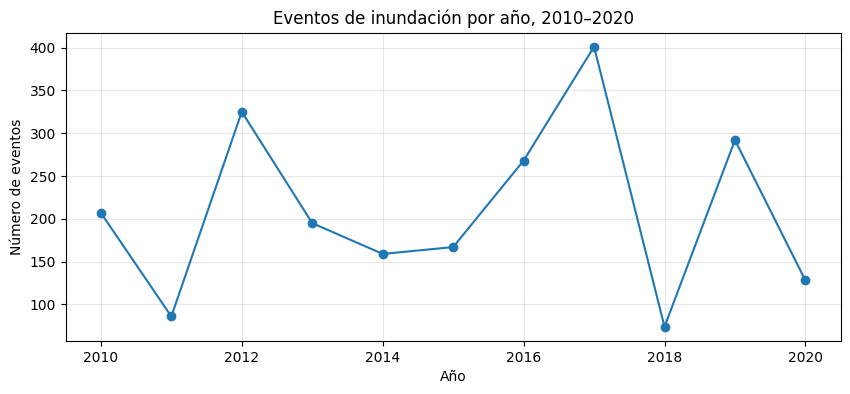

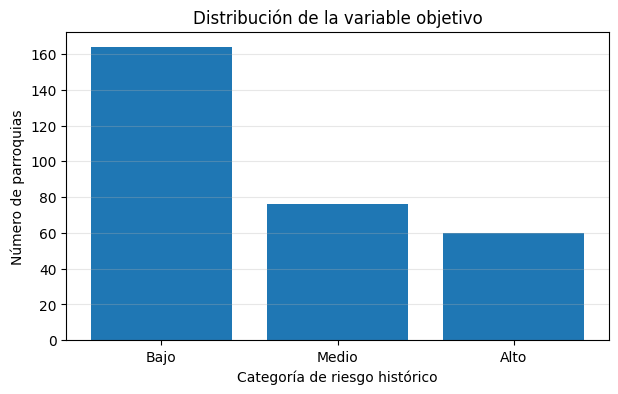

In [19]:
# ============================================================
# 11. Validación y análisis temporal de la variable objetivo
# ============================================================

# ------------------------------------------------------------
# Propósito: Verificar coherencia de la variable objetivo antes de usarla en el dataset
# final.
# Entradas principales: base_objetivo y tabla de inundaciones.
# Proceso resumido: Revisa duplicados, etiquetas faltantes, parroquias con cero eventos
# y distribución temporal de eventos por año.
# Salidas esperadas: eventos_por_anio y validaciones impresas de consistencia.
# ------------------------------------------------------------
if base_objetivo["codigo_parroquia"].duplicated().any():
    raise ValueError(
        "La variable objetivo contiene códigos duplicados."
    )

if base_objetivo["riesgo_inundacion"].isna().any():
    raise ValueError(
        "Existen etiquetas de riesgo faltantes."
    )

ceros_no_bajo = base_objetivo[
    (base_objetivo["eventos_inundacion"] == 0)
    & (
        base_objetivo["riesgo_inundacion"]
        != "Bajo"
    )
]

if len(ceros_no_bajo):
    raise ValueError(
        "Existen parroquias con cero eventos que no fueron clasificadas como Bajo."
    )

eventos_por_anio = (
    inundaciones
    .groupby(
        "anio_evento",
        as_index=False
    )
    .size()
    .rename(
        columns={"size": "eventos_inundacion"}
    )
)

eventos_por_anio["anio_evento"] = (
    eventos_por_anio["anio_evento"]
    .astype(int)
)

display(eventos_por_anio)

plt.figure(figsize=(10, 4))
plt.plot(
    eventos_por_anio["anio_evento"],
    eventos_por_anio["eventos_inundacion"],
    marker="o"
)
plt.title("Eventos de inundación por año, 2010–2020")
plt.xlabel("Año")
plt.ylabel("Número de eventos")
plt.grid(alpha=0.3)
plt.show()

distribucion = (
    base_objetivo["riesgo_inundacion"]
    .value_counts()
    .reindex(orden_clases)
)

plt.figure(figsize=(7, 4))
plt.bar(
    distribucion.index,
    distribucion.values
)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Categoría de riesgo histórico")
plt.ylabel("Número de parroquias")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [20]:
# ============================================================
# 10. Exportación de la variable objetivo
# ============================================================

# ------------------------------------------------------------
# Propósito: Guardar los archivos derivados de la variable objetivo para trazabilidad.
# Entradas principales: base_objetivo, eventos_por_anio y umbrales usados.
# Proceso resumido: Exporta CSV y JSON con conteos, distribución por año y reglas de
# clasificación.
# Salidas esperadas: riesgo_historico_inundacion_parroquias_2010_2020.csv,
# eventos_inundacion_por_anio.csv y umbrales_variable_objetivo.json.
# ------------------------------------------------------------
ruta_objetivo = Path("/content") / SALIDAS["objetivo"]
ruta_eventos_anuales = Path("/content") / SALIDAS["eventos_anuales"]
ruta_umbrales = Path("/content") / SALIDAS["umbrales"]

base_objetivo.to_csv(
    ruta_objetivo,
    index=False,
    encoding="utf-8-sig"
)

eventos_por_anio.to_csv(
    ruta_eventos_anuales,
    index=False,
    encoding="utf-8-sig"
)

configuracion_objetivo = {
    "periodo_inicial": ANIO_INICIAL,
    "periodo_final": ANIO_FINAL,
    "percentil_bajo": PERCENTIL_BAJO,
    "percentil_medio": PERCENTIL_MEDIO,
    "umbral_bajo_eventos": q40,
    "umbral_medio_eventos": q75,
    "regla": {
        "Bajo": f"eventos <= {q40}",
        "Medio": f"{q40} < eventos <= {q75}",
        "Alto": f"eventos > {q75}"
    }
}

with open(
    ruta_umbrales,
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(
        configuracion_objetivo,
        archivo,
        ensure_ascii=False,
        indent=2
    )

print("Variable objetivo exportada.")

Variable objetivo exportada.


## 2.2. Altitud, rango altitudinal y pendiente

In [21]:
# ============================================================
# 12. Funciones para descargar y procesar Copernicus DEM
# ============================================================

# ------------------------------------------------------------
# Propósito: Definir funciones para descargar teselas DEM y calcular pendiente a partir
# del modelo digital de elevación.
# Entradas principales: Extensión geográfica de parroquias y parámetros de descarga de
# Copernicus DEM.
# Proceso resumido: Crea funciones para identificar teselas, descargarlas, mosaicar/leer
# raster y derivar pendiente con resolución métrica.
# Salidas esperadas: Funciones listas para calcular altitud y pendiente en las
# siguientes celdas.
# ------------------------------------------------------------
CARPETA_DEM = Path("/content/copernicus_dem_tiles")
CARPETA_DEM.mkdir(exist_ok=True)

def texto_latitud(lat):
    return (
        f"N{lat:02d}_00"
        if lat >= 0
        else f"S{abs(lat):02d}_00"
    )


def texto_longitud(lon):
    return (
        f"E{lon:03d}_00"
        if lon >= 0
        else f"W{abs(lon):03d}_00"
    )


def construir_url_copernicus(lat, lon):
    nombre = (
        "Copernicus_DSM_COG_10_"
        f"{texto_latitud(lat)}_"
        f"{texto_longitud(lon)}_DEM"
    )

    url = (
        "https://copernicus-dem-30m.s3.amazonaws.com/"
        f"{nombre}/{nombre}.tif"
    )

    return nombre, url


def descargar_archivo(url, destino):
    if destino.exists() and destino.stat().st_size > 0:
        return True

    respuesta = requests.get(
        url,
        stream=True,
        timeout=180
    )

    if respuesta.status_code == 404:
        return False

    respuesta.raise_for_status()

    total = int(
        respuesta.headers.get(
            "content-length",
            0
        )
    )

    with open(destino, "wb") as archivo, tqdm(
        total=total,
        unit="B",
        unit_scale=True,
        desc=destino.name,
        leave=False
    ) as barra:
        for bloque in respuesta.iter_content(
            chunk_size=1024 * 1024
        ):
            if bloque:
                archivo.write(bloque)
                barra.update(len(bloque))

    return True


def actualizar_acumulador(acumulador, codigo, estadisticas):
    registro = acumulador.setdefault(
        codigo,
        {
            "count": 0,
            "sum": 0.0,
            "min": np.nan,
            "max": np.nan
        }
    )

    conteo = estadisticas.get("count")
    suma = estadisticas.get("sum")
    minimo = estadisticas.get("min")
    maximo = estadisticas.get("max")

    if conteo is not None and conteo > 0:
        registro["count"] += int(conteo)
        registro["sum"] += float(
            suma if suma is not None else 0
        )

        if minimo is not None:
            registro["min"] = (
                float(minimo)
                if pd.isna(registro["min"])
                else min(
                    registro["min"],
                    float(minimo)
                )
            )

        if maximo is not None:
            registro["max"] = (
                float(maximo)
                if pd.isna(registro["max"])
                else max(
                    registro["max"],
                    float(maximo)
                )
            )


def crear_raster_pendiente(ruta_dem, ruta_pendiente):
    ruta_utm = ruta_pendiente.with_name(
        ruta_pendiente.stem + "_dem_utm.tif"
    )

    with rasterio.open(ruta_dem) as src:
        transform, width, height = calculate_default_transform(
            src.crs,
            CRS_METRICO,
            src.width,
            src.height,
            *src.bounds
        )

        perfil = src.meta.copy()
        perfil.update(
            {
                "crs": CRS_METRICO,
                "transform": transform,
                "width": width,
                "height": height,
                "dtype": "float32",
                "nodata": -9999.0,
                "compress": "lzw"
            }
        )

        with rasterio.open(
            ruta_utm,
            "w",
            **perfil
        ) as dst:
            reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                src_nodata=src.nodata,
                dst_transform=transform,
                dst_crs=CRS_METRICO,
                dst_nodata=-9999.0,
                resampling=Resampling.bilinear
            )

    with rasterio.open(ruta_utm) as src:
        elevacion = src.read(
            1,
            masked=True
        ).astype("float32")

        datos = elevacion.filled(np.nan)

        xres = abs(src.transform.a)
        yres = abs(src.transform.e)

        grad_y, grad_x = np.gradient(
            datos,
            yres,
            xres
        )

        pendiente = np.degrees(
            np.arctan(
                np.sqrt(
                    grad_x ** 2
                    + grad_y ** 2
                )
            )
        ).astype("float32")

        pendiente[
            ~np.isfinite(pendiente)
        ] = -9999.0

        perfil_pendiente = src.profile.copy()
        perfil_pendiente.update(
            {
                "dtype": "float32",
                "nodata": -9999.0,
                "compress": "lzw"
            }
        )

        with rasterio.open(
            ruta_pendiente,
            "w",
            **perfil_pendiente
        ) as dst:
            dst.write(pendiente, 1)

    ruta_utm.unlink(missing_ok=True)

In [22]:
# ============================================================
# 13. Descarga selectiva de teselas DEM
# ============================================================

# ------------------------------------------------------------
# Propósito: Descargar solo las teselas Copernicus DEM necesarias para cubrir las
# parroquias del estudio.
# Entradas principales: Extensión territorial de parroquias.
# Proceso resumido: Calcula las teselas requeridas, descarga archivos faltantes y evita
# repetir descargas si ya existen.
# Salidas esperadas: Lista de rutas raster DEM disponibles localmente en Colab.
# ------------------------------------------------------------
salida_topografia = Path("/content") / SALIDAS["topografia"]

if REUTILIZAR_TOPOGRAFIA and salida_topografia.exists():
    topografia = pd.read_csv(
        salida_topografia,
        dtype={"codigo_parroquia": "string"}
    )
    print("Se reutilizó:", salida_topografia)

else:
    geometria_estudio = parroquias.geometry.union_all()

    minx, miny, maxx, maxy = parroquias.total_bounds

    teselas = []

    for lat in range(floor(miny), ceil(maxy)):
        for lon in range(floor(minx), ceil(maxx)):
            poligono_tesela = box(
                lon,
                lat,
                lon + 1,
                lat + 1
            )

            if not geometria_estudio.intersects(
                poligono_tesela
            ):
                continue

            nombre, url = construir_url_copernicus(
                lat,
                lon
            )

            destino = CARPETA_DEM / f"{nombre}.tif"

            try:
                disponible = descargar_archivo(
                    url,
                    destino
                )
            except Exception as error:
                print(
                    f"No se pudo descargar {nombre}: {error}"
                )
                disponible = False

            if disponible:
                teselas.append(destino)

    if not teselas:
        raise RuntimeError(
            "No se descargó ninguna tesela Copernicus DEM."
        )

    print("Teselas descargadas:", len(teselas))

Copernicus_DSM_COG_10_S04_00_W081_00_DEM.tif:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

Copernicus_DSM_COG_10_S04_00_W080_00_DEM.tif:   0%|          | 0.00/43.3M [00:00<?, ?B/s]

Copernicus_DSM_COG_10_S03_00_W082_00_DEM.tif:   0%|          | 0.00/97.2k [00:00<?, ?B/s]

Copernicus_DSM_COG_10_S03_00_W081_00_DEM.tif:   0%|          | 0.00/25.7M [00:00<?, ?B/s]

Copernicus_DSM_COG_10_S03_00_W080_00_DEM.tif:   0%|          | 0.00/42.8M [00:00<?, ?B/s]

...

Copernicus_DSM_COG_10_N00_00_W080_00_DEM.tif:   0%|          | 0.00/48.1M [00:00<?, ?B/s]

Copernicus_DSM_COG_10_N00_00_W079_00_DEM.tif:   0%|          | 0.00/44.0M [00:00<?, ?B/s]

Copernicus_DSM_COG_10_N01_00_W080_00_DEM.tif:   0%|          | 0.00/3.05M [00:00<?, ?B/s]

Copernicus_DSM_COG_10_N01_00_W079_00_DEM.tif:   0%|          | 0.00/43.7M [00:00<?, ?B/s]

Teselas descargadas: 15


In [23]:
# ============================================================
# 14. Estadísticas zonales de altitud y pendiente
# ============================================================

# ------------------------------------------------------------
# Propósito: Calcular variables topográficas por parroquia.
# Entradas principales: Teselas DEM y geometrías parroquiales.
# Proceso resumido: Recorta raster por parroquia, calcula altitud mínima, máxima, media,
# rango altitudinal y pendiente media.
# Salidas esperadas: altitud_pendiente_parroquias_copernicus.csv con variables topográficas.
# ------------------------------------------------------------
if not (
    REUTILIZAR_TOPOGRAFIA
    and salida_topografia.exists()
):
    acumulador_altitud = {}
    acumulador_pendiente = {}

    parroquias_utm = parroquias.to_crs(
        CRS_METRICO
    )

    for ruta_dem in tqdm(
        teselas,
        desc="Procesando topografía"
    ):
        with rasterio.open(ruta_dem) as src:
            poligono_tesela = box(*src.bounds)

            indices = parroquias[
                parroquias.geometry.intersects(
                    poligono_tesela
                )
            ].index

            if len(indices) == 0:
                continue

            subconjunto = parroquias.loc[
                indices
            ].copy()

            estadisticas_altitud = zonal_stats(
                subconjunto.geometry,
                str(ruta_dem),
                stats=[
                    "count",
                    "sum",
                    "min",
                    "max"
                ],
                nodata=src.nodata,
                all_touched=False
            )

            for codigo, estadisticas in zip(
                subconjunto["codigo_parroquia"],
                estadisticas_altitud
            ):
                actualizar_acumulador(
                    acumulador_altitud,
                    codigo,
                    estadisticas
                )

        ruta_pendiente = CARPETA_DEM / (
            ruta_dem.stem + "_pendiente.tif"
        )

        crear_raster_pendiente(
            ruta_dem,
            ruta_pendiente
        )

        subconjunto_utm = parroquias_utm.loc[
            indices
        ].copy()

        estadisticas_pendiente = zonal_stats(
            subconjunto_utm.geometry,
            str(ruta_pendiente),
            stats=[
                "count",
                "sum",
                "min",
                "max"
            ],
            nodata=-9999.0,
            all_touched=False
        )

        for codigo, estadisticas in zip(
            subconjunto_utm["codigo_parroquia"],
            estadisticas_pendiente
        ):
            actualizar_acumulador(
                acumulador_pendiente,
                codigo,
                estadisticas
            )

        ruta_pendiente.unlink(missing_ok=True)

        if not CONSERVAR_TESELAS_DEM:
            ruta_dem.unlink(missing_ok=True)

    filas_topografia = []

    for codigo in parroquias["codigo_parroquia"]:
        alt = acumulador_altitud.get(codigo, {})
        pen = acumulador_pendiente.get(codigo, {})

        conteo_alt = alt.get("count", 0)
        conteo_pen = pen.get("count", 0)

        altitud_minima = alt.get("min", np.nan)
        altitud_maxima = alt.get("max", np.nan)

        altitud_media = (
            alt.get("sum", 0.0) / conteo_alt
            if conteo_alt
            else np.nan
        )

        pendiente_media = (
            pen.get("sum", 0.0) / conteo_pen
            if conteo_pen
            else np.nan
        )

        rango_altitudinal = (
            altitud_maxima - altitud_minima
            if pd.notna(altitud_maxima)
            and pd.notna(altitud_minima)
            else np.nan
        )

        filas_topografia.append(
            {
                "codigo_parroquia": codigo,
                "altitud_minima": altitud_minima,
                "altitud_maxima": altitud_maxima,
                "altitud_media": altitud_media,
                "rango_altitudinal": rango_altitudinal,
                "pendiente_media": pendiente_media,
                "pixeles_altitud_validos": conteo_alt,
                "pixeles_pendiente_validos": conteo_pen
            }
        )

    topografia = pd.DataFrame(
        filas_topografia
    )

    topografia.to_csv(
        salida_topografia,
        index=False,
        encoding="utf-8-sig"
    )

validar_unicidad(
    topografia,
    "Topografía derivada"
)

display(topografia.head())

Procesando topografía:   0%|          | 0/15 [00:00<?, ?it/s]

Topografía derivada: 300 parroquias y 0 valores faltantes.


,codigo_parroquia,altitud_minima,altitud_maxima,altitud_media,rango_altitudinal,pendiente_media,pixeles_altitud_validos,pixeles_pendiente_validos
0,070150,-3.1290,35.1450,4.5390,38.2740,1.4637,518830,258649
1,070152,-1.8032,23.6812,3.2339,25.4844,1.5773,267032,133064
2,070250,0.0000,"1,277.8110",79.1977,"1,277.8110",9.9917,549510,273686
3,070251,1.4703,69.2513,28.3299,67.7810,1.5115,102697,102720
4,070254,47.0961,652.5268,147.7380,605.4307,9.1134,222747,222785


In [24]:
# ============================================================
# 11. Integración de predictoras, topografía y objetivo
# ============================================================

# ------------------------------------------------------------
# Propósito: Construir el dataset final de clasificación supervisada.
# Entradas principales: dataset_predictoras, topografía y variable objetivo.
# Proceso resumido: Une tablas por codigo_parroquia, verifica duplicados, evita fuga de
# datos retirando eventos_inundacion y ordena columnas finales.
# Salidas esperadas: dataset_inundacion.csv listo para EDA y modelado.
# ------------------------------------------------------------
topografia_modelo = topografia[
    [
        "codigo_parroquia",
        "altitud_media",
        "rango_altitudinal",
        "pendiente_media"
    ]
].copy()

objetivo_modelo = base_objetivo[
    [
        "codigo_parroquia",
        "riesgo_inundacion"
    ]
].copy()

dataset_inundacion = (
    dataset_predictoras
    .merge(
        topografia_modelo,
        on="codigo_parroquia",
        how="left",
        validate="one_to_one",
        indicator="union_topografia"
    )
    .merge(
        objetivo_modelo,
        on="codigo_parroquia",
        how="left",
        validate="one_to_one",
        indicator="union_objetivo"
    )
)

reporte_integracion = dataset_inundacion[
    [
        "codigo_parroquia",
        "codigo_provincia",
        "provincia_modelo",
        "union_topografia",
        "union_objetivo"
    ]
].copy()

dataset_inundacion = dataset_inundacion.drop(
    columns=[
        "union_topografia",
        "union_objetivo"
    ]
)

if dataset_inundacion["codigo_parroquia"].duplicated().any():
    raise ValueError(
        "La unión produjo códigos parroquiales duplicados."
    )

if dataset_inundacion["riesgo_inundacion"].isna().any():
    raise ValueError(
        "La unión produjo etiquetas de riesgo faltantes."
    )

columnas_fuga = [
    columna
    for columna in dataset_inundacion.columns
    if columna in {
        "eventos_inundacion",
        "numero_eventos",
        "conteo_inundaciones"
    }
]

if columnas_fuga:
    dataset_inundacion = dataset_inundacion.drop(
        columns=columnas_fuga
    )

ruta_dataset_inundacion = (
    Path("/content")
    / SALIDAS["dataset_inundacion"]
)

dataset_inundacion.to_csv(
    ruta_dataset_inundacion,
    index=False,
    encoding="utf-8-sig"
)

reporte_integracion.to_csv(
    "/content/reporte_integracion_fuentes.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dimensiones de dataset_inundacion:", dataset_inundacion.shape)
print("Archivo:", ruta_dataset_inundacion)
display(dataset_inundacion.head())

Dimensiones de dataset_inundacion: (300, 21)
Archivo: /content/dataset_inundacion.csv


,codigo_parroquia,codigo_provincia,provincia_modelo,precipitacion_media_anual,precipitacion_maxima_anual,precipitacion_minima_anual,distancia_minima_rio_km,distancia_centroide_rio_km,porcentaje_area_cerca_rio_1km,num_elementos_hidricos_intersectan,densidad_poblacional_hab_km2,porcentaje_area_urbanizada,porcentaje_bosque,porcentaje_agricultura_pasto,porcentaje_agua,porcentaje_acuicultura,porcentaje_mineria,altitud_media,rango_altitudinal,pendiente_media,riesgo_inundacion
0,070150,07,EL ORO,588.5731,"3,194.7500",159.0545,0.0000,0.7807,58.4567,147.0000,"1,228.0000",24.1379,3.4483,10.3448,10.3448,17.2414,0.0000,4.5390,38.2740,1.4637,Alto
1,070152,07,EL ORO,515.3719,"1,395.6000",85.3091,0.0000,0.2538,72.8481,49.0000,36.0000,0.0000,0.0000,0.0000,10.0000,10.0000,0.0000,3.2339,25.4844,1.5773,Medio
2,070250,07,EL ORO,762.8979,"2,714.6500",227.0500,0.0000,0.1517,56.3294,37.0000,92.0000,0.0000,12.0000,48.0000,0.0000,0.0000,0.0000,79.1977,"1,277.8110",9.9917,Alto
3,070251,07,EL ORO,441.8155,"1,629.9000",18.1000,0.0000,1.5682,40.5456,40.0000,20.0000,0.0000,0.0000,30.0000,0.0000,0.0000,0.0000,28.3299,67.7810,1.5115,Bajo
4,070254,07,EL ORO,813.4825,"3,370.8000",236.0000,0.0000,0.6356,56.9331,15.0000,16.0000,0.0000,5.5556,38.8889,0.0000,0.0000,0.0000,147.7380,605.4307,9.1134,Bajo


# ETAPA 3. Análisis exploratorio y preparación para entrenamiento

El EDA se ejecuta directamente sobre `dataset_inundacion` generado en memoria. No es necesario volver a cargar el CSV.

In [25]:
# ============================================================
# 12. Inicio del EDA
# ============================================================

# ------------------------------------------------------------
# Propósito: Cargar el dataset final para iniciar el análisis exploratorio.
# Entradas principales: dataset_inundacion.csv generado en la etapa 2.
# Proceso resumido: Lee el archivo o reutiliza el DataFrame en memoria.
# Salidas esperadas: DataFrame df_eda para validación, gráficos y preparación de
# entrenamiento.
# ------------------------------------------------------------
df_original = dataset_inundacion.copy()

print("Dimensiones iniciales del EDA:", df_original.shape)
display(df_original.head())

Dimensiones iniciales del EDA: (300, 21)


,codigo_parroquia,codigo_provincia,provincia_modelo,precipitacion_media_anual,precipitacion_maxima_anual,precipitacion_minima_anual,distancia_minima_rio_km,distancia_centroide_rio_km,porcentaje_area_cerca_rio_1km,num_elementos_hidricos_intersectan,densidad_poblacional_hab_km2,porcentaje_area_urbanizada,porcentaje_bosque,porcentaje_agricultura_pasto,porcentaje_agua,porcentaje_acuicultura,porcentaje_mineria,altitud_media,rango_altitudinal,pendiente_media,riesgo_inundacion
0,070150,07,EL ORO,588.5731,"3,194.7500",159.0545,0.0000,0.7807,58.4567,147.0000,"1,228.0000",24.1379,3.4483,10.3448,10.3448,17.2414,0.0000,4.5390,38.2740,1.4637,Alto
1,070152,07,EL ORO,515.3719,"1,395.6000",85.3091,0.0000,0.2538,72.8481,49.0000,36.0000,0.0000,0.0000,0.0000,10.0000,10.0000,0.0000,3.2339,25.4844,1.5773,Medio
2,070250,07,EL ORO,762.8979,"2,714.6500",227.0500,0.0000,0.1517,56.3294,37.0000,92.0000,0.0000,12.0000,48.0000,0.0000,0.0000,0.0000,79.1977,"1,277.8110",9.9917,Alto
3,070251,07,EL ORO,441.8155,"1,629.9000",18.1000,0.0000,1.5682,40.5456,40.0000,20.0000,0.0000,0.0000,30.0000,0.0000,0.0000,0.0000,28.3299,67.7810,1.5115,Bajo
4,070254,07,EL ORO,813.4825,"3,370.8000",236.0000,0.0000,0.6356,56.9331,15.0000,16.0000,0.0000,5.5556,38.8889,0.0000,0.0000,0.0000,147.7380,605.4307,9.1134,Bajo


In [26]:
# ============================================================
# 3. Normalización de nombres, códigos y textos
# ============================================================

# ------------------------------------------------------------
# Propósito: Estandarizar el dataset antes del análisis exploratorio.
# Entradas principales: df_eda.
# Proceso resumido: Normaliza nombres de columnas, códigos territoriales, etiquetas de
# riesgo y detecta columnas identificadoras/predictoras.
# Salidas esperadas: Dataset con estructura homogénea y listas de columnas útiles para
# el EDA.
# ------------------------------------------------------------
def normalizar_nombre_columna(valor):
    texto = str(valor).strip().lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        c for c in texto
        if not unicodedata.combining(c)
    )
    texto = re.sub(r"[^a-z0-9]+", "_", texto)
    return texto.strip("_")


def normalizar_texto(valor):
    if pd.isna(valor):
        return pd.NA

    texto = str(valor).strip().upper()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(
        c for c in texto
        if not unicodedata.combining(c)
    )
    return " ".join(texto.split())


def normalizar_codigo(serie, longitud):
    return (
        serie.astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.extract(r"(\d+)", expand=False)
        .str.zfill(longitud)
    )


df = df_original.copy()

df.columns = [
    normalizar_nombre_columna(c)
    for c in df.columns
]

COLUMNAS_ESPERADAS = [
    "codigo_parroquia",
    "codigo_provincia",
    "provincia_modelo",
    "precipitacion_media_anual",
    "precipitacion_maxima_anual",
    "precipitacion_minima_anual",
    "altitud_media",
    "rango_altitudinal",
    "pendiente_media",
    "distancia_minima_rio_km",
    "distancia_centroide_rio_km",
    "porcentaje_area_cerca_rio_1km",
    "num_elementos_hidricos_intersectan",
    "densidad_poblacional_hab_km2",
    "porcentaje_area_urbanizada",
    "porcentaje_bosque",
    "porcentaje_agricultura_pasto",
    "porcentaje_agua",
    "porcentaje_acuicultura",
    "porcentaje_mineria",
    "riesgo_inundacion"
]

faltantes_estructura = [
    c for c in COLUMNAS_ESPERADAS
    if c not in df.columns
]

if faltantes_estructura:
    raise KeyError(
        f"Faltan columnas obligatorias: {faltantes_estructura}"
    )

df["codigo_parroquia"] = normalizar_codigo(
    df["codigo_parroquia"],
    6
)

df["codigo_provincia"] = normalizar_codigo(
    df["codigo_provincia"],
    2
)

df["provincia_modelo"] = df[
    "provincia_modelo"
].apply(normalizar_texto)

mapa_clases = {
    "BAJO": "Bajo",
    "MEDIO": "Medio",
    "ALTO": "Alto"
}

df[OBJETIVO] = (
    df[OBJETIVO]
    .apply(normalizar_texto)
    .map(mapa_clases)
)

print("Normalización completada.")

Normalización completada.


In [27]:
# ============================================================
# 4. Revisión y conversión de fechas
# ============================================================

# ------------------------------------------------------------
# Propósito: Verificar si existen campos temporales en el dataset agregado.
# Entradas principales: df_eda.
# Proceso resumido: Busca columnas con nombres relacionados a fechas y, si existen,
# intenta convertirlas a datetime.
# Salidas esperadas: Fechas convertidas o mensaje indicando que no hay fechas por
# tratarse de un dataset agregado por parroquia.
# ------------------------------------------------------------
columnas_fecha = [
    c for c in df.columns
    if "fecha" in c.lower()
    or c.lower().endswith("_date")
]

if columnas_fecha:
    for columna in columnas_fecha:
        df[columna] = pd.to_datetime(
            df[columna],
            errors="coerce",
            dayfirst=True
        )

    print("Columnas de fecha convertidas:", columnas_fecha)

else:
    print(
        "No existen columnas de fecha en el dataset agregado. "
        "Esto es coherente con una fila por parroquia."
    )

No existen columnas de fecha en el dataset agregado. Esto es coherente con una fila por parroquia.


In [28]:
# ============================================================
# 5. Conversión de variables predictoras a formato numérico
# ============================================================

# ------------------------------------------------------------
# Propósito: Asegurar que las variables predictoras puedan ser usadas por modelos de
# machine learning.
# Entradas principales: Columnas predictoras detectadas.
# Proceso resumido: Convierte variables a formato numérico, reemplaza infinitos por NaN
# y conserva el dataset preparado.
# Salidas esperadas: Variables predictoras numéricas para análisis y entrenamiento.
# ------------------------------------------------------------
IDENTIFICADORES = [
    "codigo_parroquia",
    "codigo_provincia",
    "provincia_modelo"
]

columnas_numericas = [
    c for c in df.columns
    if c not in IDENTIFICADORES + [OBJETIVO] + columnas_fecha
]

for columna in columnas_numericas:
    df[columna] = pd.to_numeric(
        df[columna],
        errors="coerce"
    )

print("Variables numéricas:", len(columnas_numericas))
print(columnas_numericas)

Variables numéricas: 17
['precipitacion_media_anual', 'precipitacion_maxima_anual', 'precipitacion_minima_anual', 'distancia_minima_rio_km', 'distancia_centroide_rio_km', 'porcentaje_area_cerca_rio_1km', 'num_elementos_hidricos_intersectan', 'densidad_poblacional_hab_km2', 'porcentaje_area_urbanizada', 'porcentaje_bosque', 'porcentaje_agricultura_pasto', 'porcentaje_agua', 'porcentaje_acuicultura', 'porcentaje_mineria', 'altitud_media', 'rango_altitudinal', 'pendiente_media']


In [29]:
# ============================================================
# 6. Duplicados y consistencia territorial
# ============================================================

# ------------------------------------------------------------
# Propósito: Verificar que cada parroquia aparezca una sola vez y que la tabla sea
# territorialmente coherente.
# Entradas principales: df_eda.
# Proceso resumido: Revisa duplicados exactos, códigos parroquiales duplicados y códigos
# de provincia no esperados.
# Salidas esperadas: Reporte impreso de consistencia territorial y dataset sin problemas
# críticos.
# ------------------------------------------------------------
duplicados_completos = int(
    df.duplicated().sum()
)

duplicados_codigo = int(
    df["codigo_parroquia"]
    .duplicated()
    .sum()
)

print("Duplicados completos:", duplicados_completos)
print(
    "Códigos parroquiales duplicados:",
    duplicados_codigo
)

df = df.drop_duplicates().copy()

if df["codigo_parroquia"].duplicated().any():
    duplicados = df.loc[
        df["codigo_parroquia"].duplicated(
            keep=False
        )
    ].sort_values("codigo_parroquia")

    display(duplicados)

    raise ValueError(
        "Existen varias filas para una misma parroquia. "
        "Debe revisarse la integración de fuentes."
    )

inconsistencias_codigo = (
    df["codigo_parroquia"].str[:2]
    != df["codigo_provincia"]
).sum()

print(
    "Inconsistencias código parroquia/provincia:",
    int(inconsistencias_codigo)
)

if inconsistencias_codigo:
    df["codigo_provincia"] = (
        df["codigo_parroquia"].str[:2]
    )
    print(
        "El código provincial se corrigió desde "
        "codigo_parroquia."
    )

Duplicados completos: 0
Códigos parroquiales duplicados: 0
Inconsistencias código parroquia/provincia: 0


In [30]:
# ============================================================
# 7. Valores faltantes
# ============================================================

# ------------------------------------------------------------
# Propósito: Medir la completitud del dataset final.
# Entradas principales: df_eda.
# Proceso resumido: Cuenta valores nulos por columna, calcula porcentajes y exporta un
# reporte ordenado.
# Salidas esperadas: reporte_valores_faltantes.csv.
# ------------------------------------------------------------
reporte_nulos = pd.DataFrame(
    {
        "variable": df.columns,
        "valores_faltantes": [
            int(df[c].isna().sum())
            for c in df.columns
        ],
        "porcentaje_faltantes": [
            round(
                df[c].isna().mean() * 100,
                2
            )
            for c in df.columns
        ],
        "valores_no_nulos": [
            int(df[c].notna().sum())
            for c in df.columns
        ]
    }
).sort_values(
    "porcentaje_faltantes",
    ascending=False
)

display(reporte_nulos)

if df[OBJETIVO].isna().any():
    print(
        "Se eliminarán las filas sin variable objetivo. "
        "La etiqueta no debe imputarse."
    )

    df = df.dropna(
        subset=[OBJETIVO]
    ).copy()

print(
    "Valores faltantes en predictores:",
    int(
        df[columnas_numericas]
        .isna()
        .sum()
        .sum()
    )
)

print(
    "La imputación de predictores no se ejecuta globalmente "
    "en el EDA. Si existen nulos, deberá realizarse dentro "
    "del Pipeline de entrenamiento."
)

,variable,valores_faltantes,porcentaje_faltantes,valores_no_nulos
16,porcentaje_mineria,6,2.0000,294
13,porcentaje_agricultura_pasto,6,2.0000,294
14,porcentaje_agua,6,2.0000,294
12,porcentaje_bosque,6,2.0000,294
11,porcentaje_area_urbanizada,6,2.0000,294
15,porcentaje_acuicultura,6,2.0000,294
4,precipitacion_maxima_anual,0,0.0000,300
2,provincia_modelo,0,0.0000,300
1,codigo_provincia,0,0.0000,300
0,codigo_parroquia,0,0.0000,300


Valores faltantes en predictores: 36
La imputación de predictores no se ejecuta globalmente en el EDA. Si existen nulos, deberá realizarse dentro del Pipeline de entrenamiento.


In [31]:
# ============================================================
# 8. Validación de rangos físicos
# ============================================================

# ------------------------------------------------------------
# Propósito: Detectar valores imposibles o sospechosos según la naturaleza de cada variable.
# Entradas principales: Variables climáticas, hidrológicas, poblacionales, de cobertura
# y topográficas.
# Proceso resumido: Evalúa que no haya negativos donde no corresponda y que los
# porcentajes estén entre 0 y 100.
# Salidas esperadas: Advertencias o confirmación de rangos físicos aceptables.
# ------------------------------------------------------------
reporte_rangos = []

columnas_no_negativas = [
    "precipitacion_media_anual",
    "precipitacion_maxima_anual",
    "precipitacion_minima_anual",
    "rango_altitudinal",
    "pendiente_media",
    "distancia_minima_rio_km",
    "distancia_centroide_rio_km",
    "num_elementos_hidricos_intersectan",
    "densidad_poblacional_hab_km2"
]

for columna in columnas_no_negativas:
    cantidad = int(
        (df[columna] < 0).sum()
    )

    reporte_rangos.append(
        {
            "variable": columna,
            "criterio": "valor >= 0",
            "valores_invalidos": cantidad
        }
    )

    if cantidad:
        df.loc[
            df[columna] < 0,
            columna
        ] = np.nan

columnas_porcentaje = [
    "porcentaje_area_cerca_rio_1km",
    "porcentaje_area_urbanizada",
    "porcentaje_bosque",
    "porcentaje_agricultura_pasto",
    "porcentaje_agua",
    "porcentaje_acuicultura",
    "porcentaje_mineria"
]

for columna in columnas_porcentaje:
    mascara = (
        (df[columna] < 0)
        | (df[columna] > 100)
    )

    cantidad = int(
        mascara.sum()
    )

    reporte_rangos.append(
        {
            "variable": columna,
            "criterio": "0 <= porcentaje <= 100",
            "valores_invalidos": cantidad
        }
    )

    if cantidad:
        df.loc[
            mascara,
            columna
        ] = np.nan

reporte_rangos_df = pd.DataFrame(
    reporte_rangos
)

display(reporte_rangos_df)

,variable,criterio,valores_invalidos
0,precipitacion_media_anual,valor >= 0,0
1,precipitacion_maxima_anual,valor >= 0,0
2,precipitacion_minima_anual,valor >= 0,0
3,rango_altitudinal,valor >= 0,0
4,pendiente_media,valor >= 0,0
5,distancia_minima_rio_km,valor >= 0,0
6,distancia_centroide_rio_km,valor >= 0,0
7,num_elementos_hidricos_intersectan,valor >= 0,0
8,densidad_poblacional_hab_km2,valor >= 0,0
9,porcentaje_area_cerca_rio_1km,0 <= porcentaje <= 100,0


## 3.1. Balance de clases

La métrica general recomendada para la comparación de modelos será F1 macro. Para la gestión del riesgo se deberá prestar especial atención al recall de la clase Alto.

,clase,frecuencia,porcentaje
0,Bajo,164,54.6700
1,Medio,76,25.3300
2,Alto,60,20.0000


Razón clase mayoritaria/minoritaria: 2.73


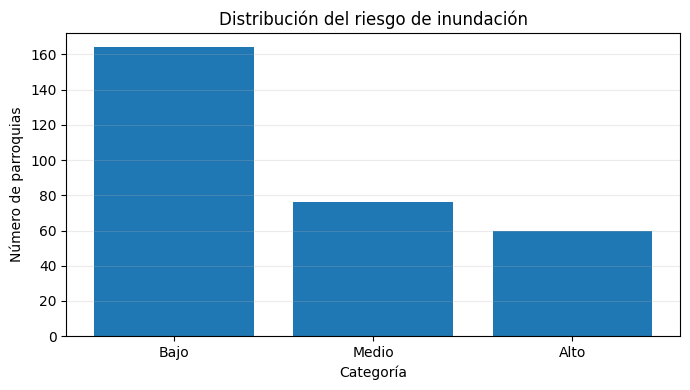

In [32]:
# ============================================================
# 9. Balance de la variable objetivo
# ============================================================

# ------------------------------------------------------------
# Propósito: Analizar la distribución de las clases Bajo, Medio y Alto.
# Entradas principales: Columna riesgo_inundacion.
# Proceso resumido: Cuenta frecuencias, porcentajes y grafica el balance de clases.
# Salidas esperadas: reporte_balance_clases.csv y grafico_balance_clases.png.
# ------------------------------------------------------------
frecuencias = (
    df[OBJETIVO]
    .value_counts()
    .reindex(CLASES_ORDEN)
    .fillna(0)
    .astype(int)
)

porcentajes = (
    df[OBJETIVO]
    .value_counts(normalize=True)
    .reindex(CLASES_ORDEN)
    .fillna(0)
    .mul(100)
    .round(2)
)

reporte_balance = pd.DataFrame(
    {
        "clase": CLASES_ORDEN,
        "frecuencia": frecuencias.values,
        "porcentaje": porcentajes.values
    }
)

display(reporte_balance)

frecuencias_positivas = frecuencias[
    frecuencias > 0
]

razon_desbalance = (
    frecuencias_positivas.max()
    / frecuencias_positivas.min()
)

print(
    "Razón clase mayoritaria/minoritaria:",
    round(float(razon_desbalance), 2)
)

plt.figure(figsize=(7, 4))
plt.bar(
    reporte_balance["clase"],
    reporte_balance["frecuencia"]
)
plt.title("Distribución del riesgo de inundación")
plt.xlabel("Categoría")
plt.ylabel("Número de parroquias")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(
    "grafico_balance_clases.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

In [33]:
# ============================================================
# 10. Estadísticas descriptivas
# ============================================================

# ------------------------------------------------------------
# Propósito: Resumir cuantitativamente las variables predictoras.
# Entradas principales: Variables numéricas del dataset.
# Proceso resumido: Calcula media, desviación estándar, mínimos, máximos, cuartiles y
# otros estadísticos.
# Salidas esperadas: estadisticas_descriptivas.csv.
# ------------------------------------------------------------
estadisticas = (
    df[columnas_numericas]
    .describe()
    .T
)

estadisticas["mediana"] = (
    df[columnas_numericas]
    .median()
)

estadisticas["asimetria"] = (
    df[columnas_numericas]
    .skew()
)

estadisticas["ceros"] = (
    df[columnas_numericas]
    .eq(0)
    .sum()
)

estadisticas["porcentaje_ceros"] = (
    estadisticas["ceros"]
    / len(df)
    * 100
)

display(estadisticas)

,count,mean,std,min,25%,50%,75%,max,mediana,asimetria,ceros,porcentaje_ceros
precipitacion_media_anual,300.0000,"1,503.2011",913.0474,152.3200,889.4509,"1,368.5218","2,023.4866","7,976.3273","1,368.5218",1.9330,0,0.0000
precipitacion_maxima_anual,300.0000,"3,316.9716","2,034.9783",464.2000,"1,920.5250","2,930.8000","4,192.6800","14,616.2000","2,930.8000",1.9716,0,0.0000
precipitacion_minima_anual,300.0000,694.4317,694.4956,0.0000,248.8800,502.4000,893.3886,"5,519.4000",502.4000,2.5431,4,1.3333
distancia_minima_rio_km,300.0000,0.0037,0.0642,0.0000,0.0000,0.0000,0.0000,1.1127,0.0000,17.3195,298,99.3333
distancia_centroide_rio_km,300.0000,1.1815,1.0946,0.0000,0.3947,0.9083,1.5738,5.6828,0.9083,1.5225,11,3.6667
porcentaje_area_cerca_rio_1km,300.0000,54.1094,19.6508,0.0000,39.1326,54.5174,68.5505,100.0000,54.5174,0.0075,1,0.3333
num_elementos_hidricos_intersectan,300.0000,121.1833,508.1174,0.0000,10.0000,23.0000,64.5000,"7,975.0000",23.0000,12.9148,2,0.6667
densidad_poblacional_hab_km2,300.0000,144.7600,389.1501,1.0000,24.0000,51.0000,111.2500,"4,440.0000",51.0000,7.1716,0,0.0000
porcentaje_area_urbanizada,294.0000,1.8871,8.6033,0.0000,0.0000,0.0000,0.0000,100.0000,0.0000,7.4875,253,84.3333
porcentaje_bosque,294.0000,25.2721,27.6317,0.0000,0.0000,16.6667,44.8052,100.0000,16.6667,0.9420,99,33.0000


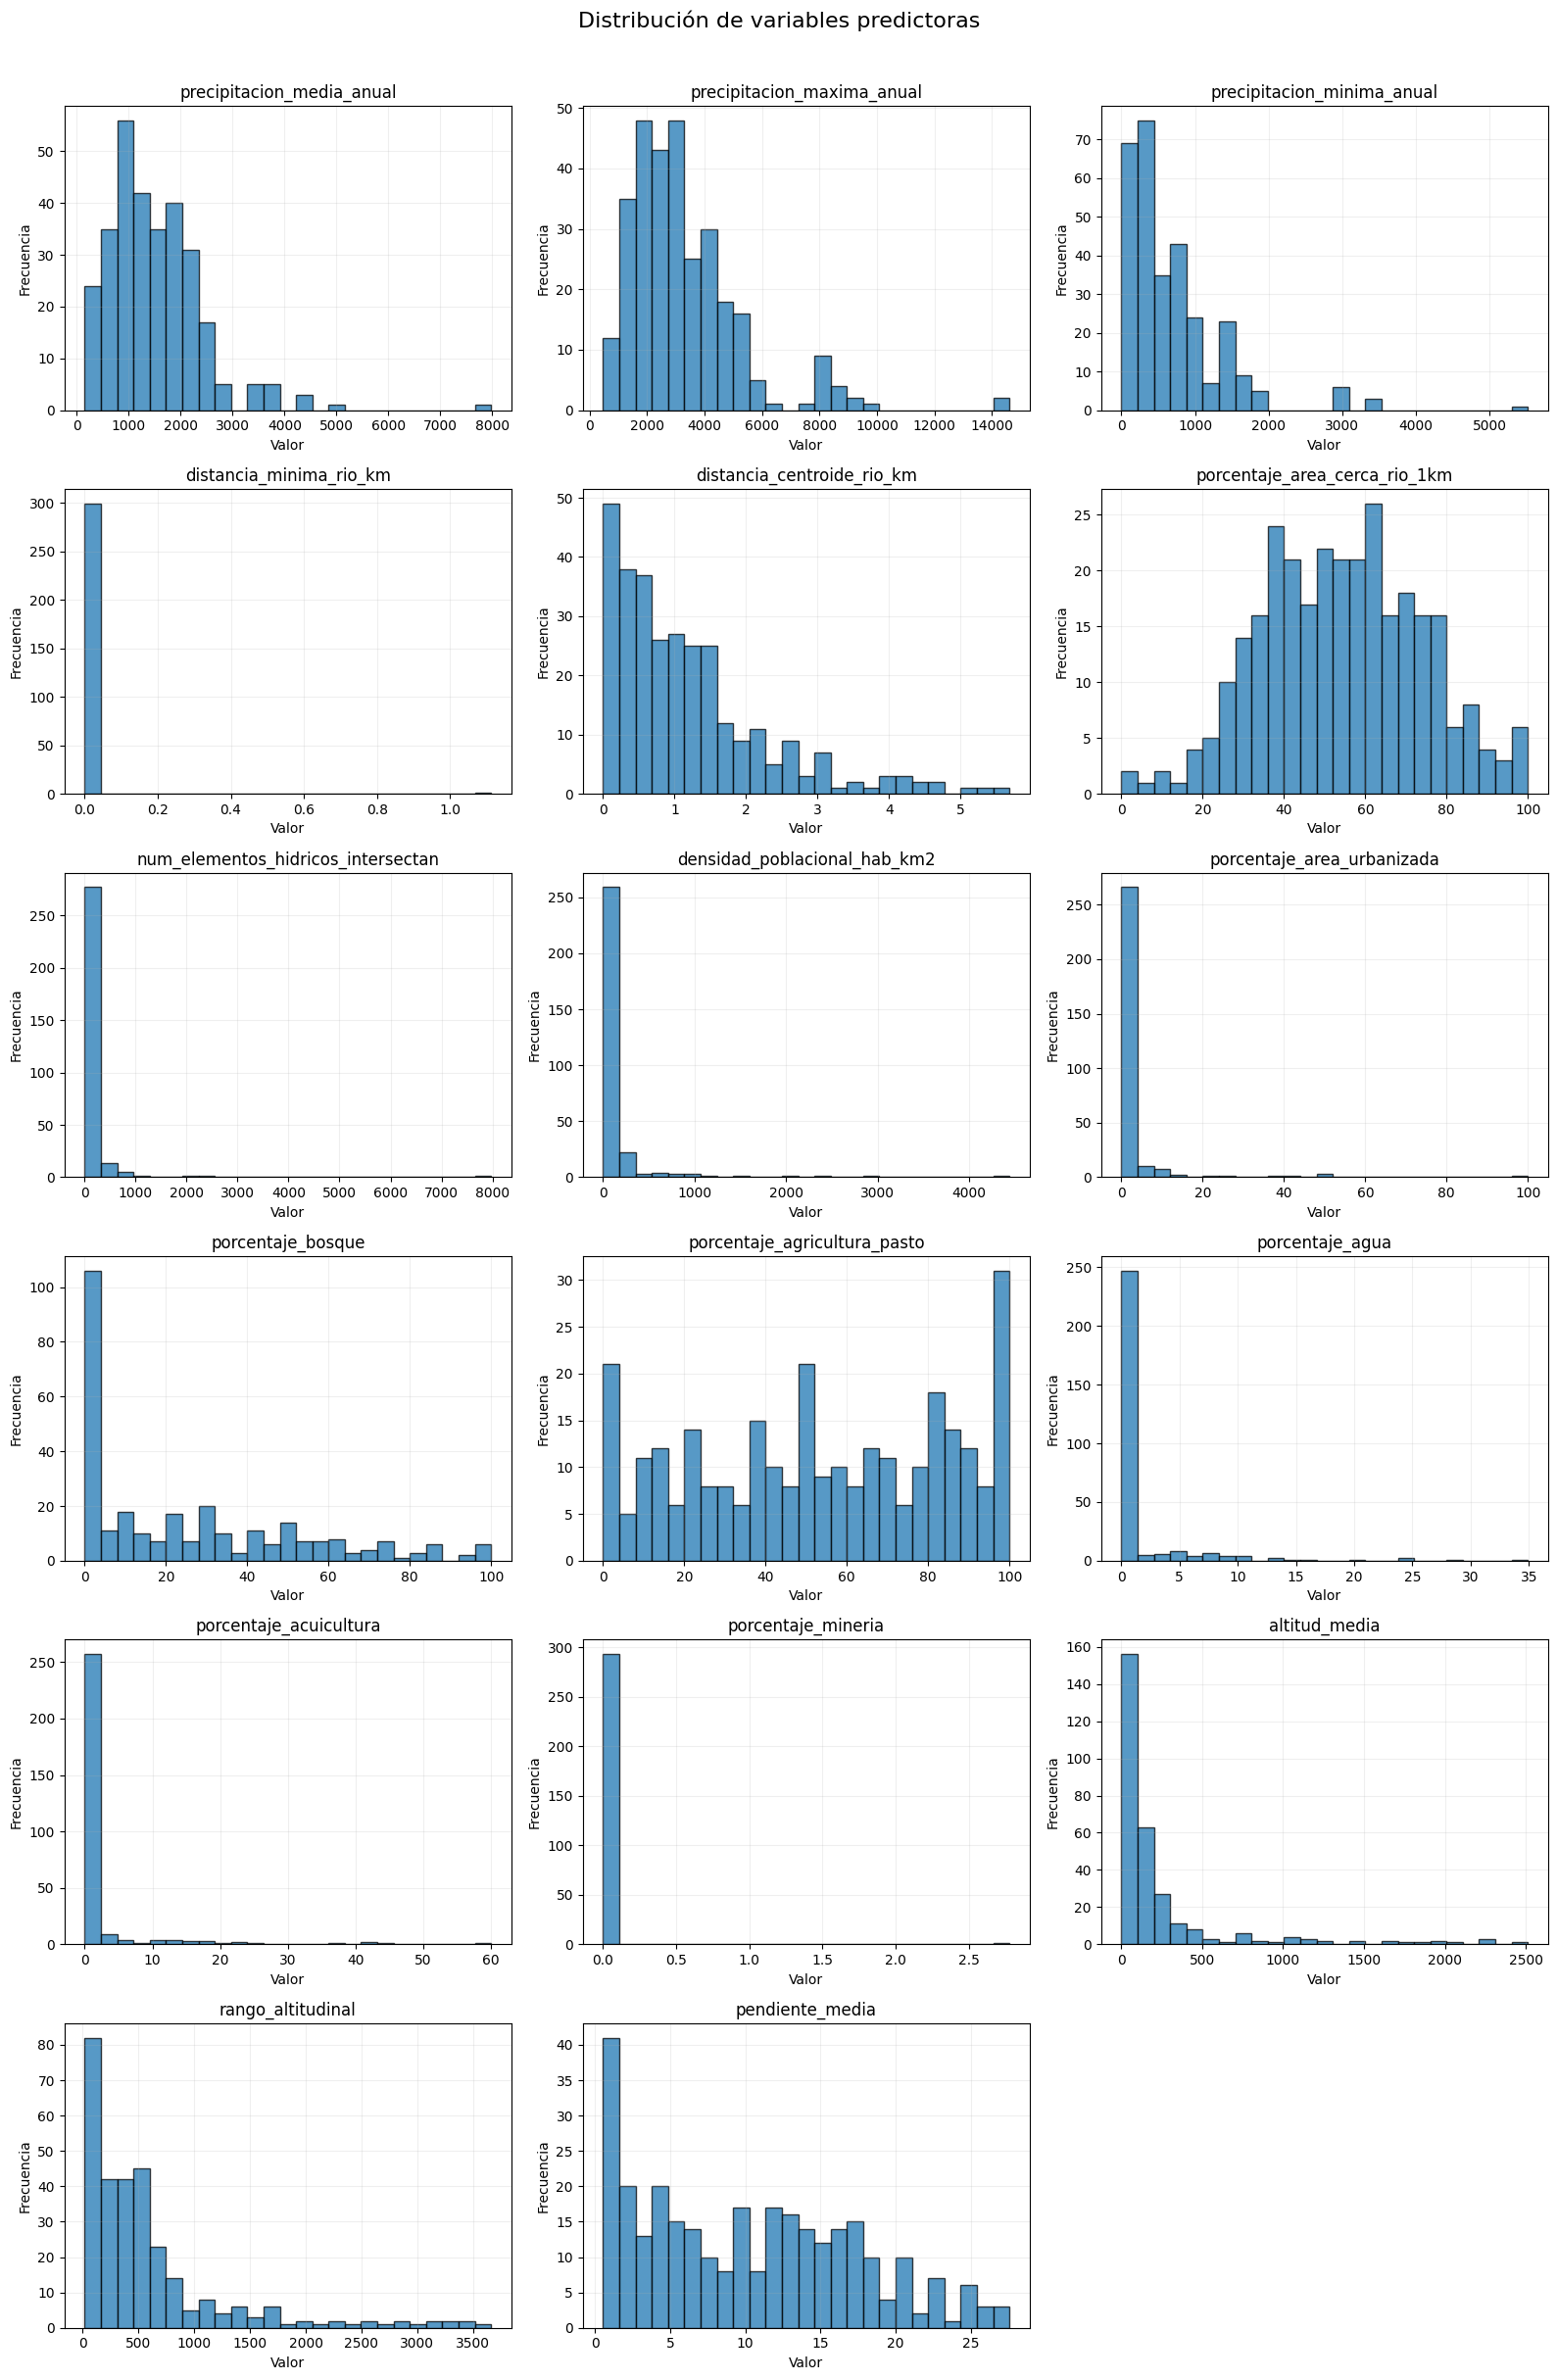

In [34]:
# ============================================================
# 11. Histogramas de variables predictoras
# ============================================================

# ------------------------------------------------------------
# Propósito: Visualizar la distribución individual de cada predictor.
# Entradas principales: Variables predictoras numéricas.
# Proceso resumido: Genera histogramas en una cuadrícula para revisar asimetrías,
# concentraciones y valores extremos.
# Salidas esperadas: histogramas_variables_predictoras.png.
# ------------------------------------------------------------
n_columnas = 3
n_filas = int(
    np.ceil(
        len(columnas_numericas)
        / n_columnas
    )
)

fig, axes = plt.subplots(
    n_filas,
    n_columnas,
    figsize=(16, 4 * n_filas)
)

axes = np.array(axes).reshape(-1)

for eje, columna in zip(
    axes,
    columnas_numericas
):
    eje.hist(
        df[columna].dropna(),
        bins=25,
        edgecolor="black",
        alpha=0.75
    )
    eje.set_title(columna)
    eje.set_xlabel("Valor")
    eje.set_ylabel("Frecuencia")
    eje.grid(alpha=0.2)

for eje in axes[
    len(columnas_numericas):
]:
    eje.axis("off")

plt.suptitle(
    "Distribución de variables predictoras",
    fontsize=16,
    y=1.01
)
plt.tight_layout()
plt.savefig(
    "histogramas_variables_predictoras.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

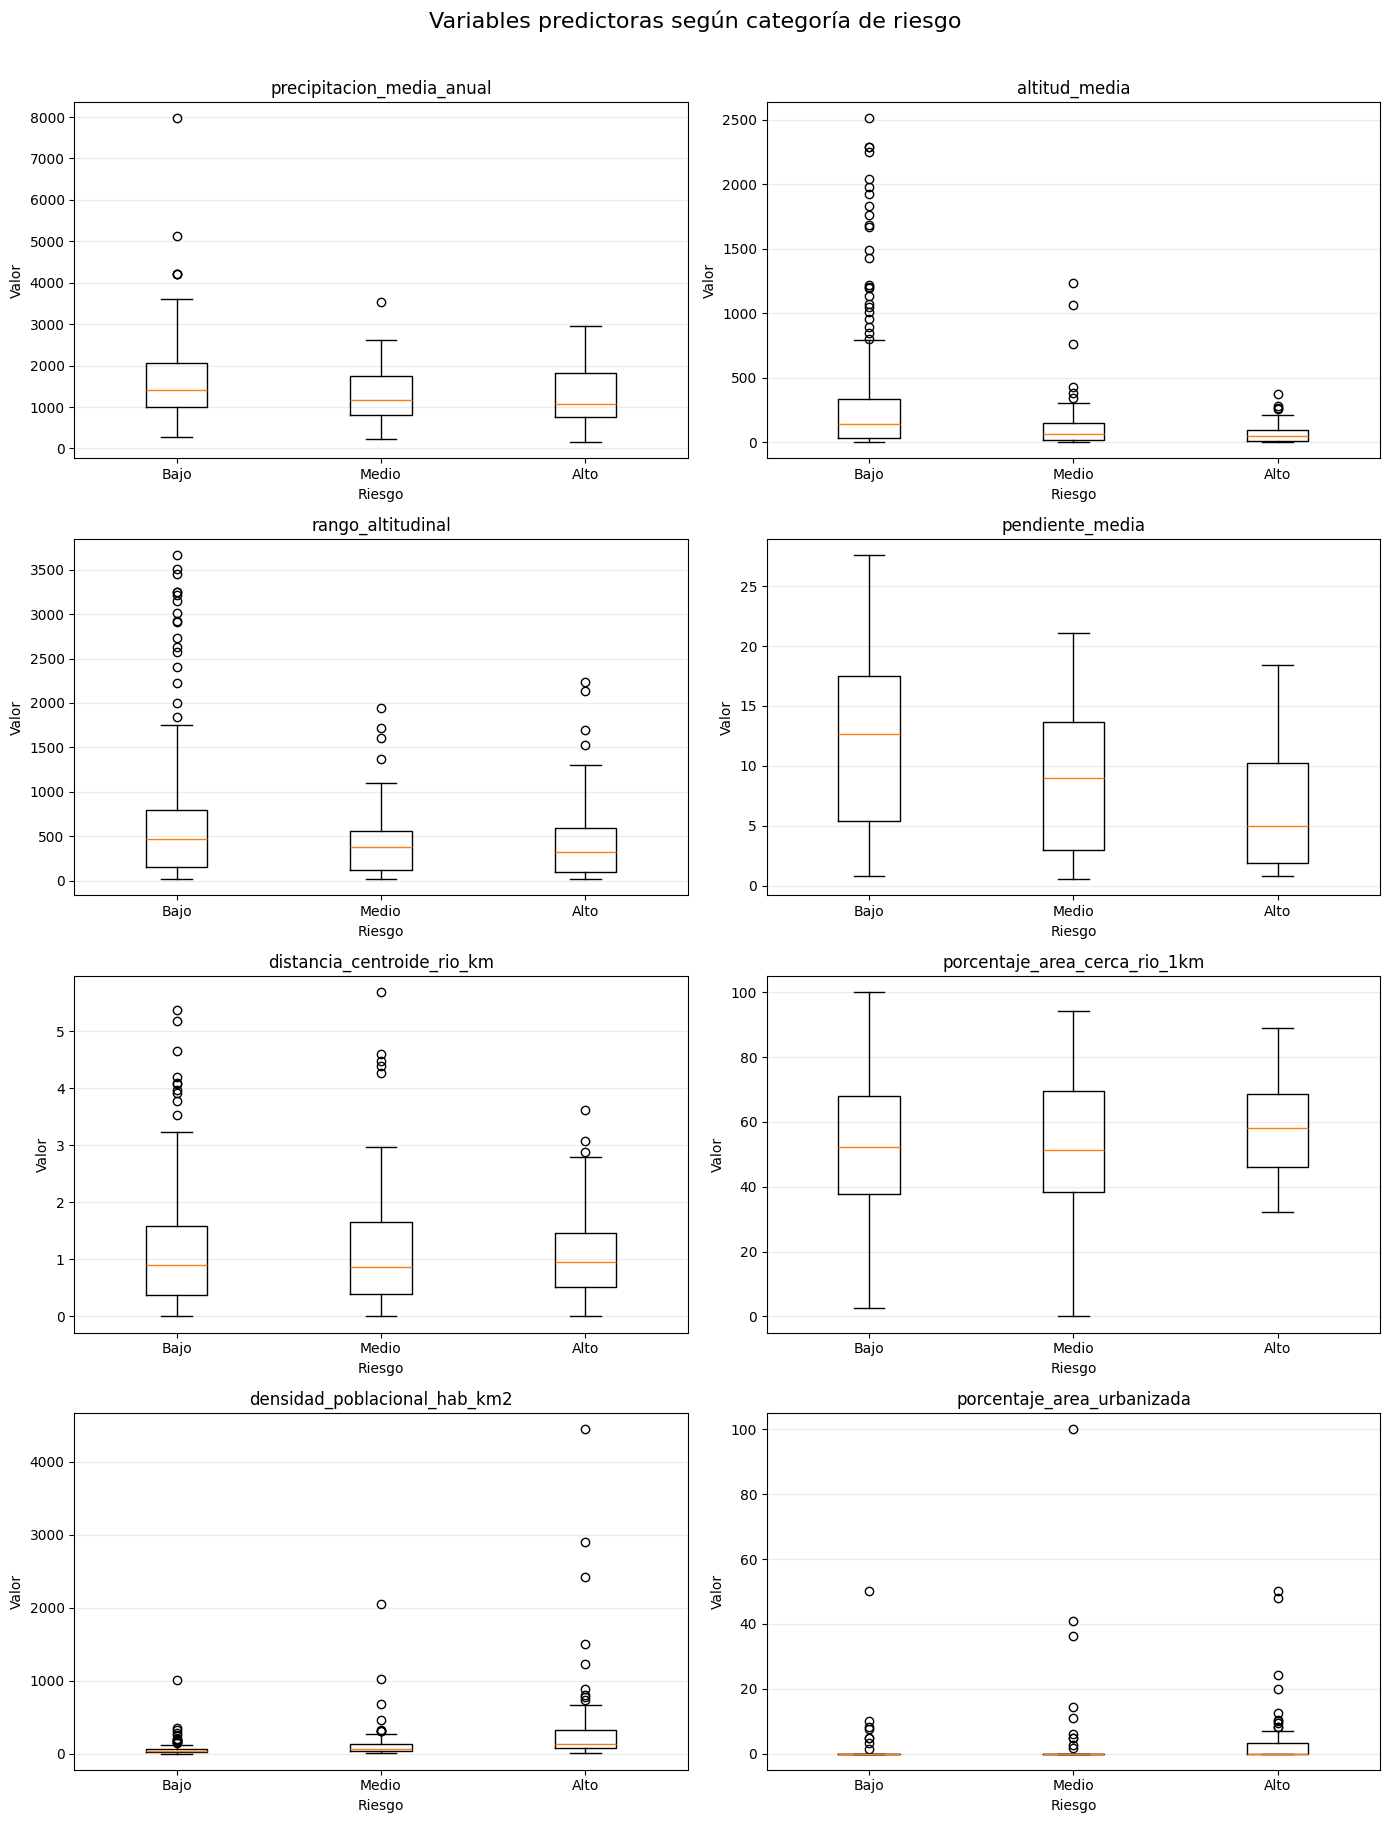

In [35]:
# ============================================================
# 12. Boxplots por categoría de riesgo
# ============================================================

# ------------------------------------------------------------
# Propósito: Comparar el comportamiento de los predictores entre clases de riesgo.
# Entradas principales: Variables predictoras y riesgo_inundacion.
# Proceso resumido: Dibuja boxplots por clase para observar diferencias, dispersión y
# valores atípicos.
# Salidas esperadas: boxplots_variables_por_riesgo.png.
# ------------------------------------------------------------
variables_prioritarias = [
    "precipitacion_media_anual",
    "altitud_media",
    "rango_altitudinal",
    "pendiente_media",
    "distancia_centroide_rio_km",
    "porcentaje_area_cerca_rio_1km",
    "densidad_poblacional_hab_km2",
    "porcentaje_area_urbanizada"
]

fig, axes = plt.subplots(
    4,
    2,
    figsize=(14, 18)
)

axes = axes.reshape(-1)

for eje, variable in zip(
    axes,
    variables_prioritarias
):
    datos_clases = [
        df.loc[
            df[OBJETIVO] == clase,
            variable
        ].dropna()
        for clase in CLASES_ORDEN
    ]

    eje.boxplot(
        datos_clases,
        labels=CLASES_ORDEN,
        showfliers=True
    )
    eje.set_title(variable)
    eje.set_xlabel("Riesgo")
    eje.set_ylabel("Valor")
    eje.grid(axis="y", alpha=0.25)

plt.suptitle(
    "Variables predictoras según categoría de riesgo",
    fontsize=16,
    y=1.01
)
plt.tight_layout()
plt.savefig(
    "boxplots_variables_por_riesgo.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

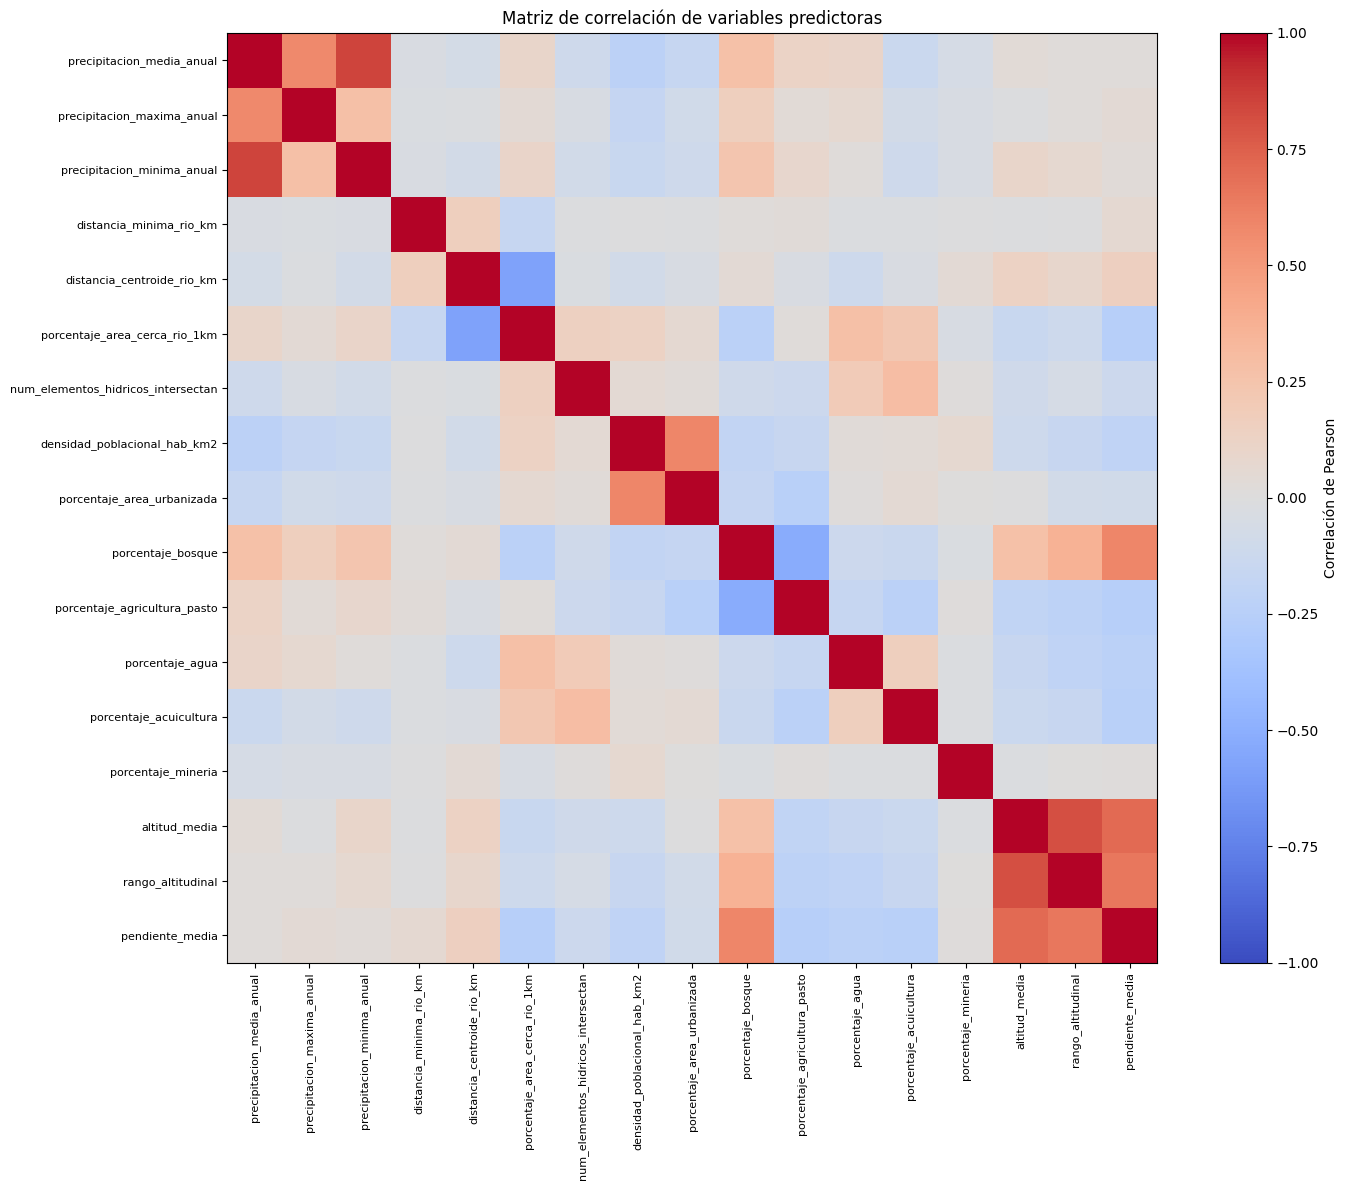

In [36]:
# ============================================================
# 13. Matriz de correlación
# ============================================================

# ------------------------------------------------------------
# Propósito: Evaluar relaciones lineales entre variables predictoras.
# Entradas principales: Variables numéricas.
# Proceso resumido: Calcula correlaciones y construye un mapa de calor.
# Salidas esperadas: matriz_correlacion.png.
# ------------------------------------------------------------
matriz_correlacion = (
    df[columnas_numericas]
    .corr(method="pearson")
)

fig, ax = plt.subplots(
    figsize=(15, 12)
)

imagen = ax.imshow(
    matriz_correlacion,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    range(len(columnas_numericas))
)
ax.set_yticks(
    range(len(columnas_numericas))
)

ax.set_xticklabels(
    columnas_numericas,
    rotation=90,
    fontsize=8
)
ax.set_yticklabels(
    columnas_numericas,
    fontsize=8
)

fig.colorbar(
    imagen,
    ax=ax,
    label="Correlación de Pearson"
)

ax.set_title(
    "Matriz de correlación de variables predictoras"
)

plt.tight_layout()
plt.savefig(
    "matriz_correlacion.png",
    dpi=180,
    bbox_inches="tight"
)
plt.show()

In [37]:
# ============================================================
# 14. Pares con correlación alta
# ============================================================

# ------------------------------------------------------------
# Propósito: Identificar posibles redundancias entre predictores.
# Entradas principales: Matriz de correlación.
# Proceso resumido: Extrae pares de variables con correlación absoluta superior al
# umbral definido.
# Salidas esperadas: reporte_correlaciones_altas.csv.
# ------------------------------------------------------------
pares_correlacion = []

for i, variable_1 in enumerate(
    columnas_numericas
):
    for variable_2 in columnas_numericas[
        i + 1:
    ]:
        correlacion = matriz_correlacion.loc[
            variable_1,
            variable_2
        ]

        if abs(correlacion) >= 0.80:
            pares_correlacion.append(
                {
                    "variable_1": variable_1,
                    "variable_2": variable_2,
                    "correlacion": correlacion,
                    "correlacion_absoluta": abs(
                        correlacion
                    )
                }
            )

reporte_correlaciones = pd.DataFrame(
    pares_correlacion
)

if reporte_correlaciones.empty:
    reporte_correlaciones = pd.DataFrame(
        columns=[
            "variable_1",
            "variable_2",
            "correlacion",
            "correlacion_absoluta"
        ]
    )
    print(
        "No se encontraron pares con |correlación| >= 0.80."
    )
else:
    reporte_correlaciones = (
        reporte_correlaciones
        .sort_values(
            "correlacion_absoluta",
            ascending=False
        )
    )
    display(reporte_correlaciones)

,variable_1,variable_2,correlacion,correlacion_absoluta
0,precipitacion_media_anual,precipitacion_minima_anual,0.8509,0.8509
1,altitud_media,rango_altitudinal,0.8082,0.8082


In [38]:
# ============================================================
# 15. Valores atípicos mediante criterio IQR
# ============================================================

# ------------------------------------------------------------
# Propósito: Cuantificar valores extremos sin eliminarlos automáticamente.
# Entradas principales: Variables numéricas.
# Proceso resumido: Aplica el criterio del rango intercuartílico para contar posibles
# outliers por variable.
# Salidas esperadas: reporte_valores_atipicos.csv.
# ------------------------------------------------------------
registros_outliers = []

for columna in columnas_numericas:
    serie = df[columna].dropna()

    if serie.empty:
        continue

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara = (
        (serie < limite_inferior)
        | (serie > limite_superior)
    )

    registros_outliers.append(
        {
            "variable": columna,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "limite_inferior": limite_inferior,
            "limite_superior": limite_superior,
            "cantidad_atipicos": int(
                mascara.sum()
            ),
            "porcentaje_atipicos": round(
                mascara.mean() * 100,
                2
            )
        }
    )

reporte_outliers = (
    pd.DataFrame(registros_outliers)
    .sort_values(
        "cantidad_atipicos",
        ascending=False
    )
)

display(reporte_outliers)

print(
    "Los valores atípicos se conservan. "
    "No se aplicó winsorización ni eliminación automática."
)

,variable,q1,q3,iqr,limite_inferior,limite_superior,cantidad_atipicos,porcentaje_atipicos
11,porcentaje_agua,0.0000,0.0000,0.0000,0.0000,0.0000,52,17.6900
6,num_elementos_hidricos_intersectan,10.0000,64.5000,54.5000,-71.7500,146.2500,46,15.3300
8,porcentaje_area_urbanizada,0.0000,0.0000,0.0000,0.0000,0.0000,41,13.9500
12,porcentaje_acuicultura,0.0000,0.0000,0.0000,0.0000,0.0000,38,12.9300
14,altitud_media,24.2562,220.0401,195.7839,-269.4196,513.7159,35,11.6700
7,densidad_poblacional_hab_km2,24.0000,111.2500,87.2500,-106.8750,242.1250,30,10.0000
15,rango_altitudinal,128.2208,679.3695,551.1488,-698.5024,"1,506.0927",28,9.3300
1,precipitacion_maxima_anual,"1,920.5250","4,192.6800","2,272.1550","-1,487.7075","7,600.9125",18,6.0000
4,distancia_centroide_rio_km,0.3947,1.5738,1.1791,-1.3739,3.3424,16,5.3300
2,precipitacion_minima_anual,248.8800,893.3886,644.5086,-717.8830,"1,860.1516",13,4.3300


Los valores atípicos se conservan. No se aplicó winsorización ni eliminación automática.


riesgo_inundacion,Bajo,Medio,Alto,All
provincia_modelo,,,,
EL ORO,50,8,6,64
ESMERALDAS,39,18,7,64
GUAYAS,18,19,17,54
LOS RIOS,11,6,13,30
MANABI,42,21,14,77
SANTA ELENA,4,4,3,11
All,164,76,60,300


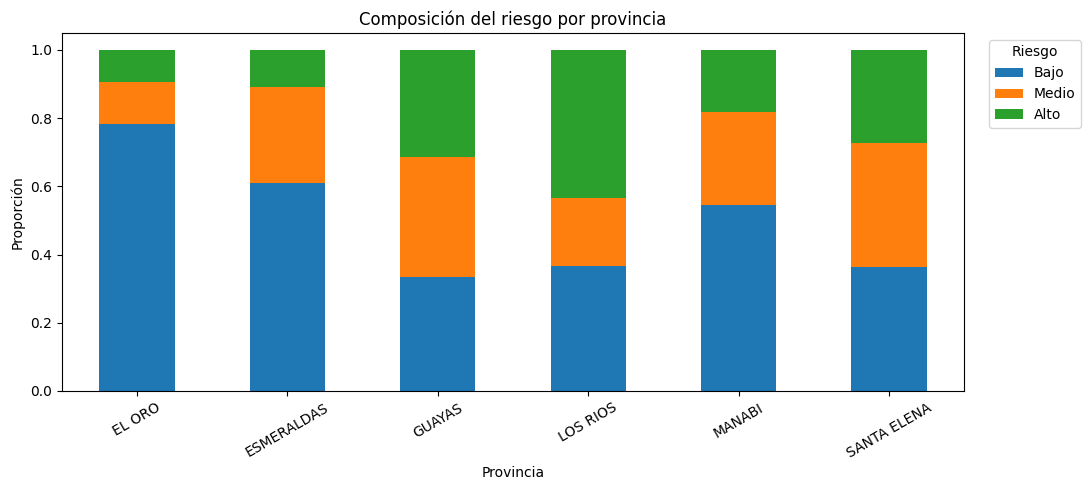

In [39]:
# ============================================================
# 16. Análisis del riesgo por provincia
# ============================================================

# ------------------------------------------------------------
# Propósito: Examinar cómo se distribuyen las clases de riesgo en cada provincia.
# Entradas principales: provincia_modelo y riesgo_inundacion.
# Proceso resumido: Agrupa por provincia y clase, calcula frecuencias y produce una
# gráfica comparativa.
# Salidas esperadas: riesgo_por_provincia.png.
# ------------------------------------------------------------
tabla_provincia_riesgo = pd.crosstab(
    df["provincia_modelo"],
    df[OBJETIVO],
    margins=True
)

display(tabla_provincia_riesgo)

proporciones_provincia = pd.crosstab(
    df["provincia_modelo"],
    df[OBJETIVO],
    normalize="index"
).reindex(
    columns=CLASES_ORDEN
).fillna(0)

proporciones_provincia.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 5)
)

plt.title(
    "Composición del riesgo por provincia"
)
plt.xlabel("Provincia")
plt.ylabel("Proporción")
plt.xticks(rotation=30)
plt.legend(
    title="Riesgo",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.savefig(
    "riesgo_por_provincia.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

In [40]:
# ============================================================
# 17. Comparación de medianas por clase
# ============================================================

# ------------------------------------------------------------
# Propósito: Resumir qué valores típicos presentan los predictores para cada nivel de
# riesgo.
# Entradas principales: Variables predictoras y riesgo_inundacion.
# Proceso resumido: Calcula medianas por clase para apoyar la interpretación del EDA.
# Salidas esperadas: Tabla de medianas por riesgo mostrada en pantalla.
# ------------------------------------------------------------
medianas_por_clase = (
    df.groupby(
        OBJETIVO,
        observed=True
    )[columnas_numericas]
    .median()
    .reindex(CLASES_ORDEN)
)

display(medianas_por_clase.T)

riesgo_inundacion,Bajo,Medio,Alto
precipitacion_media_anual,"1,417.9430","1,173.5786","1,079.7215"
precipitacion_maxima_anual,"3,051.8818","2,436.2500","2,937.8400"
precipitacion_minima_anual,564.7473,421.6000,447.9500
distancia_minima_rio_km,0.0000,0.0000,0.0000
distancia_centroide_rio_km,0.9083,0.8663,0.9565
porcentaje_area_cerca_rio_1km,52.3840,51.1936,58.1888
num_elementos_hidricos_intersectan,14.0000,31.5000,61.5000
densidad_poblacional_hab_km2,33.0000,66.5000,126.0000
porcentaje_area_urbanizada,0.0000,0.0000,0.0000
porcentaje_bosque,25.0000,19.3750,2.7241


## 3.2. Preparación de las particiones

Los códigos territoriales se conservan para trazabilidad y para la futura aplicación cartográfica, pero no deben utilizarse directamente como predictores numéricos.

In [41]:
# ============================================================
# 18. Definición de X, y e identificadores
# ============================================================

# ------------------------------------------------------------
# Propósito: Separar predictores, variable objetivo e identificadores territoriales.
# Entradas principales: df_eda limpio.
# Proceso resumido: Define columnas excluidas, crea X, y e identificadores, y valida que
# no existan variables de fuga como eventos_inundacion.
# Salidas esperadas: Matrices X, y e identificadores para train/test.
# ------------------------------------------------------------
VARIABLES_PREDICTORAS = [
    "precipitacion_media_anual",
    "precipitacion_maxima_anual",
    "precipitacion_minima_anual",
    "altitud_media",
    "rango_altitudinal",
    "pendiente_media",
    "distancia_minima_rio_km",
    "distancia_centroide_rio_km",
    "porcentaje_area_cerca_rio_1km",
    "num_elementos_hidricos_intersectan",
    "densidad_poblacional_hab_km2",
    "porcentaje_area_urbanizada",
    "porcentaje_bosque",
    "porcentaje_agricultura_pasto",
    "porcentaje_agua",
    "porcentaje_acuicultura",
    "porcentaje_mineria"
]

faltantes_modelo = [
    c for c in VARIABLES_PREDICTORAS
    if c not in df.columns
]

if faltantes_modelo:
    raise KeyError(
        f"Faltan predictores: {faltantes_modelo}"
    )

X = df[
    VARIABLES_PREDICTORAS
].copy()

y = df[
    OBJETIVO
].copy()

identificadores = df[
    IDENTIFICADORES
].copy()

print("X:", X.shape)
print("y:", y.shape)
print(
    "Valores faltantes en X:",
    int(X.isna().sum().sum())
)

X: (300, 17)
y: (300,)
Valores faltantes en X: 36


In [42]:
# ============================================================
# 19. División estratificada train/test
# ============================================================

# ------------------------------------------------------------
# Propósito: Crear conjuntos de entrenamiento y prueba manteniendo la proporción de clases.
# Entradas principales: X, y e identificadores.
# Proceso resumido: Usa train_test_split con estratificación para preservar el balance
# de riesgo en ambos conjuntos.
# Salidas esperadas: df_train y df_test.
# ------------------------------------------------------------
indices_train, indices_test = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

dataset_train = (
    df.loc[indices_train]
    .sort_values("codigo_parroquia")
    .reset_index(drop=True)
)

dataset_test = (
    df.loc[indices_test]
    .sort_values("codigo_parroquia")
    .reset_index(drop=True)
)

print("Entrenamiento:", dataset_train.shape)
print("Prueba:", dataset_test.shape)

print("\nDistribución entrenamiento:")
print(
    dataset_train[OBJETIVO]
    .value_counts(normalize=True)
    .reindex(CLASES_ORDEN)
    .round(3)
)

print("\nDistribución prueba:")
print(
    dataset_test[OBJETIVO]
    .value_counts(normalize=True)
    .reindex(CLASES_ORDEN)
    .round(3)
)

Entrenamiento: (225, 21)
Prueba: (75, 21)

Distribución entrenamiento:
riesgo_inundacion
Bajo    0.5470
Medio   0.2530
Alto    0.2000
Name: proportion, dtype: float64

Distribución prueba:
riesgo_inundacion
Bajo    0.5470
Medio   0.2530
Alto    0.2000
Name: proportion, dtype: float64


In [43]:
# ============================================================
# 20. Dataset limpio y verificación final
# ============================================================

# ------------------------------------------------------------
# Propósito: Construir la versión final del dataset limpio y verificar su estado antes
# de exportar.
# Entradas principales: df_eda, df_train y df_test.
# Proceso resumido: Revisa dimensiones, clases, faltantes, duplicados y consistencia de
# columnas.
# Salidas esperadas: dataset_inundacion_limpio preparado para modelado.
# ------------------------------------------------------------
columnas_finales = (
    IDENTIFICADORES
    + VARIABLES_PREDICTORAS
    + [OBJETIVO]
)

dataset_limpio = (
    df[columnas_finales]
    .sort_values("codigo_parroquia")
    .reset_index(drop=True)
)

validaciones = {
    "filas": int(len(dataset_limpio)),
    "columnas": int(dataset_limpio.shape[1]),
    "duplicados_completos": int(
        dataset_limpio.duplicated().sum()
    ),
    "codigos_duplicados": int(
        dataset_limpio[
            "codigo_parroquia"
        ].duplicated().sum()
    ),
    "objetivos_faltantes": int(
        dataset_limpio[
            OBJETIVO
        ].isna().sum()
    ),
    "predictores_faltantes": int(
        dataset_limpio[
            VARIABLES_PREDICTORAS
        ].isna().sum().sum()
    ),
    "numero_clases": int(
        dataset_limpio[
            OBJETIVO
        ].nunique()
    )
}

print(json.dumps(
    validaciones,
    ensure_ascii=False,
    indent=2
))

if validaciones["codigos_duplicados"] > 0:
    raise ValueError(
        "El dataset todavía contiene códigos duplicados."
    )

if validaciones["objetivos_faltantes"] > 0:
    raise ValueError(
        "El dataset todavía contiene etiquetas faltantes."
    )

print(
    "El dataset está estructuralmente listo "
    "para la etapa de entrenamiento."
)

{
  "filas": 300,
  "columnas": 21,
  "duplicados_completos": 0,
  "codigos_duplicados": 0,
  "objetivos_faltantes": 0,
  "predictores_faltantes": 36,
  "numero_clases": 3
}
El dataset está estructuralmente listo para la etapa de entrenamiento.


In [44]:
# ============================================================
# 21. Exportación de resultados
# ============================================================

# ------------------------------------------------------------
# Propósito: Guardar todos los productos generados en el EDA.
# Entradas principales: Dataset limpio, train/test, reportes y gráficos.
# Proceso resumido: Exporta CSV, PNG, JSON y metadatos de la etapa 3.
# Salidas esperadas: Archivos de EDA y preparación de entrenamiento en /content.
# ------------------------------------------------------------
dataset_limpio.to_csv(
    EDA_SALIDAS["limpio"],
    index=False,
    encoding="utf-8-sig"
)

dataset_train.to_csv(
    EDA_SALIDAS["train"],
    index=False,
    encoding="utf-8-sig"
)

dataset_test.to_csv(
    EDA_SALIDAS["test"],
    index=False,
    encoding="utf-8-sig"
)

reporte_nulos.to_csv(
    EDA_SALIDAS["nulos"],
    index=False,
    encoding="utf-8-sig"
)

reporte_outliers.to_csv(
    EDA_SALIDAS["outliers"],
    index=False,
    encoding="utf-8-sig"
)

reporte_correlaciones.to_csv(
    EDA_SALIDAS["correlaciones"],
    index=False,
    encoding="utf-8-sig"
)

reporte_balance.to_csv(
    EDA_SALIDAS["balance"],
    index=False,
    encoding="utf-8-sig"
)

estadisticas.to_csv(
    EDA_SALIDAS["estadisticas"],
    encoding="utf-8-sig"
)

metadatos = {
    "archivo_entrada": ARCHIVO_ENTRADA,
    "filas_finales": len(dataset_limpio),
    "columnas_finales": dataset_limpio.shape[1],
    "identificadores": IDENTIFICADORES,
    "variables_predictoras": VARIABLES_PREDICTORAS,
    "variable_objetivo": OBJETIVO,
    "clases": CLASES_ORDEN,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "razon_desbalance": float(
        razon_desbalance
    ),
    "estrategia_nulos": (
        "La etiqueta no se imputa. "
        "Los predictores deben imputarse dentro "
        "del pipeline de entrenamiento."
    ),
    "estrategia_outliers": (
        "Se reportan y conservan; no se eliminan "
        "automáticamente."
    )
}

with open(
    EDA_SALIDAS["metadatos"],
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(
        metadatos,
        archivo,
        ensure_ascii=False,
        indent=2
    )

archivos_para_zip = [
    EDA_SALIDAS["limpio"],
    EDA_SALIDAS["train"],
    EDA_SALIDAS["test"],
    EDA_SALIDAS["nulos"],
    EDA_SALIDAS["outliers"],
    EDA_SALIDAS["correlaciones"],
    EDA_SALIDAS["balance"],
    EDA_SALIDAS["estadisticas"],
    EDA_SALIDAS["metadatos"],
    "grafico_balance_clases.png",
    "histogramas_variables_predictoras.png",
    "boxplots_variables_por_riesgo.png",
    "matriz_correlacion.png",
    "riesgo_por_provincia.png"
]

with zipfile.ZipFile(
    EDA_SALIDAS["paquete"],
    "w",
    compression=zipfile.ZIP_DEFLATED
) as archivo_zip:
    for nombre in archivos_para_zip:
        ruta_archivo = Path(nombre)

        if ruta_archivo.exists():
            archivo_zip.write(
                ruta_archivo,
                arcname=ruta_archivo.name
            )

print("Archivos exportados:")
for nombre in archivos_para_zip:
    if Path(nombre).exists():
        print(" -", nombre)

print(" -", EDA_SALIDAS["paquete"])

Archivos exportados:
 - dataset_inundacion_limpio.csv
 - dataset_inundacion_train.csv
 - dataset_inundacion_test.csv
 - reporte_valores_faltantes.csv
 - reporte_valores_atipicos.csv
 - reporte_correlaciones_altas.csv
 - reporte_balance_clases.csv
 - estadisticas_descriptivas.csv
 - metadatos_eda.json
 - grafico_balance_clases.png
 - histogramas_variables_predictoras.png
 - boxplots_variables_por_riesgo.png
 - matriz_correlacion.png
 - riesgo_por_provincia.png
 - resultados_eda_inundacion.zip


In [45]:
# ============================================================
# 13. Empaquetado de todos los resultados
# ============================================================

# ------------------------------------------------------------
# Propósito: Comprimir los resultados de las primeras tres etapas.
# Entradas principales: Archivos intermedios y finales generados hasta el EDA.
# Proceso resumido: Crea un archivo ZIP con datasets, reportes y gráficos disponibles.
# Salidas esperadas: proyecto_inundacion_3_etapas_resultados.zip.
# ------------------------------------------------------------
archivos_resultado = [
    SALIDAS["catalogo"],
    SALIDAS["precipitacion"],
    SALIDAS["hidrografia_cruda"],
    SALIDAS["hidrografia"],
    SALIDAS["poblacion"],
    SALIDAS["uso_suelo"],
    SALIDAS["predictoras"],
    SALIDAS["calidad_predictoras"],
    SALIDAS["cobertura_predictoras"],
    SALIDAS["objetivo"],
    SALIDAS["eventos_anuales"],
    SALIDAS["topografia"],
    SALIDAS["dataset_inundacion"],
    SALIDAS["umbrales"],
    "reporte_integracion_fuentes.csv",
    EDA_SALIDAS["limpio"],
    EDA_SALIDAS["train"],
    EDA_SALIDAS["test"],
    EDA_SALIDAS["nulos"],
    EDA_SALIDAS["outliers"],
    EDA_SALIDAS["correlaciones"],
    EDA_SALIDAS["balance"],
    EDA_SALIDAS["estadisticas"],
    EDA_SALIDAS["metadatos"],
    "grafico_balance_clases.png",
    "histogramas_variables_predictoras.png",
    "boxplots_variables_por_riesgo.png",
    "matriz_correlacion.png",
    "riesgo_por_provincia.png"
]

ruta_paquete_final = Path("/content") / SALIDA_PAQUETE_FINAL

with zipfile.ZipFile(
    ruta_paquete_final,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as archivo_zip:
    for nombre in archivos_resultado:
        ruta_archivo = Path("/content") / nombre

        if ruta_archivo.exists():
            archivo_zip.write(
                ruta_archivo,
                arcname=ruta_archivo.name
            )

print("Paquete final:", ruta_paquete_final)
print("\nArchivos principales:")
print(" -", SALIDAS["predictoras"])
print(" -", SALIDAS["dataset_inundacion"])
print(" -", EDA_SALIDAS["limpio"])
print(" -", EDA_SALIDAS["train"])
print(" -", EDA_SALIDAS["test"])

Paquete final: /content/proyecto_inundacion_3_etapas_resultados.zip

Archivos principales:
 - dataset_predictoras_parroquias.csv
 - dataset_inundacion.csv
 - dataset_inundacion_limpio.csv
 - dataset_inundacion_train.csv
 - dataset_inundacion_test.csv


In [46]:
# ============================================================
# 14. Descarga del paquete final
# ============================================================

# ------------------------------------------------------------
# Propósito: Facilitar la descarga del paquete de resultados desde Colab.
# Entradas principales: ZIP generado de las tres etapas.
# Proceso resumido: Llama a files.download cuando el cuaderno se ejecuta en Google Colab.
# Salidas esperadas: Descarga local del ZIP de resultados.
# ------------------------------------------------------------
try:
    from google.colab import files

    files.download(
        str(ruta_paquete_final)
    )

except ImportError:
    print(
        "La descarga automática funciona cuando "
        "el cuaderno se ejecuta en Google Colab."
    )

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Resultado parcial de las etapas 1 a 3

Al concluir la ejecución de las primeras tres etapas estarán disponibles:

```text
dataset_predictoras_parroquias.csv
dataset_inundacion.csv
dataset_inundacion_limpio.csv
dataset_inundacion_train.csv
dataset_inundacion_test.csv
```




# ETAPA 4. Entrenamiento de modelos de clasificación

Esta etapa utiliza el dataset limpio y las particiones estratificadas generadas en la etapa 3.  
El objetivo es entrenar varios modelos supervisados para clasificar el riesgo histórico de inundación por parroquia en tres clases: **Bajo**, **Medio** y **Alto**.

Se entrenan:

- Regresión Logística;
- Árbol de Decisión;
- SVM;
- Random Forest;
- Ensamble Voting.


In [47]:
# ------------------------------------------------------------
# Propósito: Cargar las herramientas necesarias para entrenamiento, optimización,
# evaluación y guardado de modelos.
# Entradas principales: Paquetes de scikit-learn, joblib, matplotlib, pandas y numpy.
# Proceso resumido: Importa clasificadores, métricas, validación cruzada, pipelines,
# imputadores, escaladores y utilidades de exportación.
# Salidas esperadas: Entorno de modelado listo para las etapas 4 a 8.
# ------------------------------------------------------------

# ============================================================
# 1. Importación de librerías para modelado
# ============================================================

import time
import joblib
import sklearn

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc
)

print("Librerías de modelado importadas.")
print("Versión scikit-learn:", sklearn.__version__)


Librerías de modelado importadas.
Versión scikit-learn: 1.6.1


In [48]:
# ------------------------------------------------------------
# Propósito: Definir nombres de archivos, semilla aleatoria y etiquetas de clases para
# modelado y mapa.
# Entradas principales: Resultados del EDA y parámetros del proyecto.
# Proceso resumido: Crea rutas de salida para modelos, métricas, predicciones, GeoJSON y
# mapa Folium.
# Salidas esperadas: Diccionario SALIDAS_MODELO y constantes de entrenamiento/configuración.
# ------------------------------------------------------------

# ============================================================
# 2. Configuración de las etapas 4 a 8
# ============================================================

ARCHIVO_DATASET_LIMPIO = EDA_SALIDAS.get(
    "limpio",
    "dataset_inundacion_limpio.csv"
)

ARCHIVO_DATASET_TRAIN = EDA_SALIDAS.get(
    "train",
    "dataset_inundacion_train.csv"
)

ARCHIVO_DATASET_TEST = EDA_SALIDAS.get(
    "test",
    "dataset_inundacion_test.csv"
)

MODELADO_SALIDAS = {
    "comparacion": "comparacion_modelos_inundacion.csv",
    "classification_reports": "classification_reports_modelos.json",
    "auc_clases": "auc_por_clase_mejor_modelo.csv",
    "predicciones_test": "predicciones_conjunto_prueba.csv",
    "importancias": "importancia_variables_inundacion.csv",
    "modelo": "mejor_modelo_riesgo_inundacion.joblib",
    "modelo_legacy": "modelo_riesgo_inundacion.joblib",
    "columnas": "columnas_modelo.json",
    "clases": "clases_modelo.json",
    "metricas": "metricas_modelo.json",
    "predicciones_todas": "predicciones_todas_parroquias.csv",
    "geojson_mapa": "parroquias_riesgo.geojson",
    "gpkg_mapa": "parroquias_riesgo.gpkg",
    "html_mapa": "mapa_riesgo_inundacion_folium.html",
    "paquete_final": "proyecto_inundacion_8_etapas_resultados.zip"
}

RANDOM_STATE_MODELO = RANDOM_STATE
N_SPLITS_CV_MODELO = 5

CODIFICACION_RIESGO = {
    "Bajo": 0,
    "Medio": 1,
    "Alto": 2
}

DECODIFICACION_RIESGO = {
    0: "Bajo",
    1: "Medio",
    2: "Alto"
}

CLASES_NUMERICAS = [0, 1, 2]
NOMBRES_CLASES = ["Bajo", "Medio", "Alto"]

print("Archivos de entrada para modelado:")
print("-", ARCHIVO_DATASET_LIMPIO)
print("-", ARCHIVO_DATASET_TRAIN)
print("-", ARCHIVO_DATASET_TEST)


Archivos de entrada para modelado:
- dataset_inundacion_limpio.csv
- dataset_inundacion_train.csv
- dataset_inundacion_test.csv


In [49]:
# ------------------------------------------------------------
# Propósito: Cargar los conjuntos train/test generados en el EDA.
# Entradas principales: dataset_inundacion_train.csv, dataset_inundacion_test.csv y
# dataset_inundacion_limpio.csv.
# Proceso resumido: Lee los archivos, normaliza códigos y valida que existan las
# columnas necesarias para modelar.
# Salidas esperadas: df_train_modelo, df_test_modelo y df_limpio_modelo.
# ------------------------------------------------------------

# ============================================================
# 3. Carga de datasets de entrenamiento y prueba
# ============================================================

def leer_dataset_modelado(ruta):
    return pd.read_csv(
        ruta,
        encoding="utf-8-sig",
        dtype={
            "codigo_parroquia": "string",
            "codigo_provincia": "string"
        }
    )


if Path(ARCHIVO_DATASET_TRAIN).exists() and Path(ARCHIVO_DATASET_TEST).exists():
    dataset_train_modelo = leer_dataset_modelado(
        ARCHIVO_DATASET_TRAIN
    )

    dataset_test_modelo = leer_dataset_modelado(
        ARCHIVO_DATASET_TEST
    )

    dataset_modelo = leer_dataset_modelado(
        ARCHIVO_DATASET_LIMPIO
    )

    print("Se utilizaron las particiones generadas en la etapa 3.")

else:
    print(
        "No se encontraron las particiones train/test. "
        "Se realizará una división estratificada desde el dataset limpio."
    )

    dataset_modelo = leer_dataset_modelado(
        ARCHIVO_DATASET_LIMPIO
    )

    indices_train_modelo, indices_test_modelo = train_test_split(
        dataset_modelo.index,
        test_size=TEST_SIZE,
        stratify=dataset_modelo[OBJETIVO],
        random_state=RANDOM_STATE_MODELO
    )

    dataset_train_modelo = (
        dataset_modelo.loc[indices_train_modelo]
        .reset_index(drop=True)
    )

    dataset_test_modelo = (
        dataset_modelo.loc[indices_test_modelo]
        .reset_index(drop=True)
    )


for nombre_df, datos in {
    "dataset_modelo": dataset_modelo,
    "dataset_train_modelo": dataset_train_modelo,
    "dataset_test_modelo": dataset_test_modelo
}.items():

    if "codigo_parroquia" in datos.columns:
        datos["codigo_parroquia"] = (
            datos["codigo_parroquia"]
            .astype("string")
            .str.replace(r"\.0$", "", regex=True)
            .str.strip()
            .str.zfill(6)
        )

    if OBJETIVO not in datos.columns:
        raise KeyError(
            f"{nombre_df} no contiene la variable objetivo {OBJETIVO}."
        )

    datos[OBJETIVO] = (
        datos[OBJETIVO]
        .astype(str)
        .str.strip()
        .str.capitalize()
    )


print("Dataset limpio:", dataset_modelo.shape)
print("Train:", dataset_train_modelo.shape)
print("Test:", dataset_test_modelo.shape)

print("\nDistribución train:")
print(
    dataset_train_modelo[OBJETIVO]
    .value_counts()
    .reindex(NOMBRES_CLASES)
)

print("\nDistribución test:")
print(
    dataset_test_modelo[OBJETIVO]
    .value_counts()
    .reindex(NOMBRES_CLASES)
)


Se utilizaron las particiones generadas en la etapa 3.
Dataset limpio: (300, 21)
Train: (225, 21)
Test: (75, 21)

Distribución train:
riesgo_inundacion
Bajo     123
Medio     57
Alto      45
Name: count, dtype: int64

Distribución test:
riesgo_inundacion
Bajo     41
Medio    19
Alto     15
Name: count, dtype: int64


In [50]:
# ------------------------------------------------------------
# Propósito: Preparar matrices finales para entrenar modelos sin fuga de información.
# Entradas principales: Datasets train/test/limpio.
# Proceso resumido: Excluye identificadores y variables no predictoras, define X_train,
# X_test, y_train, y_test y valida columnas.
# Salidas esperadas: Conjuntos de modelado y listas de columnas predictoras.
# ------------------------------------------------------------

# ============================================================
# 4. Definición de X, y e identificadores para modelado
# ============================================================

COLUMNAS_IDENTIFICADORAS_MODELO = [
    "codigo_parroquia",
    "codigo_provincia",
    "provincia_modelo",
    "provincia",
    "canton",
    "parroquia"
]

COLUMNAS_FUGA_MODELO = [
    "eventos_inundacion",
    "conteo_inundaciones",
    "numero_eventos",
    "indice_historico",
    "indice_riesgo"
]

if "VARIABLES_PREDICTORAS" in globals():
    variables_modelo = [
        columna
        for columna in VARIABLES_PREDICTORAS
        if columna in dataset_modelo.columns
    ]
else:
    columnas_excluir = (
        [OBJETIVO]
        + [
            columna
            for columna in COLUMNAS_IDENTIFICADORAS_MODELO
            if columna in dataset_modelo.columns
        ]
        + [
            columna
            for columna in COLUMNAS_FUGA_MODELO
            if columna in dataset_modelo.columns
        ]
    )

    variables_modelo = (
        dataset_modelo
        .drop(columns=columnas_excluir, errors="ignore")
        .select_dtypes(include=[np.number])
        .columns
        .tolist()
    )

if not variables_modelo:
    raise ValueError(
        "No se identificaron variables predictoras para el modelo."
    )

# Evitar columnas completamente vacías, porque no aportan información.
columnas_totalmente_vacias = [
    columna
    for columna in variables_modelo
    if dataset_modelo[columna].isna().all()
]

if columnas_totalmente_vacias:
    print(
        "Advertencia: se excluirán columnas completamente vacías:",
        columnas_totalmente_vacias
    )

variables_modelo = [
    columna
    for columna in variables_modelo
    if columna not in columnas_totalmente_vacias
]

for datos in [
    dataset_modelo,
    dataset_train_modelo,
    dataset_test_modelo
]:
    for columna in variables_modelo:
        datos[columna] = pd.to_numeric(
            datos[columna],
            errors="coerce"
        )

X_train_modelo = dataset_train_modelo[variables_modelo].copy()
X_test_modelo = dataset_test_modelo[variables_modelo].copy()
X_total_modelo = dataset_modelo[variables_modelo].copy()

y_train_modelo = dataset_train_modelo[OBJETIVO].map(
    CODIFICACION_RIESGO
)
y_test_modelo = dataset_test_modelo[OBJETIVO].map(
    CODIFICACION_RIESGO
)
y_total_modelo = dataset_modelo[OBJETIVO].map(
    CODIFICACION_RIESGO
)

if y_train_modelo.isna().any() or y_test_modelo.isna().any():
    raise ValueError(
        "Existen clases de riesgo que no pudieron codificarse."
    )

identificadores_test = dataset_test_modelo[
    [
        columna
        for columna in COLUMNAS_IDENTIFICADORAS_MODELO
        if columna in dataset_test_modelo.columns
    ]
].copy()

identificadores_total = dataset_modelo[
    [
        columna
        for columna in COLUMNAS_IDENTIFICADORAS_MODELO
        if columna in dataset_modelo.columns
    ]
].copy()

print("Variables predictoras utilizadas:", len(variables_modelo))
print(variables_modelo)

print("\nValores faltantes en train:", int(X_train_modelo.isna().sum().sum()))
print("Valores faltantes en test:", int(X_test_modelo.isna().sum().sum()))
print("Valores faltantes en total:", int(X_total_modelo.isna().sum().sum()))


Variables predictoras utilizadas: 17
['precipitacion_media_anual', 'precipitacion_maxima_anual', 'precipitacion_minima_anual', 'altitud_media', 'rango_altitudinal', 'pendiente_media', 'distancia_minima_rio_km', 'distancia_centroide_rio_km', 'porcentaje_area_cerca_rio_1km', 'num_elementos_hidricos_intersectan', 'densidad_poblacional_hab_km2', 'porcentaje_area_urbanizada', 'porcentaje_bosque', 'porcentaje_agricultura_pasto', 'porcentaje_agua', 'porcentaje_acuicultura', 'porcentaje_mineria']

Valores faltantes en train: 12
Valores faltantes en test: 24
Valores faltantes en total: 36


In [51]:
# ------------------------------------------------------------
# Propósito: Definir modelos iniciales para comparar enfoques de clasificación.
# Entradas principales: Columnas predictoras y configuración de clase/semilla.
# Proceso resumido: Crea pipelines con imputación, escalado cuando aplica y
# clasificadores base: Regresión Logística, Árbol, SVM y Random Forest.
# Salidas esperadas: Diccionario modelos_base listo para entrenamiento.
# ------------------------------------------------------------

# ============================================================
# 5. Modelos base de clasificación
# ============================================================

pipeline_logistico = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler()),
        (
            "clasificador",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE_MODELO,
                multi_class="auto"
            )
        )
    ]
)

pipeline_arbol_base = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
        (
            "clasificador",
            DecisionTreeClassifier(
                class_weight="balanced",
                random_state=RANDOM_STATE_MODELO
            )
        )
    ]
)

pipeline_svm_base = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler()),
        (
            "clasificador",
            SVC(
                kernel="rbf",
                probability=True,
                class_weight="balanced",
                random_state=RANDOM_STATE_MODELO
            )
        )
    ]
)

pipeline_rf_base = Pipeline(
    steps=[
        ("imputador", SimpleImputer(strategy="median")),
        (
            "clasificador",
            RandomForestClassifier(
                n_estimators=300,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE_MODELO,
                n_jobs=-1
            )
        )
    ]
)

modelos_base = {
    "Regresión Logística": pipeline_logistico,
    "Árbol de Decisión base": pipeline_arbol_base,
    "SVM base": pipeline_svm_base,
    "Random Forest base": pipeline_rf_base
}

print("Modelos base definidos:")
print(list(modelos_base.keys()))


Modelos base definidos:
['Regresión Logística', 'Árbol de Decisión base', 'SVM base', 'Random Forest base']


# ETAPA 5. Optimización de hiperparámetros

La optimización se realiza mediante `GridSearchCV` con validación cruzada estratificada.  
La métrica de búsqueda es `f1_macro`, porque el problema tiene tres clases y se requiere evaluar el desempeño promedio sin favorecer únicamente a la clase mayoritaria.


In [52]:
# ------------------------------------------------------------
# Propósito: Configurar la estrategia de validación para la optimización de hiperparámetros.
# Entradas principales: Semilla aleatoria y número de folds.
# Proceso resumido: Crea StratifiedKFold para mantener proporciones de clase en cada
# partición de validación.
# Salidas esperadas: Objeto cv_estratificado usado por GridSearchCV.
# ------------------------------------------------------------

# ============================================================
# 6. Validación cruzada estratificada para GridSearchCV
# ============================================================

conteo_minimo_clase = int(
    y_train_modelo.value_counts().min()
)

n_splits_cv = min(
    N_SPLITS_CV_MODELO,
    conteo_minimo_clase
)

if n_splits_cv < 2:
    raise ValueError(
        "No hay suficientes registros por clase para validación cruzada."
    )

cv_modelo = StratifiedKFold(
    n_splits=n_splits_cv,
    shuffle=True,
    random_state=RANDOM_STATE_MODELO
)

print("Número de particiones CV:", n_splits_cv)
print("Métrica de optimización: f1_macro")


Número de particiones CV: 5
Métrica de optimización: f1_macro


In [53]:
# ------------------------------------------------------------
# COMENTARIO PEDAGÓGICO DE LA CELDA
# Propósito: Optimizar hiperparámetros del Árbol de Decisión.
# Entradas principales: Pipeline de árbol base y grilla de hiperparámetros.
# Proceso resumido: Explora combinaciones de profundidad, hojas mínimas y criterios
# usando f1_macro como métrica principal.
# Salidas esperadas: grid_arbol configurado para entrenamiento y selección del mejor árbol.
# ------------------------------------------------------------

# ============================================================
# 7. GridSearchCV para Árbol de Decisión
# ============================================================

param_grid_arbol = {
    "clasificador__criterion": ["gini", "entropy"],
    "clasificador__max_depth": [3, 5, 8, None],
    "clasificador__min_samples_split": [2, 5, 10],
    "clasificador__min_samples_leaf": [1, 3, 5, 10]
}

grid_arbol = GridSearchCV(
    estimator=pipeline_arbol_base,
    param_grid=param_grid_arbol,
    scoring="f1_macro",
    cv=cv_modelo,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=False
)

inicio = time.time()
grid_arbol.fit(
    X_train_modelo,
    y_train_modelo
)
tiempo_grid_arbol = time.time() - inicio

mejor_arbol = grid_arbol.best_estimator_

print("Mejores parámetros Árbol:")
print(grid_arbol.best_params_)
print("Mejor F1 macro CV:", round(grid_arbol.best_score_, 4))
print("Tiempo GridSearch Árbol:", round(tiempo_grid_arbol, 2), "segundos")


Fitting 5 folds for each of 96 candidates, totalling 480 fits
Mejores parámetros Árbol:
{'clasificador__criterion': 'entropy', 'clasificador__max_depth': 8, 'clasificador__min_samples_leaf': 3, 'clasificador__min_samples_split': 10}
Mejor F1 macro CV: 0.5348
Tiempo GridSearch Árbol: 8.15 segundos


In [54]:
# ------------------------------------------------------------
# COMENTARIO PEDAGÓGICO DE LA CELDA
# Propósito: Optimizar hiperparámetros de Random Forest.
# Entradas principales: Pipeline de Random Forest y grilla de hiperparámetros.
# Proceso resumido: Evalúa combinaciones de número de árboles, profundidad, muestras
# mínimas y número de variables consideradas.
# Salidas esperadas: grid_rf configurado para buscar el mejor Random Forest.
# ------------------------------------------------------------

# ============================================================
# 8. GridSearchCV para Random Forest
# ============================================================

param_grid_rf = {
    "clasificador__n_estimators": [200, 400],
    "clasificador__max_depth": [5, 10, None],
    "clasificador__min_samples_leaf": [1, 2, 4],
    "clasificador__max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=pipeline_rf_base,
    param_grid=param_grid_rf,
    scoring="f1_macro",
    cv=cv_modelo,
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=False
)

inicio = time.time()
grid_rf.fit(
    X_train_modelo,
    y_train_modelo
)
tiempo_grid_rf = time.time() - inicio

mejor_rf = grid_rf.best_estimator_

print("Mejores parámetros Random Forest:")
print(grid_rf.best_params_)
print("Mejor F1 macro CV:", round(grid_rf.best_score_, 4))
print("Tiempo GridSearch RF:", round(tiempo_grid_rf, 2), "segundos")


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores parámetros Random Forest:
{'clasificador__max_depth': 5, 'clasificador__max_features': 'sqrt', 'clasificador__min_samples_leaf': 1, 'clasificador__n_estimators': 200}
Mejor F1 macro CV: 0.5236
Tiempo GridSearch RF: 144.1 segundos


In [55]:
# ------------------------------------------------------------
# COMENTARIO PEDAGÓGICO DE LA CELDA
# Propósito: Construir un modelo ensamblado que combine distintos clasificadores.
# Entradas principales: Regresión Logística, Árbol, SVM y Random Forest.
# Proceso resumido: Crea un VotingClassifier con votación suave para integrar
# probabilidades de varios modelos.
# Salidas esperadas: Pipeline de ensamble listo para entrenarse y compararse.
# ------------------------------------------------------------

# ============================================================
# 9. Ensamble Voting
# ============================================================

modelo_ensamble_voting = VotingClassifier(
    estimators=[
        ("logistica", pipeline_logistico),
        ("arbol_optimizado", mejor_arbol),
        ("svm", pipeline_svm_base),
        ("random_forest_optimizado", mejor_rf)
    ],
    voting="soft",
    n_jobs=-1
)

print("Ensamble definido:")
print(modelo_ensamble_voting)


Ensamble definido:
VotingClassifier(estimators=[('logistica',
                              Pipeline(steps=[('imputador',
                                               SimpleImputer(strategy='median')),
                                              ('escalador', StandardScaler()),
                                              ('clasificador',
                                               LogisticRegression(class_weight='balanced',
                                                                  max_iter=3000,
                                                                  multi_class='auto',
                                                                  random_state=42))])),
                             ('arbol_optimizado',
                              Pipeline(steps=[('imputador',
                                               SimpleImputer(strategy='median')),
                                              ('clasificador',
                                               De...


# ETAPA 6. Evaluación comparativa de modelos

En esta etapa se entrenan y comparan los modelos base, los modelos optimizados y el ensamble.  
La selección del mejor modelo se realiza priorizando:

1. `F1_macro`;
2. `Recall_Alto`;
3. `AUC_ROC_macro`.

La clase **Alto** se revisa de forma explícita porque en gestión del riesgo es más grave subestimar zonas de alta exposición.


In [56]:
# ------------------------------------------------------------
# Propósito: Definir funciones reutilizables para calcular métricas, reportes y
# probabilidades.
# Entradas principales: Modelos entrenados, X_test, y_test y clases del problema.
# Proceso resumido: Calcula accuracy, balanced accuracy, precision, recall, F1, ROC-AUC,
# matriz de confusión y reportes por clase.
# Salidas esperadas: Funciones empleadas para evaluar todos los modelos de manera uniforme.
# ------------------------------------------------------------

# ============================================================
# 10. Funciones auxiliares de evaluación
# ============================================================

def obtener_probabilidades_ordenadas(
    modelo,
    X_datos,
    clases=CLASES_NUMERICAS
):
    """Devuelve predict_proba en el orden Bajo=0, Medio=1, Alto=2."""
    if not hasattr(modelo, "predict_proba"):
        raise ValueError(
            f"{type(modelo).__name__} no implementa predict_proba()."
        )

    probabilidades_originales = modelo.predict_proba(
        X_datos
    )

    clases_modelo = np.asarray(
        modelo.classes_
    )

    probabilidades_ordenadas = np.zeros(
        (
            len(X_datos),
            len(clases)
        )
    )

    for posicion_destino, clase in enumerate(clases):
        posiciones = np.where(
            clases_modelo == clase
        )[0]

        if len(posiciones) == 0:
            raise ValueError(
                f"El modelo no contiene la clase {clase}."
            )

        probabilidades_ordenadas[
            :,
            posicion_destino
        ] = probabilidades_originales[
            :,
            posiciones[0]
        ]

    return probabilidades_ordenadas


def evaluar_modelo_clasificacion(
    nombre,
    modelo,
    X_train,
    X_test,
    y_train,
    y_test
):
    inicio = time.time()

    modelo_entrenado = clone(modelo)
    modelo_entrenado.fit(
        X_train,
        y_train
    )

    predicciones = modelo_entrenado.predict(
        X_test
    )

    probabilidades = obtener_probabilidades_ordenadas(
        modelo_entrenado,
        X_test
    )

    tiempo_entrenamiento = time.time() - inicio

    reporte = classification_report(
        y_test,
        predicciones,
        labels=CLASES_NUMERICAS,
        target_names=NOMBRES_CLASES,
        output_dict=True,
        zero_division=0
    )

    try:
        auc_macro = roc_auc_score(
            y_test,
            probabilidades,
            labels=CLASES_NUMERICAS,
            multi_class="ovr",
            average="macro"
        )

        auc_ponderada = roc_auc_score(
            y_test,
            probabilidades,
            labels=CLASES_NUMERICAS,
            multi_class="ovr",
            average="weighted"
        )

    except ValueError:
        auc_macro = np.nan
        auc_ponderada = np.nan

    resultado = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(
            y_test,
            predicciones
        ),
        "Balanced_accuracy": balanced_accuracy_score(
            y_test,
            predicciones
        ),
        "Precision_macro": precision_score(
            y_test,
            predicciones,
            average="macro",
            zero_division=0
        ),
        "Recall_macro": recall_score(
            y_test,
            predicciones,
            average="macro",
            zero_division=0
        ),
        "F1_macro": f1_score(
            y_test,
            predicciones,
            average="macro",
            zero_division=0
        ),
        "F1_weighted": f1_score(
            y_test,
            predicciones,
            average="weighted",
            zero_division=0
        ),
        "Recall_Alto": recall_score(
            y_test,
            predicciones,
            labels=[CODIFICACION_RIESGO["Alto"]],
            average="macro",
            zero_division=0
        ),
        "AUC_ROC_macro": auc_macro,
        "AUC_ROC_ponderada": auc_ponderada,
        "Tiempo_entrenamiento_seg": tiempo_entrenamiento
    }

    return (
        modelo_entrenado,
        predicciones,
        probabilidades,
        resultado,
        reporte
    )


In [57]:
# ------------------------------------------------------------
# Propósito: Entrenar todos los modelos y medir su rendimiento en el conjunto de prueba.
# Entradas principales: Modelos base, modelos optimizados, ensamble,
# X_train/X_test/y_train/y_test.
# Proceso resumido: Ajusta cada modelo, predice clases/probabilidades y almacena
# métricas comparables.
# Salidas esperadas: Diccionarios con modelos entrenados, métricas, predicciones y reportes.
# ------------------------------------------------------------

# ============================================================
# 11. Entrenamiento y evaluación comparativa
# ============================================================

modelos_comparacion = {
    "Regresión Logística": pipeline_logistico,
    "Árbol de Decisión base": pipeline_arbol_base,
    "Árbol de Decisión optimizado": mejor_arbol,
    "SVM base": pipeline_svm_base,
    "Random Forest base": pipeline_rf_base,
    "Random Forest optimizado": mejor_rf,
    "Ensamble Voting": modelo_ensamble_voting
}

resultados_modelos = []
modelos_entrenados = {}
predicciones_modelos = {}
probabilidades_modelos = {}
reportes_modelos = {}

for nombre, modelo in modelos_comparacion.items():
    (
        modelo_entrenado,
        prediccion,
        probabilidad,
        resultado,
        reporte
    ) = evaluar_modelo_clasificacion(
        nombre,
        modelo,
        X_train_modelo,
        X_test_modelo,
        y_train_modelo,
        y_test_modelo
    )

    modelos_entrenados[nombre] = modelo_entrenado
    predicciones_modelos[nombre] = prediccion
    probabilidades_modelos[nombre] = probabilidad
    resultados_modelos.append(resultado)
    reportes_modelos[nombre] = reporte

    print(
        nombre,
        "| F1 macro:",
        round(resultado["F1_macro"], 4),
        "| Recall Alto:",
        round(resultado["Recall_Alto"], 4),
        "| AUC macro:",
        round(resultado["AUC_ROC_macro"], 4)
        if not pd.isna(resultado["AUC_ROC_macro"])
        else "NA"
    )


Regresión Logística | F1 macro: 0.5854 | Recall Alto: 0.6 | AUC macro: 0.7765
Árbol de Decisión base | F1 macro: 0.4121 | Recall Alto: 0.4 | AUC macro: 0.5641
Árbol de Decisión optimizado | F1 macro: 0.4414 | Recall Alto: 0.5333 | AUC macro: 0.6399
SVM base | F1 macro: 0.5504 | Recall Alto: 0.6667 | AUC macro: 0.7268
Random Forest base | F1 macro: 0.5634 | Recall Alto: 0.6 | AUC macro: 0.8053
Random Forest optimizado | F1 macro: 0.5955 | Recall Alto: 0.6667 | AUC macro: 0.8155
Ensamble Voting | F1 macro: 0.584 | Recall Alto: 0.6667 | AUC macro: 0.7615


In [58]:
# ------------------------------------------------------------
# Propósito: Comparar los modelos y elegir el mejor candidato para predicción final.
# Entradas principales: Métricas calculadas para cada modelo.
# Proceso resumido: Ordena por f1_macro y recall_alto, exporta la comparación y
# selecciona el modelo con mejor desempeño según criterios definidos.
# Salidas esperadas: comparacion_modelos_inundacion.csv y variable
# mejor_modelo_nombre/mejor_modelo.
# ------------------------------------------------------------

# ============================================================
# 12. Tabla comparativa y selección del mejor modelo
# ============================================================

tabla_resultados_modelos = (
    pd.DataFrame(resultados_modelos)
    .sort_values(
        [
            "F1_macro",
            "Recall_Alto",
            "AUC_ROC_macro"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

columnas_metricas_redondear = [
    "Accuracy",
    "Balanced_accuracy",
    "Precision_macro",
    "Recall_macro",
    "F1_macro",
    "F1_weighted",
    "Recall_Alto",
    "AUC_ROC_macro",
    "AUC_ROC_ponderada",
    "Tiempo_entrenamiento_seg"
]

for columna in columnas_metricas_redondear:
    if columna in tabla_resultados_modelos.columns:
        tabla_resultados_modelos[columna] = (
            tabla_resultados_modelos[columna]
            .astype(float)
            .round(4)
        )

display(tabla_resultados_modelos)

mejor_nombre_modelo = tabla_resultados_modelos.loc[
    0,
    "Modelo"
]

mejor_modelo_evaluado = modelos_entrenados[
    mejor_nombre_modelo
]

mejor_pred_test = predicciones_modelos[
    mejor_nombre_modelo
]

mejor_proba_test = probabilidades_modelos[
    mejor_nombre_modelo
]

print(
    "Mejor modelo seleccionado:",
    mejor_nombre_modelo
)

tabla_resultados_modelos.to_csv(
    MODELADO_SALIDAS["comparacion"],
    index=False,
    encoding="utf-8-sig"
)

with open(
    MODELADO_SALIDAS["classification_reports"],
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(
        reportes_modelos,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print("Archivo generado:", MODELADO_SALIDAS["comparacion"])


,Modelo,Accuracy,Balanced_accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,Recall_Alto,AUC_ROC_macro,AUC_ROC_ponderada,Tiempo_entrenamiento_seg
0,Random Forest optimizado,0.6400,0.6065,0.5887,0.6065,0.5955,0.6431,0.6667,0.8155,0.8223,0.7171
1,Regresión Logística,0.6267,0.5937,0.5806,0.5937,0.5854,0.6330,0.6000,0.7765,0.7859,0.0403
2,Ensamble Voting,0.6400,0.5971,0.5777,0.5971,0.5840,0.6398,0.6667,0.7615,0.7817,0.8273
3,Random Forest base,0.6667,0.5710,0.5900,0.5710,0.5634,0.6321,0.6000,0.8053,0.8177,1.1455
4,SVM base,0.5733,0.5752,0.5598,0.5752,0.5504,0.5927,0.6667,0.7268,0.7306,0.0365
5,Árbol de Decisión optimizado,0.4400,0.4563,0.4921,0.4563,0.4414,0.4705,0.5333,0.6399,0.6537,0.0158
6,Árbol de Decisión base,0.4400,0.4093,0.4333,0.4093,0.4121,0.4654,0.4000,0.5641,0.5784,0.0216


Mejor modelo seleccionado: Random Forest optimizado
Archivo generado: comparacion_modelos_inundacion.csv


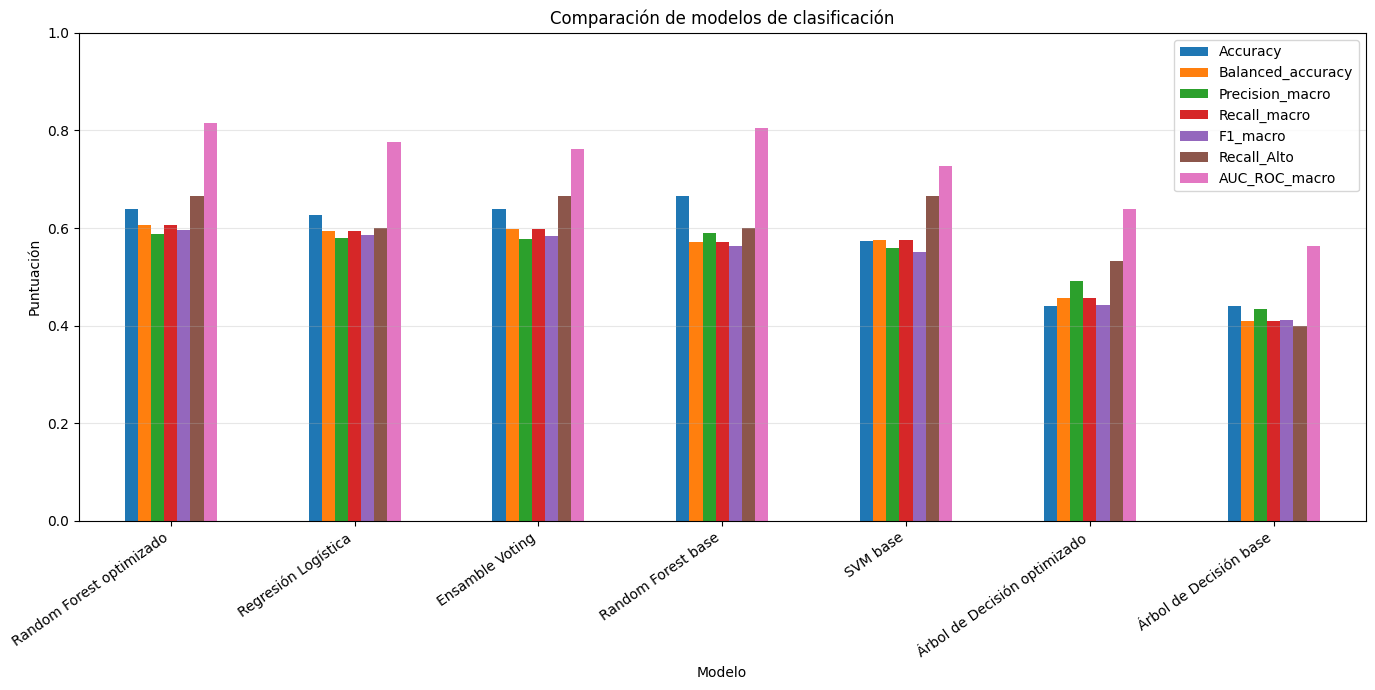

In [59]:
# ------------------------------------------------------------
# Propósito: Visualizar de forma resumida el desempeño de los modelos.
# Entradas principales: Tabla comparativa de métricas.
# Proceso resumido: Grafica métricas principales como F1 macro, balanced accuracy, ROC-
# AUC y recall de Alto.
# Salidas esperadas: grafico_comparacion_modelos.png.
# ------------------------------------------------------------

# ============================================================
# 13. Gráfico comparativo de métricas
# ============================================================

tabla_grafico_modelos = tabla_resultados_modelos.set_index(
    "Modelo"
)[
    [
        "Accuracy",
        "Balanced_accuracy",
        "Precision_macro",
        "Recall_macro",
        "F1_macro",
        "Recall_Alto",
        "AUC_ROC_macro"
    ]
]

tabla_grafico_modelos.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Comparación de modelos de clasificación"
)
plt.xlabel("Modelo")
plt.ylabel("Puntuación")
plt.ylim(0, 1)
plt.xticks(
    rotation=35,
    ha="right"
)
plt.grid(
    axis="y",
    alpha=0.3
)
plt.tight_layout()
plt.savefig(
    "comparacion_modelos_inundacion.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()


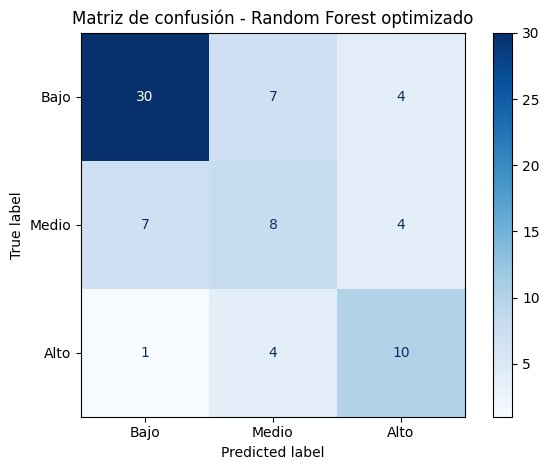

              precision    recall  f1-score   support

        Bajo       0.79      0.73      0.76        41
       Medio       0.42      0.42      0.42        19
        Alto       0.56      0.67      0.61        15

    accuracy                           0.64        75
   macro avg       0.59      0.61      0.60        75
weighted avg       0.65      0.64      0.64        75



In [60]:
# ------------------------------------------------------------
# Propósito: Analizar los aciertos y errores por clase del modelo seleccionado.
# Entradas principales: y_test y predicciones del mejor modelo.
# Proceso resumido: Calcula y grafica la matriz de confusión con etiquetas Bajo, Medio y
# Alto.
# Salidas esperadas: matriz_confusion_mejor_modelo.png.
# ------------------------------------------------------------

# ============================================================
# 14. Matriz de confusión del mejor modelo
# ============================================================

matriz_confusion = confusion_matrix(
    y_test_modelo,
    mejor_pred_test,
    labels=CLASES_NUMERICAS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=NOMBRES_CLASES
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    f"Matriz de confusión - {mejor_nombre_modelo}"
)
plt.tight_layout()
plt.savefig(
    "matriz_confusion_mejor_modelo.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

print(
    classification_report(
        y_test_modelo,
        mejor_pred_test,
        labels=CLASES_NUMERICAS,
        target_names=NOMBRES_CLASES,
        zero_division=0
    )
)


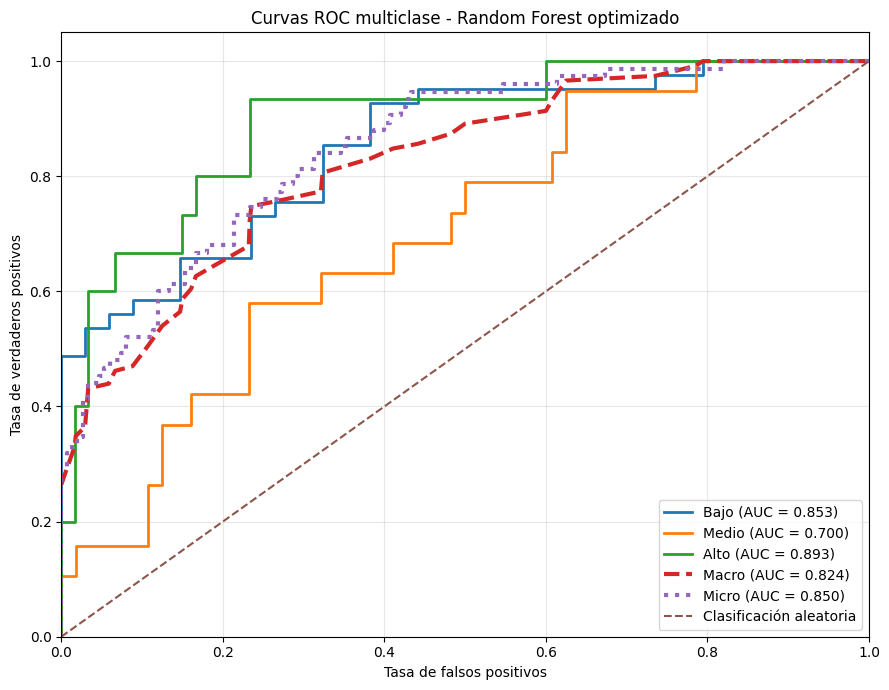

,clase,auc
0,Bajo,0.8529
1,Medio,0.7002
2,Alto,0.8933


In [61]:
# ------------------------------------------------------------
# Propósito: Evaluar la capacidad discriminante del mejor modelo para cada clase.
# Entradas principales: Probabilidades predichas y etiquetas reales del conjunto de prueba.
# Proceso resumido: Binariza clases, calcula ROC-AUC One-vs-Rest y grafica curvas para
# Bajo, Medio y Alto.
# Salidas esperadas: curvas_roc_mejor_modelo.png y auc_por_clase_mejor_modelo.csv.
# ------------------------------------------------------------

# ============================================================
# 15. Curvas ROC multiclase del mejor modelo
# ============================================================

y_test_binarizado = label_binarize(
    y_test_modelo,
    classes=CLASES_NUMERICAS
)

fpr = {}
tpr = {}
roc_auc_clase = {}

for indice_clase, nombre_clase in enumerate(NOMBRES_CLASES):
    fpr[indice_clase], tpr[indice_clase], _ = roc_curve(
        y_test_binarizado[:, indice_clase],
        mejor_proba_test[:, indice_clase]
    )

    roc_auc_clase[indice_clase] = auc(
        fpr[indice_clase],
        tpr[indice_clase]
    )

fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_binarizado.ravel(),
    mejor_proba_test.ravel()
)

roc_auc_clase["micro"] = auc(
    fpr["micro"],
    tpr["micro"]
)

todos_fpr = np.unique(
    np.concatenate([
        fpr[indice_clase]
        for indice_clase in range(
            len(CLASES_NUMERICAS)
        )
    ])
)

media_tpr = np.zeros_like(
    todos_fpr
)

for indice_clase in range(
    len(CLASES_NUMERICAS)
):
    media_tpr += np.interp(
        todos_fpr,
        fpr[indice_clase],
        tpr[indice_clase]
    )

media_tpr /= len(CLASES_NUMERICAS)

fpr["macro"] = todos_fpr
tpr["macro"] = media_tpr

roc_auc_clase["macro"] = auc(
    fpr["macro"],
    tpr["macro"]
)

plt.figure(
    figsize=(9, 7)
)

for indice_clase, nombre_clase in enumerate(NOMBRES_CLASES):
    plt.plot(
        fpr[indice_clase],
        tpr[indice_clase],
        linewidth=2,
        label=f"{nombre_clase} (AUC = {roc_auc_clase[indice_clase]:.3f})"
    )

plt.plot(
    fpr["macro"],
    tpr["macro"],
    linestyle="--",
    linewidth=3,
    label=f"Macro (AUC = {roc_auc_clase['macro']:.3f})"
)

plt.plot(
    fpr["micro"],
    tpr["micro"],
    linestyle=":",
    linewidth=3,
    label=f"Micro (AUC = {roc_auc_clase['micro']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.title(
    f"Curvas ROC multiclase - {mejor_nombre_modelo}"
)
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.legend(
    loc="lower right"
)
plt.grid(
    alpha=0.3
)
plt.tight_layout()
plt.savefig(
    "curvas_roc_mejor_modelo.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

tabla_auc_clases = pd.DataFrame({
    "clase": NOMBRES_CLASES,
    "auc": [
        roc_auc_clase[0],
        roc_auc_clase[1],
        roc_auc_clase[2]
    ]
})

tabla_auc_clases["auc"] = (
    tabla_auc_clases["auc"]
    .round(4)
)

display(tabla_auc_clases)

tabla_auc_clases.to_csv(
    MODELADO_SALIDAS["auc_clases"],
    index=False,
    encoding="utf-8-sig"
)


,variable,importancia
10,densidad_poblacional_hab_km2,0.1755
9,num_elementos_hidricos_intersectan,0.1636
3,altitud_media,0.0778
5,pendiente_media,0.0699
12,porcentaje_bosque,0.0695
13,porcentaje_agricultura_pasto,0.0639
4,rango_altitudinal,0.0603
8,porcentaje_area_cerca_rio_1km,0.0576
7,distancia_centroide_rio_km,0.0536
0,precipitacion_media_anual,0.0504


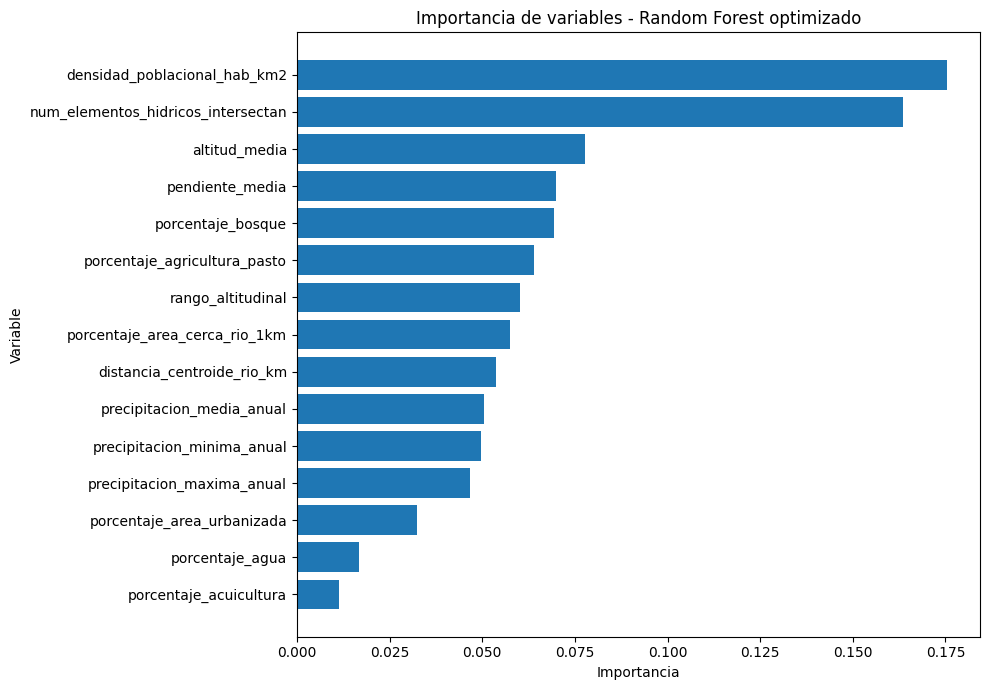

Importancias guardadas en: importancia_variables_inundacion.csv


In [62]:
# ------------------------------------------------------------
# Propósito: Interpretar qué predictores aportan más al modelo seleccionado.
# Entradas principales: Mejor modelo entrenado y nombres de variables.
# Proceso resumido: Extrae feature_importances_ o coeficientes cuando el estimador los
# permite y ordena variables por importancia.
# Salidas esperadas: importancia_variables_inundacion.csv y
# grafico_importancia_variables.png cuando aplica.
# ------------------------------------------------------------

# ============================================================
# 16. Importancia de variables
# ============================================================

def extraer_importancias_desde_pipeline(modelo, variables):
    """Extrae importancias si el clasificador final las posee."""
    try:
        clasificador = modelo.named_steps[
            "clasificador"
        ]

        if hasattr(
            clasificador,
            "feature_importances_"
        ):
            return pd.DataFrame({
                "variable": variables,
                "importancia": clasificador.feature_importances_
            }).sort_values(
                "importancia",
                ascending=False
            )

    except Exception:
        pass

    return None


importancias = extraer_importancias_desde_pipeline(
    mejor_modelo_evaluado,
    variables_modelo
)

fuente_importancia = mejor_nombre_modelo

if importancias is None:
    importancias = extraer_importancias_desde_pipeline(
        modelos_entrenados["Random Forest optimizado"],
        variables_modelo
    )
    fuente_importancia = "Random Forest optimizado"

if importancias is None:
    importancias = pd.DataFrame(
        {
            "variable": variables_modelo,
            "importancia": np.nan
        }
    )

display(importancias)

importancias.to_csv(
    MODELADO_SALIDAS["importancias"],
    index=False,
    encoding="utf-8-sig"
)

if importancias["importancia"].notna().any():
    plt.figure(
        figsize=(10, 7)
    )

    top_importancias = importancias.head(15)

    plt.barh(
        top_importancias["variable"][::-1],
        top_importancias["importancia"][::-1]
    )

    plt.title(
        f"Importancia de variables - {fuente_importancia}"
    )
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.savefig(
        "importancia_variables_inundacion.png",
        dpi=160,
        bbox_inches="tight"
    )
    plt.show()

print("Importancias guardadas en:", MODELADO_SALIDAS["importancias"])


In [63]:
# ------------------------------------------------------------
# Propósito: Guardar predicciones y probabilidades del test para análisis posterior.
# Entradas principales: Identificadores del conjunto de prueba, y_test y probabilidades
# del mejor modelo.
# Proceso resumido: Construye una tabla con riesgo real, riesgo predicho, probabilidades
# por clase y confianza.
# Salidas esperadas: predicciones_conjunto_prueba.csv.
# ------------------------------------------------------------

# ============================================================
# 17. Predicciones del conjunto de prueba
# ============================================================

predicciones_test = identificadores_test.copy()

predicciones_test["riesgo_real"] = [
    DECODIFICACION_RIESGO[int(valor)]
    for valor in y_test_modelo
]

predicciones_test["riesgo_predicho"] = [
    DECODIFICACION_RIESGO[int(valor)]
    for valor in mejor_pred_test
]

predicciones_test["prediccion_correcta"] = (
    predicciones_test["riesgo_real"]
    == predicciones_test["riesgo_predicho"]
)

predicciones_test["probabilidad_bajo"] = mejor_proba_test[:, 0]
predicciones_test["probabilidad_medio"] = mejor_proba_test[:, 1]
predicciones_test["probabilidad_alto"] = mejor_proba_test[:, 2]
predicciones_test["confianza_prediccion"] = (
    mejor_proba_test.max(axis=1)
)

for columna in [
    "probabilidad_bajo",
    "probabilidad_medio",
    "probabilidad_alto",
    "confianza_prediccion"
]:
    predicciones_test[columna] = (
        predicciones_test[columna]
        .round(4)
    )

display(predicciones_test.head())

predicciones_test.to_csv(
    MODELADO_SALIDAS["predicciones_test"],
    index=False,
    encoding="utf-8-sig"
)

print(
    "Archivo generado:",
    MODELADO_SALIDAS["predicciones_test"]
)


,codigo_parroquia,codigo_provincia,provincia_modelo,riesgo_real,riesgo_predicho,prediccion_correcta,probabilidad_bajo,probabilidad_medio,probabilidad_alto,confianza_prediccion
0,070152,07,EL ORO,Medio,Bajo,False,0.5323,0.2850,0.1827,0.5323
1,070254,07,EL ORO,Bajo,Bajo,True,0.5125,0.3586,0.1289,0.5125
2,070256,07,EL ORO,Bajo,Bajo,True,0.4843,0.3728,0.1429,0.4843
3,070350,07,EL ORO,Bajo,Bajo,True,0.8505,0.1266,0.0229,0.8505
4,070353,07,EL ORO,Bajo,Bajo,True,0.5895,0.3353,0.0752,0.5895


Archivo generado: predicciones_conjunto_prueba.csv


# ETAPA 7. Predicción final para todas las parroquias

Después de seleccionar el mejor modelo con el conjunto de prueba, se clona y se reentrena usando el dataset completo.  
Las métricas oficiales continúan siendo las de la etapa 6; el reentrenamiento final se usa para producir predicciones cartográficas para todas las parroquias.


In [64]:
# ------------------------------------------------------------
# Propósito: Ajustar el mejor modelo usando todo el dataset disponible antes de predecir
# el mapa final.
# Entradas principales: df_limpio_modelo completo y mejor modelo seleccionado.
# Proceso resumido: Clona el pipeline ganador y lo entrena con todas las parroquias
# etiquetadas.
# Salidas esperadas: modelo_final entrenado para predecir todas las parroquias.
# ------------------------------------------------------------

# ============================================================
# 18. Reentrenamiento final con todas las parroquias
# ============================================================

modelo_final = clone(
    modelos_comparacion[
        mejor_nombre_modelo
    ]
)

inicio = time.time()
modelo_final.fit(
    X_total_modelo,
    y_total_modelo
)
tiempo_reentrenamiento_final = time.time() - inicio

predicciones_total = modelo_final.predict(
    X_total_modelo
)

probabilidades_total = obtener_probabilidades_ordenadas(
    modelo_final,
    X_total_modelo
)

print("Modelo final reentrenado:", mejor_nombre_modelo)
print(
    "Tiempo de reentrenamiento:",
    round(tiempo_reentrenamiento_final, 2),
    "segundos"
)


Modelo final reentrenado: Random Forest optimizado
Tiempo de reentrenamiento: 0.66 segundos


In [65]:
# ------------------------------------------------------------
# Propósito: Generar las predicciones finales que alimentarán la aplicación web y el mapa.
# Entradas principales: modelo_final, X_total e identificadores de todas las parroquias.
# Proceso resumido: Predice clase y probabilidades para cada parroquia y calcula
# confianza de la predicción.
# Salidas esperadas: predicciones_todas_parroquias.csv.
# ------------------------------------------------------------

# ============================================================
# 19. Archivo de predicciones para todas las parroquias
# ============================================================

predicciones_todas = identificadores_total.copy()

predicciones_todas["riesgo_real"] = dataset_modelo[
    OBJETIVO
].values

predicciones_todas["riesgo_predicho"] = [
    DECODIFICACION_RIESGO[int(valor)]
    for valor in predicciones_total
]

predicciones_todas["prediccion_correcta"] = (
    predicciones_todas["riesgo_real"]
    == predicciones_todas["riesgo_predicho"]
)

predicciones_todas["probabilidad_bajo"] = probabilidades_total[:, 0]
predicciones_todas["probabilidad_medio"] = probabilidades_total[:, 1]
predicciones_todas["probabilidad_alto"] = probabilidades_total[:, 2]
predicciones_todas["confianza_prediccion"] = (
    probabilidades_total.max(axis=1)
)

for columna in [
    "probabilidad_bajo",
    "probabilidad_medio",
    "probabilidad_alto",
    "confianza_prediccion"
]:
    predicciones_todas[columna] = (
        predicciones_todas[columna]
        .round(4)
    )

predicciones_todas = predicciones_todas.sort_values(
    "codigo_parroquia"
).reset_index(drop=True)

display(predicciones_todas.head())

predicciones_todas.to_csv(
    MODELADO_SALIDAS["predicciones_todas"],
    index=False,
    encoding="utf-8-sig"
)

print(
    "Predicciones para todas las parroquias:",
    predicciones_todas.shape
)

print(
    "Archivo generado:",
    MODELADO_SALIDAS["predicciones_todas"]
)


,codigo_parroquia,codigo_provincia,provincia_modelo,riesgo_real,riesgo_predicho,prediccion_correcta,probabilidad_bajo,probabilidad_medio,probabilidad_alto,confianza_prediccion
0,070150,07,EL ORO,Alto,Alto,True,0.0758,0.2035,0.7207,0.7207
1,070152,07,EL ORO,Medio,Medio,True,0.2881,0.5720,0.1399,0.5720
2,070250,07,EL ORO,Alto,Alto,True,0.1384,0.2941,0.5675,0.5675
3,070251,07,EL ORO,Bajo,Bajo,True,0.4351,0.3789,0.1859,0.4351
4,070254,07,EL ORO,Bajo,Bajo,True,0.5324,0.3215,0.1460,0.5324


Predicciones para todas las parroquias: (300, 10)
Archivo generado: predicciones_todas_parroquias.csv


In [66]:
# ------------------------------------------------------------
# Propósito: Guardar el modelo entrenado y la información necesaria para reproducir
# predicciones.
# Entradas principales: modelo_final, columnas de entrada, clases, métricas y
# comparación de modelos.
# Proceso resumido: Exporta archivos joblib y JSON con configuración, métricas, clases y
# columnas.
# Salidas esperadas: mejor_modelo_riesgo_inundacion.joblib,
# modelo_riesgo_inundacion.joblib, columnas_modelo.json, clases_modelo.json y
# metricas_modelo.json.
# ------------------------------------------------------------

# ============================================================
# 20. Exportación del modelo final y metadatos
# ============================================================

joblib.dump(
    modelo_final,
    MODELADO_SALIDAS["modelo"]
)

# Nombre adicional compatible con el notebook antiguo de aplicación web.
joblib.dump(
    modelo_final,
    MODELADO_SALIDAS["modelo_legacy"]
)

with open(
    MODELADO_SALIDAS["columnas"],
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(
        variables_modelo,
        archivo,
        ensure_ascii=False,
        indent=4
    )

with open(
    MODELADO_SALIDAS["clases"],
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(
        {
            "codificacion": CODIFICACION_RIESGO,
            "decodificacion": {
                str(clave): valor
                for clave, valor
                in DECODIFICACION_RIESGO.items()
            },
            "orden_probabilidades": NOMBRES_CLASES
        },
        archivo,
        ensure_ascii=False,
        indent=4
    )

mejor_fila_metricas = (
    tabla_resultados_modelos
    .iloc[0]
    .to_dict()
)

metricas_limpias = {}

for clave, valor in mejor_fila_metricas.items():
    if isinstance(valor, (np.integer, int)):
        metricas_limpias[clave] = int(valor)
    elif isinstance(valor, (np.floating, float)):
        metricas_limpias[clave] = (
            None
            if pd.isna(valor)
            else float(valor)
        )
    else:
        metricas_limpias[clave] = valor

metricas_modelo = {
    "modelo_seleccionado": mejor_nombre_modelo,
    "criterio_seleccion": "F1_macro, Recall_Alto y AUC_ROC_macro",
    "metricas_conjunto_prueba": metricas_limpias,
    "auc_por_clase": {
        fila["clase"]: float(fila["auc"])
        for _, fila in tabla_auc_clases.iterrows()
    },
    "numero_parroquias_total": int(len(dataset_modelo)),
    "numero_registros_train": int(len(dataset_train_modelo)),
    "numero_registros_test": int(len(dataset_test_modelo)),
    "numero_variables_predictoras": int(len(variables_modelo)),
    "variables_predictoras": variables_modelo,
    "columnas_excluidas_por_fuga": COLUMNAS_FUGA_MODELO,
    "tiempo_reentrenamiento_final_segundos": round(
        float(tiempo_reentrenamiento_final),
        4
    ),
    "version_python": sys.version.split()[0],
    "version_scikit_learn": sklearn.__version__,
    "version_pandas": pd.__version__,
    "version_numpy": np.__version__
}

with open(
    MODELADO_SALIDAS["metricas"],
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(
        metricas_modelo,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print("Modelo y metadatos exportados:")
print("-", MODELADO_SALIDAS["modelo"])
print("-", MODELADO_SALIDAS["modelo_legacy"])
print("-", MODELADO_SALIDAS["columnas"])
print("-", MODELADO_SALIDAS["clases"])
print("-", MODELADO_SALIDAS["metricas"])


Modelo y metadatos exportados:
- mejor_modelo_riesgo_inundacion.joblib
- modelo_riesgo_inundacion.joblib
- columnas_modelo.json
- clases_modelo.json
- metricas_modelo.json


# ETAPA 8. Integración geográfica para el mapa

Esta etapa une las predicciones finales con la capa de límites parroquiales usando `codigo_parroquia`.  
El producto principal es:

```text
parroquias_riesgo.geojson
```

Ese GeoJSON será la base para la aplicación web con Flask, Folium o Leaflet.


In [67]:
# ------------------------------------------------------------
# Propósito: Recuperar la geometría parroquial para unirla con las predicciones finales.
# Entradas principales: limites_parroquiales.geojson y predicciones_todas_parroquias.csv.
# Proceso resumido: Lee la capa, normaliza códigos/columnas y filtra las provincias del
# modelo.
# Salidas esperadas: GeoDataFrame de parroquias listo para unión cartográfica.
# ------------------------------------------------------------

# ============================================================
# 21. Cargar límites parroquiales para integración cartográfica
# ============================================================

if "archivo_limites" in globals():
    ruta_limites_mapa = Path(
        archivo_limites
    )
else:
    ruta_limites_mapa = Path(
        "limites_parroquiales.geojson"
    )

if not ruta_limites_mapa.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo de límites: {ruta_limites_mapa}"
    )

parroquias_mapa = gpd.read_file(
    ruta_limites_mapa
)

parroquias_mapa.columns = [
    normalizar_nombre_columna(c)
    for c in parroquias_mapa.columns
]

candidatos_codigo_mapa = [
    "codigo_parroquia",
    "cod_parroquia",
    "dpa_parroq",
    "dpa_parroquia",
    "parroquia"
]

columna_codigo_mapa = next(
    (
        columna
        for columna in candidatos_codigo_mapa
        if columna in parroquias_mapa.columns
    ),
    None
)

if columna_codigo_mapa is None:
    raise KeyError(
        "No se encontró una columna de código parroquial "
        "en el GeoJSON de límites."
    )

parroquias_mapa["codigo_parroquia"] = normalizar_codigo(
    parroquias_mapa[columna_codigo_mapa],
    longitud=6
)

parroquias_mapa["codigo_provincia"] = (
    parroquias_mapa["codigo_parroquia"]
    .str[:2]
)

parroquias_mapa = parroquias_mapa[
    parroquias_mapa["codigo_provincia"].isin(
        PROVINCIAS_MODELO
    )
].copy()

provincias_mapa_faltantes = sorted(
    set(PROVINCIAS_MODELO.keys())
    - set(parroquias_mapa["codigo_provincia"].dropna().unique())
)

if provincias_mapa_faltantes:
    raise ValueError(
        "La capa de límites usada para el mapa no contiene todas "
        f"las provincias del modelo: {provincias_mapa_faltantes}."
    )

if parroquias_mapa.crs is None:
    raise ValueError(
        "La capa de límites no tiene CRS definido."
    )

parroquias_mapa = parroquias_mapa.to_crs(
    "EPSG:4326"
)

print("Parroquias en capa geográfica:", len(parroquias_mapa))
print("Provincias para mapa:", sorted(parroquias_mapa["codigo_provincia"].unique()))
print("CRS:", parroquias_mapa.crs)


Parroquias en capa geográfica: 300
Provincias para mapa: ['07', '08', '09', '12', '13', '24']
CRS: EPSG:4326


In [68]:
# ------------------------------------------------------------
# Propósito: Construir la capa geográfica final de riesgo predicho.
# Entradas principales: GeoDataFrame parroquial y predicciones finales.
# Proceso resumido: Une por codigo_parroquia, valida coincidencias, agrega
# colores/leyendas y prepara atributos del mapa.
# Salidas esperadas: GeoDataFrame parroquias_riesgo para exportación y visualización.
# ------------------------------------------------------------

# ============================================================
# 22. Unión de predicciones con geometría
# ============================================================

columnas_prediccion_mapa = [
    "codigo_parroquia",
    "riesgo_real",
    "riesgo_predicho",
    "prediccion_correcta",
    "probabilidad_bajo",
    "probabilidad_medio",
    "probabilidad_alto",
    "confianza_prediccion"
]

columnas_descriptivas = [
    "provincia_modelo",
    "provincia",
    "canton",
    "parroquia"
]

for columna in columnas_descriptivas:
    if (
        columna in predicciones_todas.columns
        and columna not in columnas_prediccion_mapa
    ):
        columnas_prediccion_mapa.insert(
            1,
            columna
        )

predicciones_mapa = predicciones_todas[
    [
        columna
        for columna in columnas_prediccion_mapa
        if columna in predicciones_todas.columns
    ]
].copy()

predicciones_mapa["codigo_parroquia"] = (
    predicciones_mapa["codigo_parroquia"]
    .astype("string")
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
    .str.zfill(6)
)

if predicciones_mapa["codigo_parroquia"].duplicated().any():
    raise ValueError(
        "Existen códigos duplicados en las predicciones finales."
    )

parroquias_riesgo = parroquias_mapa.merge(
    predicciones_mapa,
    on="codigo_parroquia",
    how="left",
    suffixes=("", "_pred")
)

sin_prediccion = int(
    parroquias_riesgo["riesgo_predicho"]
    .isna()
    .sum()
)

print(
    "Parroquias sin predicción después de la unión:",
    sin_prediccion
)

if sin_prediccion > 0:
    display(
        parroquias_riesgo.loc[
            parroquias_riesgo["riesgo_predicho"].isna(),
            ["codigo_parroquia"]
        ].head(20)
    )

# Reforzar nombres territoriales si existen duplicados con sufijo.
for columna in [
    "provincia",
    "canton",
    "parroquia",
    "provincia_modelo"
]:
    columna_pred = f"{columna}_pred"

    if columna_pred in parroquias_riesgo.columns:
        if columna in parroquias_riesgo.columns:
            parroquias_riesgo[columna] = (
                parroquias_riesgo[columna]
                .fillna(parroquias_riesgo[columna_pred])
            )
        else:
            parroquias_riesgo[columna] = (
                parroquias_riesgo[columna_pred]
            )

        parroquias_riesgo = parroquias_riesgo.drop(
            columns=[columna_pred]
        )

parroquias_riesgo[
    "riesgo_predicho"
] = parroquias_riesgo[
    "riesgo_predicho"
].fillna("Sin información")

parroquias_riesgo[
    "confianza_prediccion"
] = pd.to_numeric(
    parroquias_riesgo[
        "confianza_prediccion"
    ],
    errors="coerce"
)

print("GeoDataFrame final:", parroquias_riesgo.shape)
display(
    parroquias_riesgo.drop(
        columns="geometry"
    ).head()
)


Parroquias sin predicción después de la unión: 0
GeoDataFrame final: (300, 19)


,codigo_parroquia,fcode,sector,parroquia,anio,fuente,sec18,sec,lamina,codigo_provincia,provincia_modelo,riesgo_real,riesgo_predicho,prediccion_correcta,probabilidad_bajo,probabilidad_medio,probabilidad_alto,confianza_prediccion
0,070150,BB002,070150002011,070150,2020,CPV2020,070150002011,070150003006,None,07,EL ORO,Alto,Alto,True,0.0758,0.2035,0.7207,0.7207
1,070152,BB002,070152001003,070152,2020,CPV2020,070152001003,070152001003,None,07,EL ORO,Medio,Medio,True,0.2881,0.5720,0.1399,0.5720
2,070250,BB002,070250001004,070250,2022,CPV2022,070250001003,070250001004,None,07,EL ORO,Alto,Alto,True,0.1384,0.2941,0.5675,0.5675
3,070251,BB002,070251999002,070251,2020,CPV2020,070251999002,070251999003,None,07,EL ORO,Bajo,Bajo,True,0.4351,0.3789,0.1859,0.4351
4,070254,BB002,070254999009,070254,2020,CPV2020,070254999009,070254999009,None,07,EL ORO,Bajo,Bajo,True,0.5324,0.3215,0.1460,0.5324


In [69]:
# ------------------------------------------------------------
# Propósito: Guardar la capa final geográfica en formatos utilizables por Flask/Folium y
# SIG.
# Entradas principales: GeoDataFrame parroquias_riesgo.
# Proceso resumido: Exporta a GeoJSON para web y GPKG como respaldo geoespacial.
# Salidas esperadas: parroquias_riesgo.geojson y parroquias_riesgo.gpkg.
# ------------------------------------------------------------

# ============================================================
# 23. Exportar GeoJSON y GeoPackage para mapa
# ============================================================

# Conservar geometrías válidas.
parroquias_riesgo = parroquias_riesgo[
    parroquias_riesgo.geometry.notna()
    & ~parroquias_riesgo.geometry.is_empty
].copy()

parroquias_riesgo["geometry"] = (
    parroquias_riesgo.geometry.apply(
        make_valid
    )
)

parroquias_riesgo.to_file(
    MODELADO_SALIDAS["geojson_mapa"],
    driver="GeoJSON"
)

parroquias_riesgo.to_file(
    MODELADO_SALIDAS["gpkg_mapa"],
    layer="parroquias_riesgo",
    driver="GPKG"
)

print("Archivos geográficos generados:")
print("-", MODELADO_SALIDAS["geojson_mapa"])
print("-", MODELADO_SALIDAS["gpkg_mapa"])


Archivos geográficos generados:
- parroquias_riesgo.geojson
- parroquias_riesgo.gpkg


In [70]:
# ------------------------------------------------------------
# Propósito: Crear un mapa interactivo preliminar para revisar la representación
# espacial del riesgo.
# Entradas principales: parroquias_riesgo con geometría, colores y atributos de predicción.
# Proceso resumido: Construye un mapa Folium con polígonos coloreados, tooltip, popup y
# leyenda.
# Salidas esperadas: mapa_riesgo_inundacion_folium.html.
# ------------------------------------------------------------

# ============================================================
# 24. Mapa Folium preliminar para validación
# ============================================================

try:
    import folium

    colores_riesgo = {
        "Bajo": "#2ca25f",
        "Medio": "#fdae6b",
        "Alto": "#de2d26",
        "Sin información": "#bdbdbd"
    }

    def estilo_riesgo(feature):
        riesgo = (
            feature.get("properties", {})
            .get("riesgo_predicho", "Sin información")
        )

        return {
            "fillColor": colores_riesgo.get(
                riesgo,
                colores_riesgo["Sin información"]
            ),
            "color": "#4d4d4d",
            "weight": 0.6,
            "fillOpacity": 0.65
        }

    mapa_validacion = folium.Map(
        location=[-1.7, -79.5],
        zoom_start=7,
        tiles="CartoDB positron"
    )

    campos_tooltip = [
        campo
        for campo in [
            "parroquia",
            "canton",
            "provincia",
            "provincia_modelo",
            "riesgo_predicho"
        ]
        if campo in parroquias_riesgo.columns
    ]

    aliases_tooltip = [
        f"{campo.replace('_', ' ').title()}:"
        for campo in campos_tooltip
    ]

    campos_popup = [
        campo
        for campo in [
            "riesgo_real",
            "riesgo_predicho",
            "confianza_prediccion",
            "probabilidad_bajo",
            "probabilidad_medio",
            "probabilidad_alto"
        ]
        if campo in parroquias_riesgo.columns
    ]

    aliases_popup = [
        f"{campo.replace('_', ' ').title()}:"
        for campo in campos_popup
    ]

    folium.GeoJson(
        parroquias_riesgo,
        name="Riesgo de inundación",
        style_function=estilo_riesgo,
        highlight_function=lambda feature: {
            "weight": 3,
            "color": "#000000",
            "fillOpacity": 0.8
        },
        tooltip=folium.GeoJsonTooltip(
            fields=campos_tooltip,
            aliases=aliases_tooltip,
            localize=True,
            sticky=False
        ),
        popup=folium.GeoJsonPopup(
            fields=campos_popup,
            aliases=aliases_popup,
            localize=True
        )
    ).add_to(mapa_validacion)

    leyenda = """
    <div style="position: fixed; bottom: 40px; left: 40px; z-index: 9999;
                background: white; border: 2px solid #777; border-radius: 6px;
                padding: 12px; font-size: 14px;
                box-shadow: 0 1px 5px rgba(0,0,0,0.35);">
        <strong>Riesgo de inundación</strong><br>
        <span style="color:#2ca25f;">■</span> Bajo<br>
        <span style="color:#fdae6b;">■</span> Medio<br>
        <span style="color:#de2d26;">■</span> Alto<br>
        <span style="color:#bdbdbd;">■</span> Sin información
    </div>
    """

    mapa_validacion.get_root().html.add_child(
        folium.Element(leyenda)
    )

    folium.LayerControl().add_to(
        mapa_validacion
    )

    mapa_validacion.save(
        MODELADO_SALIDAS["html_mapa"]
    )

    print(
        "Mapa preliminar generado:",
        MODELADO_SALIDAS["html_mapa"]
    )

except Exception as error:
    print(
        "No se pudo generar el mapa Folium preliminar."
    )
    print(error)


Mapa preliminar generado: mapa_riesgo_inundacion_folium.html


In [71]:
# ------------------------------------------------------------
# Propósito: Comprimir todos los resultados finales del proyecto técnico.
# Entradas principales: Datasets, reportes, gráficos, modelo, predicciones, mapa y
# archivos geográficos generados.
# Proceso resumido: Agrega al ZIP todos los archivos existentes definidos como productos
# de las ocho etapas.
# Salidas esperadas: proyecto_inundacion_8_etapas_resultados.zip.
# ------------------------------------------------------------

# ============================================================
# 25. Empaquetado final de las ocho etapas
# ============================================================

archivos_etapas_4_8 = [
    MODELADO_SALIDAS["comparacion"],
    MODELADO_SALIDAS["classification_reports"],
    MODELADO_SALIDAS["auc_clases"],
    MODELADO_SALIDAS["predicciones_test"],
    MODELADO_SALIDAS["importancias"],
    MODELADO_SALIDAS["modelo"],
    MODELADO_SALIDAS["modelo_legacy"],
    MODELADO_SALIDAS["columnas"],
    MODELADO_SALIDAS["clases"],
    MODELADO_SALIDAS["metricas"],
    MODELADO_SALIDAS["predicciones_todas"],
    MODELADO_SALIDAS["geojson_mapa"],
    MODELADO_SALIDAS["gpkg_mapa"],
    MODELADO_SALIDAS["html_mapa"],
    "comparacion_modelos_inundacion.png",
    "matriz_confusion_mejor_modelo.png",
    "curvas_roc_mejor_modelo.png",
    "importancia_variables_inundacion.png"
]

archivos_base_resultado = globals().get(
    "archivos_resultado",
    []
)

archivos_paquete_8_etapas = []

for archivo in (
    archivos_base_resultado
    + archivos_etapas_4_8
):
    if archivo not in archivos_paquete_8_etapas:
        archivos_paquete_8_etapas.append(
            archivo
        )

ruta_paquete_8 = Path(
    MODELADO_SALIDAS["paquete_final"]
)

with zipfile.ZipFile(
    ruta_paquete_8,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as archivo_zip:

    for archivo in archivos_paquete_8_etapas:
        ruta = Path(archivo)

        if ruta.exists():
            archivo_zip.write(
                ruta,
                arcname=ruta.name
            )

print(
    "Paquete final generado:",
    ruta_paquete_8
)

print("\nArchivos incluidos:")
with zipfile.ZipFile(
    ruta_paquete_8,
    "r"
) as archivo_zip:
    for nombre in archivo_zip.namelist():
        print("-", nombre)


Paquete final generado: proyecto_inundacion_8_etapas_resultados.zip

Archivos incluidos:
- catalogo_parroquias_modelo.csv
- precipitacion_historica_parroquias_inamhi.csv
- rios_esteros_cuerpos_agua_ecuador_osm_limpio.csv
- distancia_rios_parroquias.csv
- densidad_poblacional_parroquias_modelo_costa.csv
- uso_suelo_parroquias_mapbiomas.csv
- dataset_predictoras_parroquias.csv
- reporte_calidad_dataset_predictoras.csv
- cobertura_fuentes_predictoras.csv
- riesgo_historico_inundacion_parroquias_2010_2020.csv
- eventos_inundacion_por_anio.csv
- altitud_pendiente_parroquias_copernicus.csv
- dataset_inundacion.csv
- umbrales_variable_objetivo.json
- reporte_integracion_fuentes.csv
- dataset_inundacion_limpio.csv
- dataset_inundacion_train.csv
- dataset_inundacion_test.csv
- reporte_valores_faltantes.csv
- reporte_valores_atipicos.csv
- reporte_correlaciones_altas.csv
- reporte_balance_clases.csv
- estadisticas_descriptivas.csv
- metadatos_eda.json
- grafico_balance_clases.png
- histogramas_v

In [72]:
# ------------------------------------------------------------
# Propósito: Permitir descargar desde Colab el paquete final con todos los resultados.
# Entradas principales: proyecto_inundacion_8_etapas_resultados.zip.
# Proceso resumido: Verifica existencia del ZIP y ejecuta files.download cuando se usa
# Google Colab.
# Salidas esperadas: Archivo ZIP descargable en el equipo del usuario.
# ------------------------------------------------------------

# ============================================================
# 26. Descarga del paquete final de ocho etapas
# ============================================================

try:
    from google.colab import files

    files.download(
        MODELADO_SALIDAS["paquete_final"]
    )

except Exception as error:
    print(
        "La descarga automática funciona cuando "
        "el cuaderno se ejecuta en Google Colab."
    )
    print(error)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ETAPA 9. Generación de la aplicación web Flask para PythonAnywhere

Esta etapa transforma los resultados finales del modelo y del mapa en una carpeta lista para despliegue web.  
El producto principal es:

```text
app_riesgo_inundacion_flask.zip
```

Este archivo ZIP contiene la aplicación Flask, las plantillas HTML, los estilos CSS, el JavaScript del mapa con Leaflet y los datos finales generados por el Colab.  
La app está pensada para visualizar las predicciones ya generadas en Colab, por lo que no requiere ejecutar nuevamente el modelo en PythonAnywhere.


In [73]:
# ------------------------------------------------------------
# Propósito: Crear la estructura base de la aplicación web Flask que será
# desplegada en PythonAnywhere.
# Entradas principales: Archivos finales generados en las etapas anteriores,
# especialmente predicciones_todas_parroquias.csv y parroquias_riesgo.geojson.
# Proceso resumido: Elimina versiones anteriores de la carpeta de la app, crea
# subcarpetas para datos, plantillas HTML, archivos estáticos y documentación.
# Salidas esperadas: Carpeta app_riesgo_inundacion_flask con estructura web inicial.
# ------------------------------------------------------------

# ============================================================
# 27. Crear estructura de carpetas para la app Flask
# ============================================================

APP_FLASK_DIR = Path(
    "app_riesgo_inundacion_flask"
)

APP_FLASK_ZIP = Path(
    "app_riesgo_inundacion_flask.zip"
)

if APP_FLASK_DIR.exists():
    shutil.rmtree(
        APP_FLASK_DIR
    )

for carpeta in [
    APP_FLASK_DIR,
    APP_FLASK_DIR / "templates",
    APP_FLASK_DIR / "static",
    APP_FLASK_DIR / "static" / "css",
    APP_FLASK_DIR / "static" / "js",
    APP_FLASK_DIR / "data",
    APP_FLASK_DIR / "modelo"
]:
    carpeta.mkdir(
        parents=True,
        exist_ok=True
    )

print("Estructura creada:")
for ruta in sorted(APP_FLASK_DIR.rglob("*")):
    if ruta.is_dir():
        print("-", ruta)


Estructura creada:
- app_riesgo_inundacion_flask/data
- app_riesgo_inundacion_flask/modelo
- app_riesgo_inundacion_flask/static
- app_riesgo_inundacion_flask/static/css
- app_riesgo_inundacion_flask/static/js
- app_riesgo_inundacion_flask/templates


In [74]:
# ------------------------------------------------------------
# Propósito: Copiar hacia la app los productos necesarios para consulta, tabla,
# métricas y mapa interactivo.
# Entradas principales: CSV de predicciones finales, dataset limpio, GeoJSON del mapa,
# métricas, importancias y comparaciones de modelos.
# Proceso resumido: Localiza los archivos generados por el Colab, los copia a la carpeta
# data/ y asigna nombres estandarizados que serán usados por Flask.
# Salidas esperadas: data/predicciones_finales.csv, data/parroquias_riesgo.geojson y
# archivos complementarios de resultados.
# ------------------------------------------------------------

# ============================================================
# 28. Copiar resultados del Colab a la carpeta data de la app
# ============================================================

def copiar_archivo_app(origen, destino, obligatorio=False):
    """Copia un archivo si existe y controla los faltantes obligatorios."""
    ruta_origen = Path(origen)
    ruta_destino = Path(destino)

    if ruta_origen.exists():
        shutil.copy2(
            ruta_origen,
            ruta_destino
        )
        print(f"Copiado: {ruta_origen} -> {ruta_destino}")
        return True

    if obligatorio:
        raise FileNotFoundError(
            f"No se encontró el archivo obligatorio: {ruta_origen}"
        )

    print(f"No encontrado, se omite: {ruta_origen}")
    return False


copiar_archivo_app(
    MODELADO_SALIDAS["predicciones_todas"],
    APP_FLASK_DIR / "data" / "predicciones_finales.csv",
    obligatorio=True
)

copiar_archivo_app(
    MODELADO_SALIDAS["geojson_mapa"],
    APP_FLASK_DIR / "data" / "parroquias_riesgo.geojson",
    obligatorio=True
)

archivos_datos_opcionales = [
    ("dataset_inundacion.csv", "dataset_inundacion.csv"),
    (ARCHIVO_DATASET_LIMPIO, "dataset_inundacion_limpio.csv"),
    (MODELADO_SALIDAS["metricas"], "metricas_modelo.json"),
    (MODELADO_SALIDAS["comparacion"], "comparacion_modelos_inundacion.csv"),
    (MODELADO_SALIDAS["importancias"], "importancia_variables_inundacion.csv"),
    ("reporte_balance_clases.csv", "reporte_balance_clases.csv"),
    (MODELADO_SALIDAS["classification_reports"], "classification_reports_modelos.json"),
    (MODELADO_SALIDAS["auc_clases"], "auc_por_clase_mejor_modelo.csv"),
    (MODELADO_SALIDAS["html_mapa"], "mapa_riesgo_inundacion_folium.html")
]

for origen, nombre_destino in archivos_datos_opcionales:
    copiar_archivo_app(
        origen,
        APP_FLASK_DIR / "data" / nombre_destino,
        obligatorio=False
    )

# El modelo se copia como respaldo documental, pero la app no lo carga en
# PythonAnywhere para evitar dependencias pesadas como scikit-learn, scipy y numpy.
archivos_modelo_opcionales = [
    (MODELADO_SALIDAS["modelo"], "mejor_modelo_riesgo_inundacion.joblib"),
    (MODELADO_SALIDAS["modelo_legacy"], "modelo_riesgo_inundacion.joblib.off"),
    (MODELADO_SALIDAS["columnas"], "columnas_modelo.json"),
    (MODELADO_SALIDAS["clases"], "clases_modelo.json"),
    (MODELADO_SALIDAS["metricas"], "metricas_modelo.json")
]

for origen, nombre_destino in archivos_modelo_opcionales:
    copiar_archivo_app(
        origen,
        APP_FLASK_DIR / "modelo" / nombre_destino,
        obligatorio=False
    )

print("\nArchivos principales listos para Flask:")
print("-", APP_FLASK_DIR / "data" / "predicciones_finales.csv")
print("-", APP_FLASK_DIR / "data" / "parroquias_riesgo.geojson")


Copiado: predicciones_todas_parroquias.csv -> app_riesgo_inundacion_flask/data/predicciones_finales.csv
Copiado: parroquias_riesgo.geojson -> app_riesgo_inundacion_flask/data/parroquias_riesgo.geojson
Copiado: dataset_inundacion.csv -> app_riesgo_inundacion_flask/data/dataset_inundacion.csv
Copiado: dataset_inundacion_limpio.csv -> app_riesgo_inundacion_flask/data/dataset_inundacion_limpio.csv
Copiado: metricas_modelo.json -> app_riesgo_inundacion_flask/data/metricas_modelo.json
Copiado: comparacion_modelos_inundacion.csv -> app_riesgo_inundacion_flask/data/comparacion_modelos_inundacion.csv
Copiado: importancia_variables_inundacion.csv -> app_riesgo_inundacion_flask/data/importancia_variables_inundacion.csv
Copiado: reporte_balance_clases.csv -> app_riesgo_inundacion_flask/data/reporte_balance_clases.csv
Copiado: classification_reports_modelos.json -> app_riesgo_inundacion_flask/data/classification_reports_modelos.json
Copiado: auc_por_clase_mejor_modelo.csv -> app_riesgo_inundacion_f

In [75]:
# ------------------------------------------------------------
# Propósito: Programar la aplicación principal en Flask.
# Entradas principales: predicciones_finales.csv, parroquias_riesgo.geojson y
# metricas_modelo.json.
# Proceso resumido: Define rutas web para inicio, consulta de parroquias y mapa;
# además, conserva rutas API internas para GeoJSON, predicciones y métricas.
# Salidas esperadas: Archivo app.py funcional y compatible con PythonAnywhere.
# ------------------------------------------------------------

# ============================================================
# 29. Crear app.py
# ============================================================

app_py = r"""
from flask import Flask, render_template, jsonify, request
from pathlib import Path
import csv
import json

app = Flask(__name__)

BASE_DIR = Path(__file__).resolve().parent
DATA_DIR = BASE_DIR / "data"

PREDICCIONES_CSV = DATA_DIR / "predicciones_finales.csv"
GEOJSON_FILE = DATA_DIR / "parroquias_riesgo.geojson"
METRICAS_FILE = DATA_DIR / "metricas_modelo.json"


def leer_csv_predicciones():
    datos = []

    if not PREDICCIONES_CSV.exists():
        return datos

    with PREDICCIONES_CSV.open(
        "r",
        encoding="utf-8-sig",
        newline=""
    ) as archivo:
        lector = csv.DictReader(archivo)

        for fila in lector:
            datos.append(
                {
                    clave: valor
                    for clave, valor in fila.items()
                }
            )

    return datos


def leer_metricas():
    if METRICAS_FILE.exists():
        with METRICAS_FILE.open(
            "r",
            encoding="utf-8"
        ) as archivo:
            return json.load(archivo)

    return {
        "modelo_seleccionado": "Random Forest optimizado",
        "criterio_seleccion": "F1 macro, recall de riesgo alto y AUC ROC macro",
        "metricas_conjunto_prueba": {}
    }


def obtener_valor(fila, *columnas):
    for columna in columnas:
        valor = fila.get(columna)

        if valor is not None and str(valor).strip() != "":
            return str(valor).strip()

    return ""


def convertir_float(valor):
    try:
        texto = str(valor).strip().replace(",", ".")
        if texto == "":
            return None
        return float(texto)
    except Exception:
        return None


def valor_riesgo(fila):
    return obtener_valor(
        fila,
        "riesgo_predicho",
        "riesgo",
        "riesgo_inundacion"
    ) or "Sin dato"


def construir_metricas_resumen(metricas):
    bloque = metricas.get(
        "metricas_conjunto_prueba",
        {}
    )

    return {
        "modelo": metricas.get(
            "modelo_seleccionado",
            "Random Forest optimizado"
        ),
        "accuracy": bloque.get(
            "Accuracy",
            metricas.get("accuracy")
        ),
        "f1_macro": bloque.get(
            "F1_macro",
            metricas.get("f1_macro")
        ),
        "auc_roc_macro": bloque.get(
            "AUC_ROC_macro",
            metricas.get("auc_roc_macro")
        ),
        "recall_alto": bloque.get(
            "Recall_Alto",
            metricas.get("recall_alto")
        )
    }


@app.template_filter("porcentaje")
def porcentaje(valor):
    numero = convertir_float(valor)

    if numero is None:
        return "Sin dato"

    if 0 <= numero <= 1:
        numero = numero * 100

    return f"{numero:.2f}%"


@app.template_filter("decimal")
def decimal(valor):
    numero = convertir_float(valor)

    if numero is None:
        return "Sin dato"

    return f"{numero:.4f}"


@app.route("/")
def index():
    datos = leer_csv_predicciones()
    metricas = leer_metricas()

    provincias = sorted(
        {
            obtener_valor(
                fila,
                "provincia",
                "provincia_modelo"
            )
            for fila in datos
            if obtener_valor(
                fila,
                "provincia",
                "provincia_modelo"
            )
        }
    )

    resumen_riesgo = {}

    for fila in datos:
        riesgo = valor_riesgo(fila)
        resumen_riesgo[riesgo] = resumen_riesgo.get(
            riesgo,
            0
        ) + 1

    estado_modelo = (
        "Predicciones generadas en Colab con Random Forest optimizado. "
        "La app visualiza el CSV final con parroquias, probabilidades y "
        "clasificación de riesgo."
    )

    return render_template(
        "index.html",
        total_parroquias=len(datos),
        total_provincias=len(provincias),
        resumen_riesgo=resumen_riesgo,
        metricas_resumen=construir_metricas_resumen(metricas),
        estado_modelo=estado_modelo
    )


@app.route("/prediccion")
def prediccion():
    datos = leer_csv_predicciones()

    filtro_provincia = request.args.get(
        "provincia",
        ""
    ).strip().lower()

    filtro_canton = request.args.get(
        "canton",
        ""
    ).strip().lower()

    filtro_parroquia = request.args.get(
        "parroquia",
        ""
    ).strip().lower()

    filtrados = []

    for fila in datos:
        provincia = obtener_valor(
            fila,
            "provincia",
            "provincia_modelo"
        ).lower()

        canton = obtener_valor(
            fila,
            "canton"
        ).lower()

        parroquia = obtener_valor(
            fila,
            "parroquia"
        ).lower()

        cumple = True

        if filtro_provincia and filtro_provincia not in provincia:
            cumple = False

        if filtro_canton and filtro_canton not in canton:
            cumple = False

        if filtro_parroquia and filtro_parroquia not in parroquia:
            cumple = False

        if cumple:
            filtrados.append(fila)

    provincias = sorted(
        {
            obtener_valor(
                fila,
                "provincia",
                "provincia_modelo"
            )
            for fila in datos
            if obtener_valor(
                fila,
                "provincia",
                "provincia_modelo"
            )
        }
    )

    return render_template(
        "prediccion.html",
        datos=filtrados,
        provincias=provincias,
        total_resultados=len(filtrados)
    )


@app.route("/mapa")
def mapa():
    return render_template(
        "mapa.html"
    )


@app.route("/api/geojson")
def api_geojson():
    if not GEOJSON_FILE.exists():
        return jsonify(
            {
                "type": "FeatureCollection",
                "features": []
            }
        )

    with GEOJSON_FILE.open(
        "r",
        encoding="utf-8"
    ) as archivo:
        return jsonify(
            json.load(archivo)
        )


@app.route("/api/predicciones")
def api_predicciones():
    return jsonify(
        leer_csv_predicciones()
    )


@app.route("/api/metricas")
def api_metricas():
    return jsonify(
        leer_metricas()
    )


if __name__ == "__main__":
    app.run(debug=True)
"""

(APP_FLASK_DIR / "app.py").write_text(
    app_py,
    encoding="utf-8"
)

print("Archivo creado:", APP_FLASK_DIR / "app.py")


Archivo creado: app_riesgo_inundacion_flask/app.py


In [76]:
# ------------------------------------------------------------
# Propósito: Crear las plantillas HTML de la aplicación web.
# Entradas principales: Variables enviadas desde Flask, como métricas, conteos,
# predicciones filtradas y rutas de navegación.
# Proceso resumido: Genera base.html, index.html, prediccion.html y mapa.html con una
# interfaz académica, sin botones API visibles en el menú.
# Salidas esperadas: Páginas web para inicio, consulta tabular y mapa interactivo.
# ------------------------------------------------------------

# ============================================================
# 30. Crear plantillas HTML
# ============================================================

base_html = r"""
<!doctype html>
<html lang="es">
<head>
    <meta charset="utf-8">
    <meta name="viewport" content="width=device-width, initial-scale=1">
    <title>{% block title %}Riesgo de Inundación{% endblock %}</title>
    <link rel="stylesheet" href="{{ url_for('static', filename='css/estilos.css') }}">
    {% block head %}{% endblock %}
</head>
<body>
    <header class="site-header">
        <div>
            <h1>Clasificación Supervisada de Riesgo de Inundación</h1>
            <p>Modelo por parroquia costera de Ecuador</p>
        </div>

        <nav class="navbar">
            <a href="{{ url_for('index') }}">Inicio</a>
            <a href="{{ url_for('prediccion') }}">Consultar parroquia</a>
            <a href="{{ url_for('mapa') }}">Mapa</a>
        </nav>
    </header>

    <main class="container">
        {% block content %}{% endblock %}
    </main>
</body>
</html>
"""

index_html = r"""
{% extends "base.html" %}

{% block title %}Inicio - Riesgo de Inundación{% endblock %}

{% block content %}
<section class="hero">
    <h2>Plataforma de Riesgo de Inundación Parroquial Costera</h2>
    <p>
        Aplicación web desarrollada en Flask para visualizar los resultados del
        modelo de clasificación supervisada de riesgo de inundación.
    </p>
</section>

<section class="cards">
    <article class="card">
        <h3>Total de parroquias</h3>
        <p class="metric">{{ total_parroquias }}</p>
    </article>

    <article class="card">
        <h3>Provincias</h3>
        <p class="metric">{{ total_provincias }}</p>
    </article>

    <article class="card">
        <h3>Modelo</h3>
        <p>{{ metricas_resumen.modelo }}</p>
    </article>
</section>

<section class="panel">
    <h2>Resumen de riesgo predicho</h2>
    <div class="risk-grid">
        {% for riesgo, cantidad in resumen_riesgo.items() %}
            <div class="risk-pill risk-{{ riesgo|lower }}">
                <strong>{{ riesgo }}</strong>
                <span>{{ cantidad }}</span>
            </div>
        {% endfor %}
    </div>
</section>

<section class="panel">
    <h2>Fuente de predicción</h2>
    <p>{{ estado_modelo }}</p>
</section>

<section class="panel">
    <h2>Métricas principales del modelo</h2>
    <div class="cards">
        <article class="card">
            <h3>Accuracy</h3>
            <p class="metric-small">{{ metricas_resumen.accuracy|decimal }}</p>
        </article>

        <article class="card">
            <h3>F1 macro</h3>
            <p class="metric-small">{{ metricas_resumen.f1_macro|decimal }}</p>
        </article>

        <article class="card">
            <h3>AUC ROC macro</h3>
            <p class="metric-small">{{ metricas_resumen.auc_roc_macro|decimal }}</p>
        </article>

        <article class="card">
            <h3>Recall Alto</h3>
            <p class="metric-small">{{ metricas_resumen.recall_alto|decimal }}</p>
        </article>
    </div>
</section>
{% endblock %}
"""

prediccion_html = r"""
{% extends "base.html" %}

{% block title %}Consultar parroquia - Riesgo de Inundación{% endblock %}

{% block content %}
<section class="panel">
    <h2>Consulta de parroquias</h2>
    <p>
        Filtre los resultados por provincia, cantón o parroquia para revisar la
        categoría de riesgo predicha por el modelo.
    </p>

    <form method="get" class="filter-form">
        <label>
            Provincia
            <select name="provincia">
                <option value="">Todas</option>
                {% for provincia in provincias %}
                    <option value="{{ provincia }}">{{ provincia }}</option>
                {% endfor %}
            </select>
        </label>

        <label>
            Cantón
            <input type="text" name="canton" placeholder="Ejemplo: GUAYAQUIL">
        </label>

        <label>
            Parroquia
            <input type="text" name="parroquia" placeholder="Ejemplo: TARQUI">
        </label>

        <button type="submit">Buscar</button>
    </form>
</section>

<section class="panel">
    <h2>Resultados filtrados: {{ total_resultados }}</h2>

    <div class="table-wrapper">
        <table>
            <thead>
                <tr>
                    <th>Código</th>
                    <th>Provincia</th>
                    <th>Cantón</th>
                    <th>Parroquia</th>
                    <th>Riesgo predicho</th>
                    <th>Confianza</th>
                    <th>Prob. bajo</th>
                    <th>Prob. medio</th>
                    <th>Prob. alto</th>
                </tr>
            </thead>
            <tbody>
                {% for fila in datos %}
                <tr>
                    <td>{{ fila.codigo_parroquia }}</td>
                    <td>{{ fila.provincia or fila.provincia_modelo }}</td>
                    <td>{{ fila.canton }}</td>
                    <td>{{ fila.parroquia }}</td>
                    <td><span class="badge">{{ fila.riesgo_predicho }}</span></td>
                    <td>{{ fila.confianza_prediccion|porcentaje }}</td>
                    <td>{{ fila.probabilidad_bajo|porcentaje }}</td>
                    <td>{{ fila.probabilidad_medio|porcentaje }}</td>
                    <td>{{ fila.probabilidad_alto|porcentaje }}</td>
                </tr>
                {% endfor %}
            </tbody>
        </table>
    </div>
</section>
{% endblock %}
"""

mapa_html = r"""
{% extends "base.html" %}

{% block title %}Mapa - Plataforma de Riesgo de Inundación Parroquial Costera{% endblock %}

{% block head %}
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css">
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
{% endblock %}

{% block content %}
<section class="rip-map-shell">
    <header class="rip-map-top">
        <div class="rip-map-top-inner">
            <h1>Plataforma de Riesgo de Inundación Parroquial Costera</h1>
            <p>Visualización cartográfica basada en modelos predictivos de Machine Learning</p>
        </div>
    </header>

    <main class="rip-map-main">
        <div id="map" class="rip-map-canvas"></div>
    </main>

    <footer class="rip-map-footer">
        <div class="rip-map-footer-grid">
            <div class="rip-footer-col">
                <h3>PLATAFORMA RIP</h3>
                <p><strong>Clasificación del Riesgo de Inundación por Parroquia en Zonas Costeras del Ecuador</strong></p>
                <p><strong>Desarrollado para:</strong></p>
                <p>Universidad de Guayaquil</p>
                <p>Facultad de Ciencias Matemáticas y Físicas</p>
                <p>Ciencia de Datos e Inteligencia Artificial</p>
                <p>Materia: Aprendizaje Automático</p>
            </div>

            <div class="rip-footer-col">
                <h3>EQUIPO DE DESARROLLO</h3>
                <p><strong>Arroyo Chuquín Jorge Santiago</strong>: Data Research Analyst</p>
                <p><strong>Pincay Chilan Daniela Alexandra</strong>: Data Engineer</p>
                <p><strong>Álvarez Aguayo Miguel Alejandro</strong>: Feature Engineer</p>
                <p><strong>Navarrete Ronquillo Jesús Alonso</strong>: Data Analyst</p>
                <p><strong>Benalcázar Solórzano Ricardo Axel</strong>: Machine Learning Engineer</p>
                <p><strong>Guadamud Yépez Limber Manuel</strong>: MLOps & Frontend / Deployment Engineer</p>
            </div>

            <div class="rip-footer-col">
                <h3>FUENTES DE INFORMACIÓN (.CSV)</h3>
                <ul>
                    <li>Precipitación histórica parroquial</li>
                    <li>Altitud y pendiente parroquial costera</li>
                    <li>Distancia a ríos parroquiales</li>
                    <li>Densidad poblacional parroquial</li>
                    <li>Uso de suelo parroquial</li>
                    <li>Eventos históricos de inundación</li>
                </ul>
            </div>
        </div>
    </footer>
</section>

<script src="{{ url_for('static', filename='js/mapa.js') }}"></script>
{% endblock %}
"""

plantillas = {
    "base.html": base_html,
    "index.html": index_html,
    "prediccion.html": prediccion_html,
    "mapa.html": mapa_html
}

for nombre, contenido in plantillas.items():
    ruta = APP_FLASK_DIR / "templates" / nombre
    ruta.write_text(
        contenido.strip() + "\n",
        encoding="utf-8"
    )
    print("Plantilla creada:", ruta)


Plantilla creada: app_riesgo_inundacion_flask/templates/base.html
Plantilla creada: app_riesgo_inundacion_flask/templates/index.html
Plantilla creada: app_riesgo_inundacion_flask/templates/prediccion.html
Plantilla creada: app_riesgo_inundacion_flask/templates/mapa.html


In [77]:
# ------------------------------------------------------------
# Propósito: Crear los archivos estáticos de la aplicación web.
# Entradas principales: Requerimientos visuales del mapa: hover con parroquia/cantón/
# provincia, popup con riesgo y score, colores por riesgo y leyenda.
# Proceso resumido: Genera estilos CSS y código JavaScript con Leaflet para consumir
# /api/geojson y representar las parroquias en el mapa.
# Salidas esperadas: static/css/estilos.css y static/js/mapa.js.
# ------------------------------------------------------------

# ============================================================
# 31. Crear CSS y JavaScript del mapa interactivo
# ============================================================

estilos_css = r"""
:root {
    --primary: #0f766e;
    --primary-dark: #134e4a;
    --background: #f3f7fb;
    --text: #172033;
    --muted: #64748b;
    --border: #dbe4ee;
    --card: #ffffff;
}

* {
    box-sizing: border-box;
}

body {
    margin: 0;
    font-family: Arial, Helvetica, sans-serif;
    background: var(--background);
    color: var(--text);
}

.site-header {
    background: linear-gradient(90deg, #0f766e, #1d4ed8);
    color: white;
    padding: 18px 26px;
    display: flex;
    justify-content: space-between;
    gap: 20px;
    align-items: center;
}

.site-header h1 {
    margin: 0;
    font-size: 24px;
}

.site-header p {
    margin: 6px 0 0;
    color: #d8f3f0;
}

.navbar {
    display: flex;
    flex-wrap: wrap;
    gap: 10px;
}

.navbar a {
    color: white;
    text-decoration: none;
    font-weight: 700;
    padding: 8px 12px;
    border: 1px solid rgba(255,255,255,0.35);
    border-radius: 999px;
}

.navbar a:hover {
    background: rgba(255,255,255,0.16);
}

.container {
    width: min(1180px, calc(100% - 32px));
    margin: 22px auto;
}

.hero,
.panel,
.card {
    background: var(--card);
    border: 1px solid var(--border);
    border-radius: 16px;
    box-shadow: 0 8px 24px rgba(15, 23, 42, 0.06);
}

.hero {
    padding: 26px;
    margin-bottom: 22px;
}

.hero h2,
.panel h2 {
    margin-top: 0;
    color: var(--primary-dark);
}

.cards {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(210px, 1fr));
    gap: 16px;
    margin-bottom: 20px;
}

.card {
    padding: 18px;
}

.card h3 {
    margin: 0 0 8px;
    color: var(--muted);
    font-size: 15px;
}

.metric {
    font-size: 34px;
    font-weight: 800;
    margin: 0;
    color: var(--primary);
}

.metric-small {
    font-size: 24px;
    font-weight: 800;
    margin: 0;
    color: var(--primary);
}

.panel {
    padding: 22px;
    margin-bottom: 22px;
}

.risk-grid {
    display: flex;
    flex-wrap: wrap;
    gap: 12px;
}

.risk-pill {
    padding: 12px 16px;
    border-radius: 999px;
    border: 1px solid var(--border);
    background: #f8fafc;
    display: flex;
    gap: 10px;
    align-items: center;
}

.risk-pill span {
    font-weight: 800;
}

.risk-bajo {
    background: #dcfce7;
}

.risk-medio {
    background: #ffedd5;
}

.risk-alto {
    background: #fee2e2;
}

.filter-form {
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(210px, 1fr));
    gap: 14px;
    align-items: end;
}

.filter-form label {
    display: grid;
    gap: 6px;
    font-weight: 700;
}

.filter-form input,
.filter-form select {
    padding: 10px 12px;
    border: 1px solid var(--border);
    border-radius: 10px;
}

.filter-form button {
    background: var(--primary);
    color: white;
    border: none;
    border-radius: 10px;
    padding: 11px 14px;
    font-weight: 800;
    cursor: pointer;
}

.table-wrapper {
    overflow-x: auto;
}

table {
    width: 100%;
    border-collapse: collapse;
    background: white;
}

th,
td {
    border-bottom: 1px solid var(--border);
    padding: 10px;
    text-align: left;
    font-size: 13px;
}

th {
    background: #e8f4f2;
    color: var(--primary-dark);
}

.badge {
    display: inline-block;
    padding: 5px 9px;
    border-radius: 999px;
    background: #e2e8f0;
    font-weight: 800;
}

/* ==============================
   MAPA ESTILO PLATAFORMA RIP
   ============================== */

.rip-map-shell {
    width: 100vw;
    position: relative;
    left: 50%;
    right: 50%;
    margin-left: -50vw;
    margin-right: -50vw;
    background: #081733;
}

.rip-map-top {
    background: #1b2a47;
    color: #ffffff;
    padding: 16px 18px 12px 18px;
    border-bottom: 1px solid rgba(255,255,255,0.08);
}

.rip-map-top-inner h1 {
    margin: 0;
    font-size: 24px;
    line-height: 1.15;
    font-weight: 800;
    color: #ffffff;
}

.rip-map-top-inner p {
    margin: 6px 0 0 0;
    font-size: 13px;
    color: #b9c7dd;
}

.rip-map-main {
    background: #d7e2e9;
    padding: 0;
}

.rip-map-canvas {
    width: 100%;
    height: 640px;
    min-height: 640px;
    border: none;
}

.rip-map-footer {
    background: #07142d;
    color: #e7edf7;
    padding: 18px 14px;
    border-top: 1px solid rgba(255,255,255,0.08);
}

.rip-map-footer-grid {
    display: grid;
    grid-template-columns: 1fr 1.35fr 1fr;
    gap: 26px;
    align-items: start;
}

.rip-footer-col {
    font-size: 12px;
    line-height: 1.55;
}

.rip-footer-col h3 {
    margin: 0 0 12px 0;
    font-size: 14px;
    font-weight: 800;
    color: #ffffff;
    text-transform: uppercase;
}

.rip-footer-col p {
    margin: 4px 0;
    color: #d8e2f0;
}

.rip-footer-col ul {
    margin: 0;
    padding-left: 18px;
    color: #d8e2f0;
}

.rip-footer-col li {
    margin-bottom: 6px;
}

.info-hover {
    background: rgba(255,255,255,0.97);
    padding: 12px 14px;
    border-radius: 8px;
    border: 1px solid #cfd6df;
    box-shadow: 0 3px 12px rgba(0,0,0,0.18);
    min-width: 210px;
    max-width: 270px;
    color: #1b1f27;
}

.info-hover h4 {
    margin: 0 0 8px 0;
    font-size: 15px;
    font-weight: 800;
    color: #1f3155;
    border-bottom: 1px solid #d9e0e8;
    padding-bottom: 6px;
}

.info-hover p {
    margin: 4px 0;
    font-size: 13px;
}

.leaflet-legend {
    background: rgba(255,255,255,0.97);
    padding: 12px 14px;
    border-radius: 8px;
    border: 1px solid #cfd6df;
    box-shadow: 0 3px 12px rgba(0,0,0,0.18);
    line-height: 1.8;
    color: #1b1f27;
    font-size: 13px;
    font-weight: 700;
}

.leaflet-legend h4 {
    margin: 0 0 8px 0;
    font-size: 15px;
    font-weight: 800;
    color: #1f3155;
}

.leaflet-legend i {
    display: inline-block;
    width: 14px;
    height: 14px;
    margin-right: 8px;
    border-radius: 3px;
    vertical-align: middle;
}

.legend-high {
    background: #dc2626;
}

.legend-medium {
    background: #d97706;
}

.legend-low {
    background: #16a34a;
}

.legend-none {
    background: #868e96;
}

.popup-riesgo h3 {
    margin: 0 0 8px;
    color: #0f172a;
}

.popup-riesgo p {
    margin: 5px 0;
    font-size: 13px;
}

.popup-riesgo hr {
    border: none;
    border-top: 1px solid #dbe4ee;
    margin: 8px 0;
}

@media (max-width: 1100px) {
    .site-header {
        flex-direction: column;
        align-items: flex-start;
    }

    .rip-map-footer-grid {
        grid-template-columns: 1fr;
    }

    .rip-map-canvas {
        height: 540px;
        min-height: 540px;
    }
}
"""

mapa_js = r"""
function normalizarTexto(valor) {
    return String(valor || '').trim();
}

function formatoProbabilidad(valor) {
    if (valor === null || valor === undefined || valor === '' || isNaN(Number(valor))) {
        return 'Sin dato';
    }

    return (Number(valor) * 100).toFixed(2) + '%';
}

function colorPorRiesgo(riesgo) {
    const valor = String(riesgo || '').toLowerCase();

    if (valor.includes('alto')) {
        return '#dc2626';
    }

    if (valor.includes('medio')) {
        return '#d97706';
    }

    if (valor.includes('bajo')) {
        return '#16a34a';
    }

    return '#868e96';
}

function estiloFeature(feature) {
    const riesgo = feature.properties?.riesgo_predicho || 'Sin dato';

    return {
        color: '#334155',
        weight: 1,
        fillColor: colorPorRiesgo(riesgo),
        fillOpacity: 0.68
    };
}

function estiloHover(layer) {
    layer.setStyle({
        weight: 3,
        color: '#111827',
        fillOpacity: 0.85
    });

    layer.bringToFront();
}

function contenidoPopup(properties) {
    const parroquia = normalizarTexto(properties.parroquia) || 'Parroquia sin nombre';
    const canton = normalizarTexto(properties.canton) || 'Sin cantón';
    const provincia = normalizarTexto(properties.provincia || properties.provincia_modelo) || 'Sin provincia';
    const codigo = normalizarTexto(properties.codigo_parroquia) || 'Sin código';

    const riesgoPredicho = normalizarTexto(properties.riesgo_predicho) || 'Sin dato';
    const riesgoReal = normalizarTexto(properties.riesgo_real) || 'Sin dato';

    const score = formatoProbabilidad(properties.confianza_prediccion);
    const probBajo = formatoProbabilidad(properties.probabilidad_bajo);
    const probMedio = formatoProbabilidad(properties.probabilidad_medio);
    const probAlto = formatoProbabilidad(properties.probabilidad_alto);

    return `
        <div class="popup-riesgo">
            <h3>${parroquia}</h3>
            <p><strong>Código parroquial:</strong> ${codigo}</p>
            <p><strong>Cantón:</strong> ${canton}</p>
            <p><strong>Provincia:</strong> ${provincia}</p>
            <hr>
            <p><strong>Categoría de riesgo de inundación:</strong> ${riesgoPredicho}</p>
            <p><strong>Score / confianza del modelo:</strong> ${score}</p>
            <p><strong>Probabilidad riesgo bajo:</strong> ${probBajo}</p>
            <p><strong>Probabilidad riesgo medio:</strong> ${probMedio}</p>
            <p><strong>Probabilidad riesgo alto:</strong> ${probAlto}</p>
            <p><strong>Riesgo histórico registrado:</strong> ${riesgoReal}</p>
        </div>
    `;
}

const map = L.map('map').setView([-1.8312, -78.1834], 7);

L.tileLayer('https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png', {
    maxZoom: 18,
    attribution: '&copy; OpenStreetMap contributors'
}).addTo(map);

let capaParroquias = null;

const infoHover = L.control({
    position: 'topright'
});

infoHover.onAdd = function() {
    this._div = L.DomUtil.create('div', 'info-hover');
    this.update();
    return this._div;
};

infoHover.update = function(properties) {
    if (!properties) {
        this._div.innerHTML = `
            <h4>Información de Ubicación</h4>
            <p>Pase el cursor sobre una parroquia.</p>
        `;
        return;
    }

    const parroquia = normalizarTexto(properties.parroquia) || 'Parroquia sin nombre';
    const canton = normalizarTexto(properties.canton) || 'Sin cantón';
    const provincia = normalizarTexto(properties.provincia || properties.provincia_modelo) || 'Sin provincia';

    this._div.innerHTML = `
        <h4>${parroquia}</h4>
        <p><strong>Cantón:</strong> ${canton}</p>
        <p><strong>Provincia:</strong> ${provincia}</p>
    `;
};

infoHover.addTo(map);

fetch('/api/geojson')
    .then(response => response.json())
    .then(data => {
        if (!data.features || data.features.length === 0) {
            console.warn('El GeoJSON no contiene parroquias.');
            return;
        }

        capaParroquias = L.geoJSON(data, {
            style: estiloFeature,
            onEachFeature: function(feature, layer) {
                const properties = feature.properties || {};

                layer.bindPopup(contenidoPopup(properties), {
                    maxWidth: 340
                });

                layer.on({
                    mouseover: function(e) {
                        estiloHover(e.target);
                        infoHover.update(properties);
                    },
                    mouseout: function(e) {
                        capaParroquias.resetStyle(e.target);
                        infoHover.update();
                    },
                    click: function(e) {
                        e.target.openPopup();
                    }
                });
            }
        }).addTo(map);

        map.fitBounds(capaParroquias.getBounds(), {
            padding: [20, 20]
        });
    })
    .catch(error => {
        console.error('No se pudo cargar el GeoJSON:', error);
    });

const leyenda = L.control({
    position: 'bottomright'
});

leyenda.onAdd = function() {
    const div = L.DomUtil.create('div', 'legend leaflet-legend');

    div.innerHTML = `
        <h4>Simbología</h4>
        <div><i class="legend-high"></i> Riesgo alto</div>
        <div><i class="legend-medium"></i> Riesgo medio</div>
        <div><i class="legend-low"></i> Riesgo bajo</div>
        <div><i class="legend-none"></i> Sin dato</div>
    `;

    return div;
};

leyenda.addTo(map);
"""

(APP_FLASK_DIR / "static" / "css" / "estilos.css").write_text(
    estilos_css.strip() + "\n",
    encoding="utf-8"
)

(APP_FLASK_DIR / "static" / "js" / "mapa.js").write_text(
    mapa_js.strip() + "\n",
    encoding="utf-8"
)

print("Archivos estáticos creados:")
print("-", APP_FLASK_DIR / "static" / "css" / "estilos.css")
print("-", APP_FLASK_DIR / "static" / "js" / "mapa.js")


Archivos estáticos creados:
- app_riesgo_inundacion_flask/static/css/estilos.css
- app_riesgo_inundacion_flask/static/js/mapa.js


In [78]:
# ------------------------------------------------------------
# Propósito: Crear archivos auxiliares para despliegue, documentación y control de
# versiones de la aplicación Flask.
# Entradas principales: Estructura de la app y ruta esperada en PythonAnywhere.
# Proceso resumido: Genera requirements.txt ligero, archivo WSGI de referencia,
# README.md y .gitignore.
# Salidas esperadas: Archivos listos para subir la aplicación a PythonAnywhere y GitHub.
# ------------------------------------------------------------

# ============================================================
# 32. Crear requirements, WSGI, README y .gitignore
# ============================================================

requirements_txt = """Flask==3.0.3
"""

wsgi_pythonanywhere = r"""
import sys

# Reemplace jsarroyoIA por su usuario real de PythonAnywhere si es necesario.
path = "/home/jsarroyoIA/app_riesgo_inundacion_flask"

if path not in sys.path:
    sys.path.insert(0, path)

from app import app as application
"""

readme_md = r"""
# Plataforma de Riesgo de Inundación Parroquial Costera

Aplicación web desarrollada con Flask para visualizar los resultados del modelo
de clasificación supervisada de riesgo de inundación en parroquias costeras del
Ecuador.

## Descripción

La aplicación permite:

- Consultar parroquias por provincia, cantón o nombre.
- Visualizar el riesgo predicho de inundación.
- Revisar probabilidades o score del modelo.
- Explorar un mapa interactivo con colores por nivel de riesgo.
- Mostrar información territorial mediante hover y popup.

## Flujo del proyecto

1. Google Colab prepara los datos, entrena el modelo y genera predicciones.
2. La etapa 8 integra las predicciones con los límites parroquiales.
3. La etapa 9 genera esta aplicación Flask y la exporta como ZIP.
4. PythonAnywhere publica la aplicación web.

## Archivos principales

```text
app.py
requirements.txt
templates/
static/
data/predicciones_finales.csv
data/parroquias_riesgo.geojson
```

## Despliegue en PythonAnywhere

Subir `app_riesgo_inundacion_flask.zip`, descomprimirlo y configurar el archivo
WSGI con la ruta de la carpeta:

```python
path = "/home/jsarroyoIA/app_riesgo_inundacion_flask"
from app import app as application
```

Luego instalar dependencias:

```bash
pip install -r requirements.txt
```

Finalmente, presionar **Reload** desde la pestaña Web de PythonAnywhere.

## Nota técnica

La app no reentrena el modelo ni carga scikit-learn en PythonAnywhere. Muestra las
predicciones finales generadas en Colab para evitar problemas de espacio y
dependencias pesadas en el hosting gratuito.
"""

gitignore = r"""
__pycache__/
*.pyc
*.pyo
*.pyd
.env
.venv/
venv/
env/
.cache/
*.zip
*.log
.ipynb_checkpoints/
"""

(APP_FLASK_DIR / "requirements.txt").write_text(
    requirements_txt,
    encoding="utf-8"
)

(APP_FLASK_DIR / "wsgi_pythonanywhere.py").write_text(
    wsgi_pythonanywhere.strip() + "\n",
    encoding="utf-8"
)

(APP_FLASK_DIR / "README.md").write_text(
    readme_md.strip() + "\n",
    encoding="utf-8"
)

(APP_FLASK_DIR / ".gitignore").write_text(
    gitignore.strip() + "\n",
    encoding="utf-8"
)

print("Archivos auxiliares creados.")


Archivos auxiliares creados.


In [79]:
# ------------------------------------------------------------
# Propósito: Comprimir la aplicación Flask en un archivo ZIP listo para subir a
# PythonAnywhere.
# Entradas principales: Carpeta app_riesgo_inundacion_flask completa.
# Proceso resumido: Elimina ZIP previo, comprime la carpeta completa conservando el
# nombre de la carpeta raíz y, si el entorno es Colab, permite descargar el archivo.
# Salidas esperadas: app_riesgo_inundacion_flask.zip.
# ------------------------------------------------------------

# ============================================================
# 33. Exportar ZIP de la app Flask para PythonAnywhere
# ============================================================

if APP_FLASK_ZIP.exists():
    APP_FLASK_ZIP.unlink()

shutil.make_archive(
    APP_FLASK_ZIP.with_suffix("").as_posix(),
    "zip",
    root_dir=APP_FLASK_DIR.parent,
    base_dir=APP_FLASK_DIR.name
)

print("ZIP generado:", APP_FLASK_ZIP)
print("Tamaño del ZIP:", round(APP_FLASK_ZIP.stat().st_size / 1024 / 1024, 2), "MB")

print("\nContenido principal del ZIP:")
with zipfile.ZipFile(
    APP_FLASK_ZIP,
    "r"
) as archivo_zip:
    for nombre in archivo_zip.namelist()[:40]:
        print("-", nombre)

try:
    from google.colab import files

    files.download(
        APP_FLASK_ZIP.as_posix()
    )

except Exception as error:
    print(
        "La descarga automática funciona cuando "
        "el cuaderno se ejecuta en Google Colab."
    )
    print(error)


ZIP generado: app_riesgo_inundacion_flask.zip
Tamaño del ZIP: 90.04 MB

Contenido principal del ZIP:
- app_riesgo_inundacion_flask/
- app_riesgo_inundacion_flask/data/
- app_riesgo_inundacion_flask/modelo/
- app_riesgo_inundacion_flask/static/
- app_riesgo_inundacion_flask/templates/
- app_riesgo_inundacion_flask/wsgi_pythonanywhere.py
- app_riesgo_inundacion_flask/requirements.txt
- app_riesgo_inundacion_flask/app.py
- app_riesgo_inundacion_flask/README.md
- app_riesgo_inundacion_flask/.gitignore
- app_riesgo_inundacion_flask/templates/mapa.html
- app_riesgo_inundacion_flask/templates/base.html
- app_riesgo_inundacion_flask/templates/prediccion.html
- app_riesgo_inundacion_flask/templates/index.html
- app_riesgo_inundacion_flask/modelo/metricas_modelo.json
- app_riesgo_inundacion_flask/modelo/clases_modelo.json
- app_riesgo_inundacion_flask/modelo/modelo_riesgo_inundacion.joblib.off
- app_riesgo_inundacion_flask/modelo/columnas_modelo.json
- app_riesgo_inundacion_flask/modelo/mejor_mo

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Resultado final del Colab maestro

Al concluir la ejecución completa estarán disponibles los productos principales del proyecto y la aplicación web lista para despliegue:

```text
dataset_inundacion_limpio.csv
dataset_inundacion_train.csv
dataset_inundacion_test.csv
comparacion_modelos_inundacion.csv
classification_reports_modelos.json
auc_por_clase_mejor_modelo.csv
predicciones_conjunto_prueba.csv
importancia_variables_inundacion.csv
mejor_modelo_riesgo_inundacion.joblib
columnas_modelo.json
clases_modelo.json
metricas_modelo.json
predicciones_todas_parroquias.csv
parroquias_riesgo.geojson
mapa_riesgo_inundacion_folium.html
proyecto_inundacion_8_etapas_resultados.zip
app_riesgo_inundacion_flask.zip
```

Con estos resultados se puede continuar con el despliegue público en PythonAnywhere, la publicación en GitHub, el informe final y la presentación.


#Conclusiones

1. El proyecto logró consolidar un flujo completo de ciencia de datos geoespacial mediante el Colab Maestro de 9 etapas, integrando fuentes climáticas, topográficas, hidrográficas, censales, de cobertura del suelo y registros históricos de inundación. Como resultado, se obtuvo un dataset final con **300 parroquias**, **6 provincias**, **21 columnas** y **17 variables predictoras**, incorporando a **Santa Elena** como nueva provincia del área de estudio.

2. La construcción de la variable objetivo `riesgo_inundacion` permitió transformar los registros históricos de inundación en un problema de clasificación supervisada. Para ello, se analizaron **2.302 eventos históricos** registrados entre **2010 y 2020**, agrupados por parroquia y clasificados en tres niveles: bajo, medio y alto. Esta metodología permitió evitar el uso de etiquetas de riesgo predefinidas y construir una variable objetivo propia basada en evidencia histórica.

3. El análisis exploratorio de datos permitió validar la estructura y calidad del dataset antes del modelado. El balance de clases mostró una distribución moderadamente desbalanceada: **164 parroquias en riesgo bajo**, **76 en riesgo medio** y **60 en riesgo alto**. Además, se identificó que las fuentes de precipitación, hidrografía y población alcanzaron **100 % de cobertura**, mientras que las variables de uso de suelo presentaron **36 valores faltantes**, equivalentes al **2 %**, tratados posteriormente en el flujo de modelado.

4. La etapa de entrenamiento permitió comparar diferentes algoritmos de clasificación supervisada, entre ellos Regresión Logística, Árbol de Decisión, SVM, Random Forest y modelos optimizados mediante GridSearchCV. El conjunto de datos fue dividido en **225 registros de entrenamiento** y **75 registros de prueba**, conservando la proporción de las clases mediante partición estratificada. Esta comparación permitió seleccionar el modelo con mejor equilibrio entre desempeño general y capacidad para detectar parroquias de alto riesgo.

5. El mejor modelo final fue **Random Forest optimizado**, con un **accuracy de 0,6400**, **F1 macro de 0,5955**, **recall para la clase alto de 0,6667** y **AUC-ROC macro de 0,8155**. Estos resultados indican un desempeño aceptable para un problema multiclase con datos territoriales heterogéneos. Además, el AUC por clase mostró una alta capacidad de separación para riesgo alto, con **0,8933**, lo cual es relevante porque en gestión de riesgos es prioritario identificar correctamente las zonas más críticas.

6. Las etapas finales permitieron integrar las predicciones del modelo en una aplicación web desplegable en **PythonAnywhere**, disponible en `https://jsarroyoia.pythonanywhere.com/`. La plataforma visualiza las **300 parroquias** en un mapa interactivo, diferenciando los niveles de riesgo mediante colores, leyenda, hover y popups informativos. De esta manera, el proyecto no se limitó al entrenamiento del modelo, sino que completó el ciclo de ciencia de datos: recopilación, limpieza, análisis, modelado, evaluación, predicción e implementación web para consulta geográfica.
